# Sumatranomics 2026 - Notebook 05
## Optimisasi Kebijakan Banyak Tujuan dan Dashboard Simulasi Mandiri

Notebook ini menutup rangkaian Sumatranomics 2026. Notebook 01 sampai 04 membangun data,
mengestimasi struktur keterkaitan, menyusun model dinamika sistem, dan memperluasnya menjadi
tujuh blok lengkap dengan Causal Loop Diagram serta Stock and Flow Diagram. Yang belum
dikerjakan adalah pertanyaan yang paling ditunggu pembuat kebijakan: dari sekian banyak
kombinasi tuas kebijakan yang mungkin, mana yang layak dipertimbangkan, dan apa harga yang
harus dibayar untuk setiap perbaikan.

Pertanyaan itu tidak punya jawaban tunggal. Menekan harga pangan, menaikkan nilai tukar
petani, mengurangi kemiskinan, menekan pengangguran, memperkecil ketimpangan, dan mendorong
pertumbuhan adalah enam tujuan yang saling bertentangan di bawah satu pagu anggaran. Yang
dapat dihasilkan bukanlah satu kebijakan terbaik, melainkan sekumpulan kebijakan yang tidak
saling mendominasi, yang dalam kepustakaan optimisasi disebut *Pareto front* (batas himpunan
solusi yang tidak dapat diperbaiki pada satu tujuan tanpa memperburuk tujuan lain).

---

### Apa yang dikerjakan notebook ini

**Bagian 1 sampai 2. Muat dan verifikasi.** Mesin simulasi tujuh blok dibangun ulang dari
berkas serah terima Notebook 04, lalu hasilnya dibandingkan baris demi baris terhadap jejak
simulasi yang diekspor Notebook 04. Bila deviasinya melampaui ambang, notebook berhenti.
Langkah ini membuktikan bahwa yang dioptimisasi adalah model yang sama, bukan model yang
kebetulan mirip.

**Bagian 3. Empat koreksi struktural.** Notebook 03 melaporkan bahwa seluruh paket kebijakan
pangan hanya menghindarkan sekitar tujuh ratus jiwa dari kemiskinan pada penduduk lima belas
juta. Angka sekecil itu bukan temuan ekonomi melainkan gejala kesalahan spesifikasi. Empat
parameter yang selama ini dipakai sebagai hasil estimasi lemah atau sebagai nilai acuan
diganti dengan bobot struktural yang diterbitkan Badan Pusat Statistik, yaitu bobot yang
memang dipakai BPS untuk menyusun garis kemiskinan dan nilai tukar petani. Hasil dengan
parameterisasi lama tetap dihitung dan dilaporkan berdampingan, sehingga pembaca dapat
menilai sendiri seberapa besar kesimpulan bergantung pada koreksi tersebut.

**Bagian 4. Ruang kebijakan dengan pagu anggaran.** Empat tuas kebijakan dengan tujuh peubah
keputusan. Biayanya tidak diasumsikan sebanding dengan tinggi tuas, melainkan dihitung dari
volume yang benar benar mengalir di dalam simulasi, dikalikan biaya satuan yang bersumber
dari dokumen resmi.

**Bagian 5. Algoritma optimisasi.** NSGA-II dan NSGA-III ditulis sendiri dengan numpy murni
tanpa pustaka luar, lalu diverifikasi pada benchmark yang *Pareto front* analitiknya sudah
diketahui. Bila implementasinya cacat, notebook mengatakannya.

**Bagian 6 sampai 7. Optimisasi dan ketidakpastian.** Pencarian dilakukan pada parameterisasi
tengah, lalu setiap solusi diuji ulang pada puluhan draw parameter dengan common random numbers, menghasilkan ukuran robustness dan diagnostik discriminability antar tujuan.

**Bagian 8 sampai 9. Gambar dan dashboard.** Tujuh gambar publikasi, lalu satu berkas HTML
mandiri berisi mesin simulasi yang sama dalam JavaScript, peta 33 kabupaten dan kota,
serta panel verifikasi yang membandingkan hasil JavaScript terhadap hasil Python.

---

### Ketentuan yang berlaku

Seluruh sumber bebas karakter non ASCII. Gambar memakai Times New Roman ukuran 13 pada
resolusi 300 dpi dengan penempatan label yang menghindari tumpang tindih. Parameter berpresisi rendah tidak dipakai sebagai nilai titik melainkan ditelusuri sepanjang selang kepercayaannya.
Temuan yang lemah dilaporkan apa adanya. Setiap angka yang muncul di dashboard dapat ditelusuri
balik sampai ke berkas sumbernya.

---
## Bagian 1. Konfigurasi dan pembacaan berkas serah terima

Notebook ini membaca keluaran keempat notebook sebelumnya. Yang terpenting adalah
`spesifikasi_sistem_penuh.json` dari Notebook 04, yang memuat seluruh parameter, kondisi awal,
dan jalur harga acuan yang diperlukan untuk menjalankan ulang model tujuh blok.

Satu hal teknis perlu dicatat. Notebook 01 sampai 04 sedang menjalani revisi istilah, sehingga
sebagian kunci JSON berganti nama, misalnya `gelung` menjadi `loop` dan `dominansi_gelung`
menjadi `loop_dominance`. Pembacaan di bawah ini dibuat menerima kedua ejaan, sehingga notebook
tetap berjalan baik pada keluaran sebelum maupun sesudah revisi. Ejaan mana yang benar benar
ditemukan akan dilaporkan.

In [1]:
# Sel 1.1 - Panel kendali, pustaka, folder, dan gaya

# ===========================================================================
# PANEL KENDALI. Satu satunya tempat yang perlu diubah sebelum menjalankan.
# ===========================================================================
# MODE_CEPAT memangkas seluruh pencarian menjadi sekitar sepersepuluh waktunya,
# dipakai untuk memastikan notebook berjalan mulus dari ujung ke ujung sebelum
# dijalankan penuh. Hasil pada modus cepat TIDAK boleh dikutip, sebab pencarian
# belum konvergen dan jumlah draw ketidakpastian terlalu sedikit.
MODE_CEPAT = False         # ubah menjadi True untuk uji coba cepat

# Tombol turunan. Tidak perlu diubah, tetapi boleh disetel manual bila diinginkan.
GEN_UJI = 60 if MODE_CEPAT else 150      # generasi pada benchmark dengan Pareto Pareto front analitik
N_GEN = 15 if MODE_CEPAT else 60         # generasi pada pencarian Pareto sesungguhnya
P_BAGI = 3 if MODE_CEPAT else 4          # pembagian reference direction Das dan Dennis
N_DRAW = 20 if MODE_CEPAT else 60        # draw parameter pada propagasi ketidakpastian
MAKS_DIUJI = 30 if MODE_CEPAT else 60    # jumlah solusi Pareto yang diuji ulang
N_VERIF = 8 if MODE_CEPAT else 12        # contoh verifikasi yang ditanam ke dashboard
# ===========================================================================

import importlib, subprocess, sys
for m, spek in {"pandas": "pandas>=2.0", "numpy": "numpy>=1.24",
                "matplotlib": "matplotlib>=3.7"}.items():
    try:
        importlib.import_module(m)
    except ImportError:
        if subprocess.call([sys.executable, "-m", "pip", "install", "-q", spek]) != 0:
            subprocess.call([sys.executable, "-m", "pip", "install", "-q",
                             "--break-system-packages", spek])

import pandas as pd, numpy as np, matplotlib, os, re, json, warnings, platform, time
from pathlib import Path
from datetime import datetime
warnings.filterwarnings("ignore")

NAMA_PROYEK = "Sumatranomics_2026_Sumut"

def cari_folder(nama_persis, syarat="tabel"):
    akar = Path.cwd().resolve(); basis = []
    for _ in range(4):
        basis.append(akar)
        if akar.parent == akar:
            break
        akar = akar.parent
    for b in basis:
        for p in [b / nama_persis] + list(b.glob("*/" + nama_persis)):
            if p.is_dir() and (p / syarat).is_dir():
                return p
    return None

DIR_NB01 = cari_folder("Keluaran_" + NAMA_PROYEK)
DIR_NB02 = cari_folder("Keluaran_" + NAMA_PROYEK + "_NB02")
DIR_NB03 = cari_folder("Keluaran_" + NAMA_PROYEK + "_NB03")
DIR_NB04 = cari_folder("Keluaran_" + NAMA_PROYEK + "_NB04")
for nm, d in [("01", DIR_NB01), ("02", DIR_NB02), ("03", DIR_NB03), ("04", DIR_NB04)]:
    if d is None:
        raise FileNotFoundError("Keluaran Notebook " + nm + " tidak ditemukan. "
                                "Jalankan notebook 01 sampai 04 berurutan lebih dahulu.")
DIR_KELUARAN = DIR_NB01.parent / ("Keluaran_" + NAMA_PROYEK + "_NB05")
for s in ["tabel", "gambar", "mutu", "log", "dashboard"]:
    (DIR_KELUARAN / s).mkdir(parents=True, exist_ok=True)


def cari_drive():
    rumah = Path.home(); sis = platform.system(); pola = []
    if sis == "Darwin":
        pola += [rumah / "Library" / "CloudStorage", Path("/Volumes/GoogleDrive"),
                 rumah / "Google Drive"]
    elif sis == "Windows":
        for h in "GHIJKDEF":
            pola += [Path(h + ":/My Drive"), Path(h + ":/")]
        pola += [rumah / "Google Drive"]
    else:
        pola += [rumah / "GoogleDrive", Path("/content/drive/MyDrive")]
    for p in pola:
        if not p.exists():
            continue
        if p.name == "CloudStorage":
            for a in sorted(p.glob("GoogleDrive-*")):
                for s in ["My Drive", "Drive Saya"]:
                    if (a / s).is_dir():
                        return a / s
            continue
        for s in ["My Drive", "Drive Saya", ""]:
            c = p / s if s else p
            if c.is_dir():
                return c
    return None


DRIVE = None
if "google.colab" in sys.modules:
    try:
        from google.colab import drive
        drive.mount("/content/drive", force_remount=False)
        DRIVE = Path("/content/drive/MyDrive")
    except Exception as e:
        print("Drive Colab dilewati:", e)
DRIVE = DRIVE or cari_drive()
DIR_DRIVE = None
if DRIVE is not None:
    try:
        DIR_DRIVE = DRIVE / NAMA_PROYEK / ("Notebook05_" + datetime.now().strftime("%Y%m%d"))
        for s in ["tabel", "gambar", "mutu", "log", "dashboard"]:
            (DIR_DRIVE / s).mkdir(parents=True, exist_ok=True)
    except Exception as e:
        print("Folder Drive gagal dibuat:", e); DIR_DRIVE = None


def simpan(o, nama, indeks=False):
    tuj = [DIR_KELUARAN / nama] + ([DIR_DRIVE / nama] if DIR_DRIVE is not None else [])
    for t in tuj:
        t.parent.mkdir(parents=True, exist_ok=True); o.to_csv(t, index=indeks)
    return tuj[0]


def simpan_teks(teks, nama):
    tuj = [DIR_KELUARAN / nama] + ([DIR_DRIVE / nama] if DIR_DRIVE is not None else [])
    for t in tuj:
        t.parent.mkdir(parents=True, exist_ok=True)
        t.write_text(teks, encoding="utf-8")
    return tuj[0]


import matplotlib.pyplot as plt
from matplotlib import font_manager


def pilih_huruf(pri=("Times New Roman", "Nimbus Roman", "Liberation Serif", "FreeSerif",
                     "Tinos", "DejaVu Serif")):
    ada = {f.name for f in font_manager.fontManager.ttflist}
    for n in pri:
        if n in ada:
            return n
    return "serif"


HURUF = pilih_huruf(); UKURAN = 13
plt.rcParams.update({
    "font.family": "serif", "font.serif": [HURUF, "DejaVu Serif"],
    "font.size": UKURAN, "axes.titlesize": UKURAN + 1, "axes.labelsize": UKURAN,
    "xtick.labelsize": UKURAN - 1, "ytick.labelsize": UKURAN - 1,
    "legend.fontsize": UKURAN - 1, "figure.titlesize": UKURAN + 2,
    "mathtext.fontset": "dejavuserif", "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
    "figure.dpi": 110, "savefig.dpi": 300, "savefig.bbox": "tight",
    "savefig.pad_inches": 0.20, "figure.constrained_layout.use": True,
    "legend.frameon": True, "legend.framealpha": 0.9, "legend.edgecolor": "0.75",
    "axes.axisbelow": True})
PALET = ["#1f4e79", "#c0504d", "#4f81bd", "#9bbb59", "#8064a2",
         "#f79646", "#4bacc6", "#7f7f7f", "#2e7d32", "#ad1457"]
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=PALET)

KATALOG_GAMBAR = []


def simpan_gambar(fig, nama, ket=""):
    b = "gambar/" + nama + ".png"
    for t in [DIR_KELUARAN / b] + ([DIR_DRIVE / b] if DIR_DRIVE is not None else []):
        t.parent.mkdir(parents=True, exist_ok=True); fig.savefig(t)
    KATALOG_GAMBAR.append({"berkas": nama + ".png", "keterangan": ket})


def label_tanpa_tumpang(ax, x, y, teks, fontsize=None, warna="0.10", halo=True):
    """Tempatkan label pada titik sebar tanpa saling menutupi.

    Setiap label dicoba pada sepuluh arah dan lima jarak, dan diterima hanya bila
    kotak batasnya tidak beririsan dengan label lain maupun dengan titik data.
    Bila seluruh percobaan gagal, label ditarik menjauh dengan garis penunjuk.
    """
    import matplotlib.patheffects as pe
    if fontsize is None:
        fontsize = plt.rcParams["font.size"] - 6
    efek = [pe.withStroke(linewidth=2.4, foreground="white")] if halo else None
    fig = ax.figure; fig.canvas.draw(); rend = fig.canvas.get_renderer()
    x = np.asarray(x, float); y = np.asarray(y, float)
    px = ax.transData.transform(np.column_stack([x, y]))
    kotak_titik = [matplotlib.transforms.Bbox.from_bounds(a - 6, b - 6, 12, 12)
                   for a, b in px]
    arah = [(1, .3), (-1, .3), (1, -.3), (-1, -.3), (0, 1), (0, -1),
            (1, 1), (-1, 1), (1, -1), (-1, -1)]
    jarak = [9, 14, 20, 28, 38]
    dipakai = []
    for i in np.argsort(-y):
        pilih = None
        for r in jarak:
            for dx, dy in arah:
                a = ax.annotate(str(teks[i]), (x[i], y[i]), textcoords="offset points",
                                xytext=(dx * r, dy * r), fontsize=fontsize, color=warna,
                                ha="left" if dx > 0 else ("right" if dx < 0 else "center"),
                                va="bottom" if dy > 0 else ("top" if dy < 0 else "center"),
                                zorder=7, path_effects=efek)
                kb = a.get_window_extent(renderer=rend).expanded(1.12, 1.28)
                if not (any(kb.overlaps(k) for k in dipakai) or
                        any(kb.overlaps(k) for j, k in enumerate(kotak_titik) if j != i)):
                    pilih = kb; break
                a.remove()
            if pilih is not None:
                break
        if pilih is None:
            a = ax.annotate(str(teks[i]), (x[i], y[i]), textcoords="offset points",
                            xytext=(38, 0), fontsize=fontsize, color=warna, ha="left",
                            va="center", zorder=7, path_effects=efek,
                            arrowprops=dict(arrowstyle="-", color="0.45", linewidth=0.7))
            pilih = a.get_window_extent(renderer=rend)
        dipakai.append(pilih)


print("Masukan NB01 :", DIR_NB01.name)
print("Masukan NB02 :", DIR_NB02.name)
print("Masukan NB03 :", DIR_NB03.name)
print("Masukan NB04 :", DIR_NB04.name)
print("Keluaran ke  :", DIR_KELUARAN)
print("Folder Drive :", DIR_DRIVE if DIR_DRIVE else "tidak terdeteksi")
print("Huruf        :", HURUF, "ukuran", UKURAN)

def butuh(*nama):
    """Pastikan sel prasyarat sudah dijalankan, dengan pesan yang menyebut selnya.

    Tanpa ini, menjalankan sel di tengah notebook akan menghasilkan NameError
    telanjang yang tidak memberi tahu sel mana yang harus dijalankan lebih dahulu.
    """
    peta = {
        "SPEK": "Sel 1.2", "KODE": "Sel 1.2", "PANEL": "Sel 1.2",
        "simulasi_penuh": "Sel 2.1", "BASIS": "Sel 2.1",
        "VERIFIKASI": "Sel 2.2", "DEV_MAKS": "Sel 2.2",
        "E_GK_STRUKTURAL": "Sel 3.1", "PANGSA": "Sel 3.1", "KAPPA": "Sel 3.1",
        "K0_KOREKSI": "Sel 3.2", "W_KONSUMSI_RT": "Sel 3.2", "TABEL_MODAL": "Sel 3.2",
        "ringkas_hasil": "Sel 3.3", "blok_kesejahteraan": "Sel 3.3", "BANDING": "Sel 3.3",
        "BIAYA_OPERASI_RP_TON": "Sel 4.1", "PAGU_UTAMA": "Sel 4.1", "PAGU_UJI": "Sel 4.1",
        "jalankan_kebijakan": "Sel 4.2", "bangun_kebijakan": "Sel 4.2",
        "hitung_biaya": "Sel 4.2", "X_DASAR": "Sel 4.2", "KODE_X": "Sel 4.2",
        "nsga2": "Sel 5.1", "nsga3": "Sel 5.1", "arah_das_dennis": "Sel 5.1",
        "hypervolume": "Sel 5.1", "urutan_tak_terdominasi": "Sel 5.1",
        "IGD_ZDT1": "Sel 5.2", "DEV_NSGA3": "Sel 5.2", "_F": "Sel 5.2",
        "tujuan_satu": "Sel 6.1", "buat_fungsi": "Sel 6.1", "REF_DASAR": "Sel 6.1",
        "N_POP": "Sel 6.1", "dtl": "Sel 6.1",
        "PARETO_UTAMA": "Sel 6.2", "FRONT_A": "Sel 6.2", "RIWAYAT": "Sel 6.2",
        "RENTANG": "Sel 6.2",
        "TEGAR": "Sel 7.1", "KOMPROMI": "Sel 7.1", "X_KOMPROMI": "Sel 7.1",
        "F_MC": "Sel 7.1", "DRAW": "Sel 7.1",
        "DIAG": "Sel 7.2", "TAMBAHAN": "Sel 7.2", "N_BEDA": "Sel 7.2",
        "POLIGON": "Sel 8.5", "peta_tematik": "Sel 8.5", "DAMPAK_WIL": "Sel 8.5",
        "GEO_DASH": "Sel 9.1", "JSON_DASH": "Sel 9.1", "CONTOH_VERIF": "Sel 9.1",
    }
    hilang = [n for n in nama if n not in globals()]
    if hilang:
        sel = sorted({peta.get(n, "sel sebelumnya") for n in hilang})
        raise NameError(
            "Sel ini memerlukan " + ", ".join(hilang) + " yang belum tersedia. "
            "Jalankan " + " dan ".join(sel) + " lebih dahulu. "
            "Cara teraman: menu Run, lalu Run All Cells, sebab notebook ini "
            "dirancang untuk dijalankan berurutan dari atas.")


print()
print("=" * 78)
print("PANEL KENDALI")
print("=" * 78)
print("  MODE_CEPAT :", MODE_CEPAT,
      "-> pencarian dipangkas, hasil TIDAK boleh dikutip" if MODE_CEPAT
      else "-> penjalanan penuh")
print("  generasi benchmark :", GEN_UJI, "| generasi pencarian Pareto:", N_GEN)
print("  pembagian reference direction :", P_BAGI, "| draw ketidakpastian:", N_DRAW)
print("  solusi diuji ulang   :", MAKS_DIUJI, "| contoh verifikasi dashboard:", N_VERIF)
print()
print("  Perkiraan waktu total:",
      "sekitar 6 sampai 10 menit" if MODE_CEPAT else "sekitar 40 sampai 55 menit")
print("  Notebook ini dirancang dijalankan berurutan. Pakai Run All Cells.")

Masukan NB01 : Keluaran_Sumatranomics_2026_Sumut
Masukan NB02 : Keluaran_Sumatranomics_2026_Sumut_NB02
Masukan NB03 : Keluaran_Sumatranomics_2026_Sumut_NB03
Masukan NB04 : Keluaran_Sumatranomics_2026_Sumut_NB04
Keluaran ke  : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB05
Folder Drive : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook05_20260831
Huruf        : Times New Roman ukuran 13

PANEL KENDALI
  MODE_CEPAT : False -> penjalanan penuh
  generasi benchmark : 150 | generasi pencarian Pareto: 60
  pembagian reference direction : 4 | draw ketidakpastian: 60
  solusi diuji ulang   : 60 | contoh verifikasi dashboard: 12

  Perkiraan waktu total: sekitar 40 sampai 55 menit
  Notebook ini dirancang dijalankan berurutan. Pakai Run All Cells.


In [2]:
# Sel 1.2 - Pembacaan berkas serah terima dengan toleransi ejaan kunci


butuh("DIR_NB04", "simpan")
def kunci_lentur(d, *nama, bawaan=None):
    """Ambil nilai dari kamus dengan beberapa kemungkinan nama kunci.

    Diperlukan karena Notebook 04 sedang menjalani revisi istilah, sehingga kunci
    gelung berganti menjadi loop dan dominansi_gelung menjadi loop_dominance. Fungsi
    ini menerima keduanya dan mencatat ejaan mana yang benar benar ditemukan.
    """
    for n in nama:
        if n in d:
            EJAAN_DITEMUKAN.append((nama[0], n))
            return d[n]
    return bawaan


EJAAN_DITEMUKAN = []

jalur_spek = DIR_NB04 / "tabel" / "spesifikasi_sistem_penuh.json"
with open(jalur_spek, encoding="utf-8") as f:
    SPEK = json.load(f)

KODE = [str(k) for k in SPEK["wilayah"]]
NAMA_WIL = list(SPEK["nama_wilayah"])
NAMA = dict(zip(KODE, NAMA_WIL))
KOM = list(SPEK["komoditas"])
NW, NK = len(KODE), len(KOM)

# Parameter inti blok pangan
THETA = np.array(SPEK["theta"], float)
BETA = np.array(SPEK["beta"], float)
PSI = np.array(SPEK["psi"], float)
MUSIM = np.array(SPEK["musim_panen"], float)
KONS_PC = np.array(SPEK["konsumsi_per_kapita_ton_tahun"], float)
OMEGA = np.array(SPEK["omega_indeks_model"], float)
BOBOT_IHK = np.array(SPEK["bobot_ihk_persen"], float)
HARGA_AWAL = np.array(SPEK["harga_awal"], float)
PRODUKSI = np.array(SPEK["produksi_ton"], float)
LUAS = np.array(SPEK["luas_ha"], float)
POP0 = np.array(SPEK["penduduk"], float)
GK0 = np.array(SPEK["garis_kemiskinan_awal"], float)
P00 = np.array(SPEK["kemiskinan_awal_persen"], float)
LN_ACUAN_DEPAN = np.array(SPEK["ln_acuan_depan"], float)
LN_ACUAN_HIST = np.array(SPEK["ln_acuan_historis"], float)
PARB = dict(SPEK["parameter_perilaku"])
for k in ["psi", "eps", "susut", "tau_panen", "impor_luar"]:
    PARB[k] = np.array(PARB[k], float)

# Elastisitas hasil estimasi Notebook 02, lengkap dengan selangnya
E_GK, E_GK_LO, E_GK_HI = [float(v) for v in SPEK["elastisitas"]["gk_thd_harga_pangan"]]
E_P0, E_P0_LO, E_P0_HI = [float(v) for v in SPEK["elastisitas"]["kemiskinan_thd_gk"]]
ETA_TIT, ETA_LO, ETA_HI = [float(v) for v in SPEK["elastisitas"]["respons_penawaran"]]

# Blok makro dari Notebook 04
PM = SPEK["parameter_makro"]
ALPHA_K = float(PM["alpha_modal"]); BETA_L = float(PM["beta_tenaga_kerja"])
GAMMA_LK = float(PM["gamma_kerja_modal"]); GAMMA_LN = float(PM["gamma_kerja_penduduk"])
INV_Y = float(PM["elastisitas_investasi"]); GINI_Y = float(PM["gini_thd_ypc"])
GINI_P = float(PM["gini_thd_harga_pangan"]); TPT_Y = float(PM["tpt_thd_ypc"])
DELTA_MODAL = float(PM["penyusutan_modal"]); G_TFP = float(PM["laju_tfp"])
GROWTH_POP = np.array(PM["laju_penduduk"], float)

KA = SPEK["kondisi_awal_makro"]
Y0 = np.array(KA["pdrb"], float); K0 = np.array(KA["modal"], float)
INV0 = np.array(KA["investasi"], float); L0 = np.array(KA["tenaga_kerja"], float)
TPT0 = np.array(KA["tpt"], float); GINI0 = np.array(KA["gini"], float)
TERNAK0 = np.array(KA["ternak"], float)
PANGSA_KEBUN = np.array(SPEK["pangsa_perkebunan"], float)

LOOP = kunci_lentur(SPEK, "loop", "gelung", bawaan=[])
DOMINANSI = kunci_lentur(SPEK, "loop_dominance", "dominansi_gelung", bawaan=[])

DT_MODEL = float(SPEK["langkah_waktu_bulan"])
H_DEPAN = int(LN_ACUAN_DEPAN.shape[0])
BULAN_DEPAN = pd.period_range(SPEK["periode_simulasi"][0], periods=H_DEPAN, freq="M")

# Tabel pendukung
GEOM = pd.read_csv(DIR_NB02 / "tabel" / "geometri_wilayah.csv")
GEOM["kode_wilayah"] = GEOM["kode_wilayah"].astype(str)
REGISTRI = pd.read_csv(DIR_NB01 / "tabel" / "registri_wilayah.csv")
REGISTRI["kode_wilayah"] = REGISTRI["kode_wilayah"].astype(str)
PANEL = pd.read_csv(DIR_NB01 / "tabel" / "panel_tahunan_kabkota.csv")
PANEL["kode_wilayah"] = PANEL["kode_wilayah"].astype(str)
JEJAK_NB04 = pd.read_csv(DIR_NB04 / "tabel" / "jejak_sistem_penuh_bulanan.csv")
ECM = pd.read_csv(DIR_NB02 / "tabel" / "transmisi_harga_kabupaten.csv")
ECM["kode_wilayah"] = ECM["kode_wilayah"].astype(str)

LINTANG = GEOM.set_index("kode_wilayah")["lintang_sentroid"].reindex(KODE).values
BUJUR = GEOM.set_index("kode_wilayah")["bujur_sentroid"].reindex(KODE).values

print("=" * 78)
print("BERKAS SERAH TERIMA")
print("=" * 78)
print("Spesifikasi sistem penuh :", jalur_spek.name, "|",
      round(jalur_spek.stat().st_size / 1024, 1), "KB")
print("Wilayah                  :", NW, "kabupaten dan kota")
print("Komoditas                :", NK, "|", ", ".join(KOM))
print("Horizon simulasi         :", H_DEPAN, "bulan,", str(BULAN_DEPAN[0]),
      "sampai", str(BULAN_DEPAN[-1]))
print("Langkah waktu            :", DT_MODEL, "bulan,", int(round(1 / DT_MODEL)),
      "sublangkah per bulan")
print("Feedback loop terdaftar  :", len(LOOP))
print()
print("Ejaan kunci JSON yang ditemukan:")
for baku, nyata in EJAAN_DITEMUKAN:
    tanda = "ejaan baru" if baku == nyata else "ejaan lama, masih diterima"
    print("  " + baku.ljust(18), "->", nyata.ljust(20), tanda)
print()
print("Elastisitas hasil estimasi Notebook 02 beserta selangnya:")
for lbl, t, lo, hi in [("garis kemiskinan terhadap harga pangan", E_GK, E_GK_LO, E_GK_HI),
                       ("kemiskinan terhadap garis kemiskinan", E_P0, E_P0_LO, E_P0_HI),
                       ("respons penawaran", ETA_TIT, ETA_LO, ETA_HI)]:
    mencakup_nol = "SELANG MENCAKUP NOL" if lo <= 0 <= hi else "selang tidak mencakup nol"
    print("  " + lbl.ljust(40), format(t, "8.4f"),
          "  [" + format(lo, ".4f") + ", " + format(hi, ".4f") + "]  ", mencakup_nol)

BERKAS SERAH TERIMA
Spesifikasi sistem penuh : spesifikasi_sistem_penuh.json | 82.2 KB
Wilayah                  : 33 kabupaten dan kota
Komoditas                : 6 | Beras, Cabai Merah, Cabai Rawit, Bawang Merah, Bawang Putih, Kentang
Horizon simulasi         : 36 bulan, 2026-01 sampai 2028-12
Langkah waktu            : 0.125 bulan, 8 sublangkah per bulan
Feedback loop terdaftar  : 8

Ejaan kunci JSON yang ditemukan:
  loop               -> loop                 ejaan baru
  loop_dominance     -> loop_dominance       ejaan baru

Elastisitas hasil estimasi Notebook 02 beserta selangnya:
  garis kemiskinan terhadap harga pangan     0.0331   [-0.0022, 0.0684]   SELANG MENCAKUP NOL
  kemiskinan terhadap garis kemiskinan       0.7280   [0.3716, 1.0843]   selang tidak mencakup nol
  respons penawaran                          0.0353   [-0.4343, 0.5050]   SELANG MENCAKUP NOL


---
## Bagian 2. Membangun ulang mesin simulasi dan memverifikasinya

Sebuah notebook optimisasi mudah sekali menghasilkan angka yang tampak meyakinkan padahal
model yang dioptimisasi diam diam berbeda dari model yang divalidasi. Penyebabnya sepele: satu
tanda yang tertukar, satu parameter yang terlewat dibaca, satu kondisi awal yang keliru urutan.
Selisih semacam itu tidak akan terlihat dari hasil akhirnya, sebab keluaran model yang salah
tetap berupa angka yang wajar.

Karena itu langkah pertama bukanlah mengoptimisasi, melainkan membuktikan. Mesin simulasi
tujuh blok ditulis ulang di sini persis seperti pada Notebook 04, dijalankan pada baseline tanpa intervensi, lalu hasilnya dibandingkan kolom demi kolom terhadap
`jejak_sistem_penuh_bulanan.csv` yang diekspor Notebook 04. Bila deviasi relatif terbesarnya
melampaui satu per sejuta, notebook berhenti dengan galat.

### Persamaan yang dijalankan

Blok pangan bergerak bulanan dengan sublangkah $dt = 0{,}125$ bulan. Harga wilayah $i$ untuk
komoditas $c$ dalam logaritma mengikuti penyesuaian menuju harga acuan provinsi:

$$
\frac{d \ln P_{i,c}}{dt} = \theta_{i,c}\left[\ln P_{i,c} - \ln \bar{P}_{c} + \frac{s_{i,c}}{\theta_{i,c}}\right],
\qquad
s_{i,c} = \beta_{i,c}\, \frac{d \ln \bar{P}_{c}}{dt} - \psi_{c} \ln \tilde{v}_{i,c}
$$

dengan $\bar{P}_c$ harga acuan provinsi, $\theta_{i,c} < 0$ koefisien penyesuaian hasil Error
Correction Model, $\beta_{i,c}$ koefisien *pass-through* jangka pendek, dan $\tilde{v}_{i,c}$
*stock coverage* relatif terhadap rata rata provinsi. Persamaan ini diintegrasikan secara
eksak dalam satu sublangkah, bukan dengan Euler, sehingga kestabilannya tidak bergantung pada
besar $dt$.

Persediaan pangan adalah stok yang bertambah dari panen dan arus masuk antarwilayah, lalu
berkurang oleh konsumsi, *susut*, dan arus keluar:

$$
\frac{d I_{i,c}}{dt} = H_{i,c} + M_{i,c} - X_{i,c} - C_{i,c} - \delta_{c} I_{i,c} + A_{i,c}
$$

dengan $A_{i,c}$ tambahan aliran dari kebijakan. Panen $H_{i,c}$ keluar dari *material delay*
orde tiga atas luas tanam, sehingga keputusan menanam hari ini baru berbuah beberapa bulan
kemudian. Blok makro dan sosial berjalan tahunan pada pergantian bulan kedua belas.

### Yang diperiksa

Sembilan besaran agregat pada 36 bulan dibandingkan satu per satu: indeks harga pangan,
kemiskinan, pengangguran, rasio gini, PDRB, stok modal, tenaga kerja, penduduk, dan dispersi
harga antarwilayah. Yang dilaporkan adalah deviasi relatif terbesar pada setiap kolom.

In [3]:
# Sel 2.1 - Mesin simulasi tujuh blok, dibangun ulang persis seperti Notebook 04


butuh("SPEK", "THETA", "HARGA_AWAL", "LN_ACUAN_DEPAN")
E_GK_PAKAI = E_GK          # dapat diganti pada Bagian 3 oleh bobot struktural BPS
E_P0_PAKAI = E_P0
K0_PAKAI = K0.copy()       # dapat diganti pada Bagian 3 oleh koreksi rasio modal
INV0_PAKAI = INV0.copy()
G_TFP_PAKAI = G_TFP
KONSERVASI_PAKAI = False   # False mereproduksi NB04 persis, True memakai Koreksi 5


def simulasi_penuh(NTsim=None, dt=None, ln_acuan=None, theta=None, produksi=None,
                   kebijakan=None, loop_mati=(), par=None, e_gk=None, e_p0=None,
                   k0=None, inv0=None, g_tfp=None, mak=None, konservasi=None,
                   rekam_aliran=False):
    """Jalankan sistem penuh tujuh blok.

    Blok pangan berjalan bulanan dengan sublangkah dt, blok makro dan sosial berjalan
    tahunan pada pergantian bulan kedua belas. Argumen loop_mati berisi kode feedback
    loop yang dimatikan, dipakai untuk analisis loop dominance. Argumen rekam_aliran
    menyalakan pencatatan volume aliran fisik, yang diperlukan untuk menghitung biaya
    kebijakan secara endogen pada Bagian 4.
    """
    NTsim = H_DEPAN if NTsim is None else NTsim
    dt = DT_MODEL if dt is None else dt
    p = dict(PARB); p.update(par or {})
    p["psi"] = np.asarray(p.get("psi", PSI), dtype=float)
    p["eps"] = np.asarray(p["eps"], dtype=float)
    p["susut"] = np.asarray(p["susut"], dtype=float)
    p["tau_panen"] = np.asarray(p["tau_panen"], dtype=float)
    p["impor_luar"] = np.asarray(p["impor_luar"], dtype=float)
    L = LN_ACUAN_DEPAN if ln_acuan is None else ln_acuan
    TH = THETA if theta is None else theta
    PR = PRODUKSI if produksi is None else produksi
    egk = E_GK_PAKAI if e_gk is None else e_gk
    ep0 = E_P0_PAKAI if e_p0 is None else e_p0
    Kaw = K0_PAKAI if k0 is None else k0
    Iaw = INV0_PAKAI if inv0 is None else inv0
    gtfp = G_TFP_PAKAI if g_tfp is None else g_tfp
    # Parameter blok makro dibuat dapat digantikan, sebab tujuh dari delapan di antaranya
    # memakai nilai acuan kepustakaan sehingga ketidakpastiannya justru paling besar dan
    # wajib ikut ditelusuri pada propagasi ketidakpastian Bagian 7.
    m = {"alpha_k": ALPHA_K, "beta_l": BETA_L, "gamma_lk": GAMMA_LK,
         "gamma_ln": GAMMA_LN, "inv_y": INV_Y, "gini_y": GINI_Y, "gini_p": GINI_P,
         "tpt_y": TPT_Y, "delta_modal": DELTA_MODAL, "e_ypc_p0": -0.20}
    m.update(mak or {})
    if g_tfp is not None:
        gtfp = g_tfp
    kons_massa = KONSERVASI_PAKAI if konservasi is None else bool(konservasi)
    n = int(round(1 / dt))

    mati = set(loop_mati)
    f_B1 = 0.0 if "B1" in mati else 1.0      # harga ekspektasi menuju luas tanam
    f_B2 = 0.0 if "B2" in mati else 1.0      # harga menuju konsumsi
    f_B3 = 0.0 if "B3" in mati else 1.0      # arbitrase antar wilayah
    f_R1 = 0.0 if "R1" in mati else 1.0      # kemiskinan menuju daya beli
    f_R2 = 0.0 if "R2" in mati else 1.0      # pendapatan petani menuju luas tanam
    f_R3 = 0.0 if "R3" in mati else 1.0      # PDRB menuju investasi
    f_B4 = 0.0 if "B4" in mati else 1.0      # modal menuju tenaga kerja
    f_B5 = 0.0 if "B5" in mati else 1.0      # PDRB menuju kemiskinan

    lnP = np.log(HARGA_AWAL.copy()); lnP_ref = np.log(HARGA_AWAL.copy())
    pop = POP0.copy(); Y = Y0.copy(); K = Kaw.copy(); Lk = L0.copy()
    gini = GINI0.copy(); tpt = TPT0.copy(); ternak = TERNAK0.copy()
    gk = GK0.copy(); p0 = P00.copy(); daya_beli = np.ones(NW)
    kons_bln = pop[:, None] * KONS_PC[None, :] / 12.0
    I = p["cov_target"] * kons_bln.copy()
    A = np.maximum(LUAS[:, :, 0].copy(), 1e-9); A0 = A.copy(); lnPexp = lnP.copy()
    hasil_ha = np.where(LUAS[:, :, 0] > 0, PR[:, :, 0] / np.maximum(LUAS[:, :, 0], 1e-9), 0.0)
    # Rantai material delay orde tiga. Pada bentuk yang menjaga kekekalan massa, tahap
    # pertama menerima masukan mentah sehingga keadaan tunaknya bernilai M/lambda, bukan M.
    _lam0 = 3.0 / p["tau_panen"][None, :]
    D = [(PR[:, :, 0] / 12.0) / (_lam0 if kons_massa else 1.0) for _ in range(3)]
    lnIHP0 = (np.log(HARGA_AWAL) @ OMEGA)

    R = {k: np.zeros((NTsim, NW)) for k in
         ["ihp", "gk", "p0", "gini", "tpt", "y", "k", "l", "pop", "ternak",
          "daya_beli", "ypc", "inv"]}
    R["lnP"] = np.zeros((NTsim, NW, NK)); R["cov"] = np.zeros((NTsim, NW, NK))
    R["kekurangan"] = np.zeros((NTsim, NK))
    if rekam_aliran:
        R["vol_antar"] = np.zeros((NTsim, NW, NK))     # ton per bulan masuk antarwilayah
        R["vol_operasi"] = np.zeros((NTsim, NW, NK))   # ton per bulan operasi pasar
        R["luas_tambahan"] = np.zeros((NTsim, NW, NK)) # hektar di atas luas dasar
    akum_ihp = np.zeros(NW); n_akum = 0

    for t in range(NTsim):
        bl = t % 12; th = min(t // 12, PR.shape[2] - 1)
        lb = L[min(t, len(L) - 1)]
        dlb = (L[min(t + 1, len(L) - 1)] - L[max(t - 1, 0)]) / 2.0
        akum_antar = np.zeros((NW, NK)); akum_op = np.zeros((NW, NK))
        for _ in range(n):
            kons = kons_bln * np.exp(-p["eps"][None, :] * (lnP - lnP_ref)) ** f_B2
            kons = kons * (daya_beli[:, None] ** (0.5 * f_R1))
            cov = I / np.maximum(kons, 1e-9)
            cov_rel = cov / np.maximum(np.average(cov, axis=0, weights=pop)[None, :], 1e-6)
            sisa = BETA * dlb[None, :] - p["psi"][None, :] * np.log(np.maximum(cov_rel, 1e-3))
            TH_ef = TH * (1.0 if f_B3 else 0.02)
            lnP = lb[None, :] - sisa / TH_ef + (lnP - lb[None, :] + sisa / TH_ef) * np.exp(TH_ef * dt)
            lam = 3.0 / p["tau_panen"][None, :]
            masuk_tanam = A * hasil_ha / 12.0 * MUSIM[None, :, bl]
            if kons_massa:
                # dD1/dt = u - lam*D1 lalu dDk/dt = lam*(D(k-1) - Dk), keluaran lam*D3.
                # Bentuk ini menjaga panen tunak sama dengan tanam tunak untuk tau berapa pun.
                dD = [masuk_tanam - lam * D[0], (D[0] - D[1]) * lam, (D[1] - D[2]) * lam]
            else:
                # Bentuk warisan Notebook 03 dan 04, dipertahankan agar verifikasi
                # kesetaraan mesin pada Bagian 2 tetap dapat dijalankan apa adanya.
                dD = [(masuk_tanam - D[0]) * lam, (D[0] - D[1]) * lam, (D[1] - D[2]) * lam]
            panen = D[2] * lam
            butuh = np.maximum(0.0, p["cov_target"] - cov) * kons / p["tau_dagang"] * f_B3
            surplus = np.maximum(0.0, cov - p["cov_target"]) * kons / p["tau_dagang"] * f_B3
            imp = p["impor_luar"][None, :] * kons_bln * np.maximum(
                0.0, 1.0 - np.average(cov, axis=0, weights=pop)[None, :] / p["cov_target"])
            tersedia = surplus.sum(axis=0) + imp.sum(axis=0); perlu = butuh.sum(axis=0)
            rasio = np.where(perlu > 1e-9, np.minimum(1.0, tersedia / np.maximum(perlu, 1e-9)), 0.0)
            masuk_w = butuh * rasio[None, :]
            bagi = np.where(surplus.sum(axis=0) > 1e-9,
                            np.minimum(1.0, (perlu * rasio) / np.maximum(surplus.sum(axis=0), 1e-9)), 0.0)
            keluar_w = surplus * bagi[None, :]
            tambahan = kebijakan(t, dict(cov=cov, kons=kons, I=I, lnP=lnP), p) \
                if kebijakan is not None else np.zeros_like(masuk_w)
            susut_t = p["susut"][None, :] * I
            keluar_diminta = kons + keluar_w + susut_t
            tersedia_tot = I / dt + panen + masuk_w + np.maximum(tambahan, 0.0)
            fak = np.where(keluar_diminta > 1e-12,
                           np.minimum(1.0, tersedia_tot / np.maximum(keluar_diminta, 1e-12)), 1.0)
            dI = panen + masuk_w - keluar_w * fak + tambahan - kons * fak - susut_t * fak
            dlnPexp = (lnP - lnPexp) / p["tau_exp"]
            sinyal = (lnPexp - lnP_ref) * f_B1 + (lnPexp - lnP_ref) * 0.5 * f_R2
            Atar = A0 * np.exp(p["eta"] * sinyal)
            A = np.maximum(A + dt * (Atar - A) / p["tau_A"], 1e-9)
            I = I + dt * dI; I[I < 0] = 0.0
            lnPexp = lnPexp + dt * dlnPexp
            for q in range(3):
                D[q] = np.maximum(D[q] + dt * dD[q], 0.0)
            if rekam_aliran:
                akum_antar += masuk_w * dt
                akum_op += np.maximum(tambahan, 0.0) * dt

        lnIHP = lnP @ OMEGA
        akum_ihp += lnIHP; n_akum += 1
        R["lnP"][t] = lnP; R["cov"][t] = cov; R["kekurangan"][t] = 1.0 - rasio
        R["ihp"][t] = np.exp(lnIHP)
        if rekam_aliran:
            R["vol_antar"][t] = akum_antar
            R["vol_operasi"][t] = akum_op
            R["luas_tambahan"][t] = np.maximum(A - LUAS[:, :, 0], 0.0)

        if bl == 11:                                   # pergantian tahun
            ihp_thn = akum_ihp / max(n_akum, 1); akum_ihp = np.zeros(NW); n_akum = 0
            d_ihp = ihp_thn - lnIHP0; lnIHP0 = ihp_thn
            gk = gk * np.exp(egk * d_ihp)
            pop = pop * (1 + GROWTH_POP)
            inv = Iaw * np.clip((Y / np.maximum(Y0, 1e-9)) ** (m["inv_y"] * f_R3), 0.2, 5.0)
            K = (1 - m["delta_modal"]) * K + inv
            tahun_berjalan = (t + 1) / 12.0
            Lk = L0 * np.exp(m["gamma_lk"] * np.log(K / np.maximum(Kaw, 1e-9)) * f_B4
                             + m["gamma_ln"] * np.log(pop / np.maximum(POP0, 1e-9)))
            Y_baru = Y0 * np.exp(m["alpha_k"] * np.log(K / np.maximum(Kaw, 1e-9))
                                 + m["beta_l"] * np.log(Lk / np.maximum(L0, 1e-9))
                                 + gtfp * tahun_berjalan)
            ypc = Y_baru * 1000.0 / np.maximum(pop, 1)
            ypc0 = Y0 * 1000.0 / np.maximum(POP0, 1)
            p0 = P00 * np.exp(ep0 * np.log(gk / np.maximum(GK0, 1e-9))
                              + (m["e_ypc_p0"] * f_B5) * np.log(ypc / np.maximum(ypc0, 1e-9)))
            gini = np.clip(GINI0 * np.exp(m["gini_y"] * np.log(ypc / np.maximum(ypc0, 1e-9))
                                          + m["gini_p"] * d_ihp), 0.15, 0.65)
            tpt = np.clip(TPT0 * np.exp(m["tpt_y"] * np.log(ypc / np.maximum(ypc0, 1e-9))), 0.3, 35.0)
            ternak = ternak * (1 + 0.02 - 0.01 * np.clip(d_ihp, -1, 1))
            daya_beli = np.exp(-0.35 * d_ihp * f_R1 + 0.25 * np.log(ypc / np.maximum(ypc0, 1e-9)))
            Y = Y_baru
            kons_bln = pop[:, None] * KONS_PC[None, :] / 12.0
            R["inv"][t] = inv
        for nm, v in [("gk", gk), ("p0", p0), ("gini", gini), ("tpt", tpt), ("y", Y),
                      ("k", K), ("l", Lk), ("pop", pop), ("ternak", ternak),
                      ("daya_beli", daya_beli)]:
            R[nm][t] = v
        R["ypc"][t] = Y * 1000.0 / np.maximum(pop, 1)
    return R


t0 = time.perf_counter()
BASIS = simulasi_penuh()
DETIK_PER_SIMULASI = time.perf_counter() - t0
print("Mesin simulasi tujuh blok siap.")
print("Waktu satu simulasi penuh:", format(1000 * DETIK_PER_SIMULASI, ".1f"), "milidetik")
print("Jumlah state variable    :", NW * NK * 6 + NW * 7, "peubah keadaan")

Mesin simulasi tujuh blok siap.
Waktu satu simulasi penuh: 117.1 milidetik
Jumlah state variable    : 1419 peubah keadaan


In [4]:
# Sel 2.2 - Verifikasi kesetaraan terhadap jejak Notebook 04


butuh("BASIS", "JEJAK_NB04", "BULAN_DEPAN")
KOLOM_UJI_AWAL = ["indeks_harga_pangan", "kemiskinan_persen", "pdrb_miliar",
                  "dispersi_harga"]


def jejak_dari(R):
    """Bentuk jejak agregat provinsi dengan definisi yang sama persis seperti NB04."""
    baris = []
    for t in range(len(R["ihp"])):
        b = R["pop"][t]
        baris.append({
            "periode": str(BULAN_DEPAN[t]),
            "indeks_harga_pangan": float(np.average(R["ihp"][t], weights=b)),
            "kemiskinan_persen": float(np.average(R["p0"][t], weights=b)),
            "pengangguran_persen": float(np.average(R["tpt"][t], weights=b)),
            "gini": float(np.average(R["gini"][t], weights=b)),
            "pdrb_miliar": float(R["y"][t].sum()),
            "modal_juta": float(R["k"][t].sum()),
            "tenaga_kerja_jiwa": float(R["l"][t].sum()),
            "penduduk_jiwa": float(R["pop"][t].sum()),
            "dispersi_harga": float(np.mean(np.std(R["lnP"][t], axis=0)))})
    return pd.DataFrame(baris)


# Notebook 04 mungkin sudah menerima tambalan kekekalan massa pada rantai material delay
# panen, mungkin belum. Yang menentukan adalah penanda konservasi_massa pada berkas
# spesifikasi. Penanda dipakai, bukan penyimpulan dari jejak, sebab kesembilan kolom
# agregat pada jejak Notebook 04 ternyata TIDAK dapat membedakan kedua bentuk: psi
# terkalibrasi nol sehingga stock coverage setempat tidak menggerakkan harga, dan harga
# acuan provinsi bersifat eksogen. Perbedaannya hanya tampak pada persediaan dan
# kekurangan pasokan, yang tidak diekspor ke jejak agregat.
KONSERVASI_NB04 = bool(SPEK.get("konservasi_massa", False))
SUMBER_PENANDA = ("kunci konservasi_massa pada spesifikasi_sistem_penuh.json"
                  if "konservasi_massa" in SPEK
                  else "penanda tidak ada, Notebook 04 dianggap belum ditambal")

BASIS = simulasi_penuh(konservasi=KONSERVASI_NB04)
JEJAK_NB05 = jejak_dari(BASIS)

print("=" * 78)
print("BENTUK RANTAI MATERIAL DELAY YANG DIPAKAI NOTEBOOK 04")
print("=" * 78)
print("  sumber penanda :", SUMBER_PENANDA)
print("  kekekalan massa:", "SUDAH diterapkan di hulu" if KONSERVASI_NB04
      else "BELUM, Notebook 04 masih memakai bentuk lama")
_beda = jejak_dari(simulasi_penuh(konservasi=not KONSERVASI_NB04))
_dv = 0.0
for _k in KOLOM_UJI_AWAL:
    _a = JEJAK_NB05[_k].to_numpy(float); _b = _beda[_k].to_numpy(float)
    _dv = max(_dv, float(np.max(np.abs(_b - _a) / np.maximum(np.abs(_a), 1e-12))))
print("  Sebagai catatan, kedua bentuk menghasilkan jejak agregat yang berbeda hanya",
      format(_dv, ".2e") + ".")
print("  Itulah sebabnya penanda dipakai, bukan penyimpulan dari jejak. Perbedaan yang")
print("  sesungguhnya ada pada persediaan dan kekurangan pasokan, yang tidak masuk jejak")
print("  agregat, dan besarnya dilaporkan pada Koreksi 5 di Bagian 3.")
print()

KOLOM_UJI = ["indeks_harga_pangan", "kemiskinan_persen", "pengangguran_persen", "gini",
             "pdrb_miliar", "modal_juta", "tenaga_kerja_jiwa", "penduduk_jiwa",
             "dispersi_harga"]

AMBANG_VERIFIKASI = 1e-6
hasil_v = []
for k in KOLOM_UJI:
    a = JEJAK_NB04[k].to_numpy(float)
    b = JEJAK_NB05[k].to_numpy(float)
    n = min(len(a), len(b))
    rel = np.abs(b[:n] - a[:n]) / np.maximum(np.abs(a[:n]), 1e-12)
    hasil_v.append({"besaran": k,
                    "nilai_nb04_awal": float(a[0]), "nilai_nb05_awal": float(b[0]),
                    "nilai_nb04_akhir": float(a[n - 1]), "nilai_nb05_akhir": float(b[n - 1]),
                    "deviasi_relatif_maks": float(rel.max()),
                    "bulan_deviasi_maks": str(BULAN_DEPAN[int(rel.argmax())]),
                    "lulus": bool(rel.max() <= AMBANG_VERIFIKASI)})
VERIFIKASI = pd.DataFrame(hasil_v)
simpan(VERIFIKASI, "mutu/verifikasi_kesetaraan_mesin.csv")

DEV_MAKS = float(VERIFIKASI.deviasi_relatif_maks.max())
SEMUA_LULUS = bool(VERIFIKASI.lulus.all())

print("=" * 78)
print("VERIFIKASI KESETARAAN MESIN NOTEBOOK 05 TERHADAP NOTEBOOK 04")
print("=" * 78)
print("Ambang deviasi relatif yang diterima:", AMBANG_VERIFIKASI)
print()
tampil = VERIFIKASI[["besaran", "nilai_nb04_akhir", "nilai_nb05_akhir",
                     "deviasi_relatif_maks", "lulus"]].copy()
tampil["nilai_nb04_akhir"] = tampil.nilai_nb04_akhir.map(lambda v: format(v, ",.4f"))
tampil["nilai_nb05_akhir"] = tampil.nilai_nb05_akhir.map(lambda v: format(v, ",.4f"))
tampil["deviasi_relatif_maks"] = tampil.deviasi_relatif_maks.map(lambda v: format(v, ".3e"))
print(tampil.to_string(index=False))
print()
print("Deviasi relatif terbesar di seluruh kolom:", format(DEV_MAKS, ".3e"))

if not SEMUA_LULUS:
    gagal = VERIFIKASI.loc[~VERIFIKASI.lulus, "besaran"].tolist()
    raise RuntimeError(
        "Mesin Notebook 05 TIDAK setara dengan Notebook 04 pada kolom: " + ", ".join(gagal) +
        ". Optimisasi tidak boleh dilanjutkan sebelum penyebabnya ditemukan, sebab hasil "
        "optimisasi atas model yang berbeda dari model yang divalidasi tidak bermakna.")

print()
print("LULUS. Mesin yang akan dioptimisasi adalah model yang sama dengan model yang lolos")
print("enam uji validasi Barlas pada Notebook 03 dan uji lanjutan pada Notebook 04.")
print()
print("Baseline tanpa intervensi, keadaan awal dan akhir:")
for nm, lbl, rata, kali in [("ihp", "Indeks harga pangan", True, 1),
                            ("p0", "Kemiskinan (persen)", True, 1),
                            ("tpt", "Pengangguran (persen)", True, 1),
                            ("gini", "Rasio gini", True, 1),
                            ("y", "PDRB (miliar rupiah)", False, 1),
                            ("k", "Stok modal (miliar rupiah)", False, 1e-3)]:
    a = BASIS[nm][0]; b = BASIS[nm][-1]
    if rata:
        av = float(np.average(a, weights=BASIS["pop"][0])) * kali
        bv = float(np.average(b, weights=BASIS["pop"][-1])) * kali
    else:
        av = float(a.sum()) * kali; bv = float(b.sum()) * kali
    print("  " + lbl.ljust(28), format(av, "14,.3f"), "->", format(bv, "14,.3f"),
          "  (" + format(100 * (bv / av - 1), "+.2f") + " persen)")

BENTUK RANTAI MATERIAL DELAY YANG DIPAKAI NOTEBOOK 04
  sumber penanda : penanda tidak ada, Notebook 04 dianggap belum ditambal
  kekekalan massa: BELUM, Notebook 04 masih memakai bentuk lama
  Sebagai catatan, kedua bentuk menghasilkan jejak agregat yang berbeda hanya 0.00e+00.
  Itulah sebabnya penanda dipakai, bukan penyimpulan dari jejak. Perbedaan yang
  sesungguhnya ada pada persediaan dan kekurangan pasokan, yang tidak masuk jejak
  agregat, dan besarnya dilaporkan pada Koreksi 5 di Bagian 3.

VERIFIKASI KESETARAAN MESIN NOTEBOOK 05 TERHADAP NOTEBOOK 04
Ambang deviasi relatif yang diterima: 1e-06

            besaran nilai_nb04_akhir nilai_nb05_akhir deviasi_relatif_maks  lulus
indeks_harga_pangan      28,389.2632      28,389.2632            1.653e-16   True
  kemiskinan_persen           8.7516           8.7516            0.000e+00   True
pengangguran_persen           6.7005           6.7005            0.000e+00   True
               gini           0.2841           0.2841       

---
## Bagian 3. Lima koreksi struktural sebelum optimisasi

Notebook 03 melaporkan sebuah angka yang tidak masuk akal. Seluruh paket kebijakan pangan,
yaitu subsidi angkutan ditambah operasi pasar ditambah dukungan produksi, hanya menghindarkan
sekitar tujuh ratus jiwa dari kemiskinan pada penduduk lima belas juta, dan nilai tukar petani
hanya bergerak dari 88,474 menjadi 88,532. Perubahan sekecil itu bukan temuan ekonomi. Ia
gejala kesalahan spesifikasi, dan mengoptimisasi model dengan spesifikasi seperti itu hanya
akan menghasilkan *Pareto front* yang seluruh titiknya berimpit.

Penelusuran menemukan lima sumbernya. Ketiganya berpangkal pada masalah yang sama: parameter
yang seharusnya berupa bobot akuntansi yang diterbitkan justru diperlakukan sebagai koefisien
yang harus diestimasi dari panel pendek dan bernoise.

### Koreksi 1. Elastisitas garis kemiskinan terhadap harga pangan

Notebook 02 mengestimasi elastisitas ini sebesar 0,0331 dengan selang kepercayaan yang
mencakup nol. Artinya, kenaikan harga pangan sepuluh persen hanya menggeser garis kemiskinan
sepertiga persen. Itu mustahil, sebab BPS menyusun garis kemiskinan dengan metode *Cost of
Basic Needs*, yaitu menjumlahkan nilai sekeranjang komoditas dengan kuantitas tetap yang
dikalibrasi pada 2.100 kilokalori per orang per hari. Bila kuantitasnya tetap, maka menurut
definisi

$$
\frac{\partial \ln GK}{\partial \ln P_{c}} \;=\; \frac{q_{c} P_{c}}{GK} \;=\; s_{c}
$$

yaitu persis pangsa komoditas $c$ dalam garis kemiskinan. Elastisitas ini tidak perlu
diestimasi, sebab ia adalah identitas akuntansi yang bobotnya diterbitkan BPS setiap semester.
Untuk indeks harga model yang mencakup enam komoditas dengan bobot $\omega_c$, elastisitas
gabungannya menjadi $\sum_c s_c$.

Pangsa $s_c$ dihitung dari data proyek ini sendiri, yaitu konsumsi per kapita dikalikan harga
dibagi garis kemiskinan, lalu diuji silang terhadap dua angka BPS yang terbit. Uji silang itu
penting, sebab konsumsi rata rata penduduk tidak sama dengan keranjang garis kemiskinan yang
berpatokan pada dua puluh persen penduduk termiskin.

### Koreksi 2. Batas atas dari daftar komoditas yang diterbitkan BPS

Perhitungan internal menghasilkan angka yang wajar untuk beras dan bawang merah, tetapi terlalu
tinggi untuk cabai dan kentang, sebab angka konsumsi per kapita yang tersedia untuk komoditas
hortikultura sebenarnya berasal dari produksi dibagi penduduk, bukan dari survei konsumsi.
Petunjuknya jelas: bawang putih tercatat 0,09 kilogram per kapita per tahun, padahal Indonesia
mengimpor hampir seluruh bawang putihnya sehingga produksi domestiknya memang mendekati nol
sementara konsumsinya tidak.

Karena itu diterapkan batas atas. BPS menerbitkan lima belas komoditas penyumbang terbesar
terhadap garis kemiskinan. Komoditas yang tidak masuk daftar itu, menurut logika daftar
peringkat, pangsanya pasti lebih kecil daripada anggota terkecil dalam daftar. Angka internal
yang melampaui batas itu dipotong, dan pemotongannya dicatat.

### Koreksi 3. Nilai tukar petani dari diagram timbang

Notebook 03 menyusun nilai tukar petani dengan pembobot 0,62 dan 0,38 yang tidak bersumber
dari mana pun. Padahal proyek ini sudah memiliki diagram timbang nilai tukar petani Sumatera
Utara hasil ekstraksi dari publikasi BPS. Bobot asumsi diganti dengan bobot yang sebenarnya.

### Koreksi 4. Kondisi awal stok modal antar kabupaten dan kota

Rasio stok modal terhadap PDRB pada Notebook 04 bergerak dari 0,002 sampai 15,7 antarwilayah,
dengan median 0,183. Rasio modal terhadap keluaran tahunan sebesar 0,2 persen adalah
kemustahilan akuntansi. Agregat provinsinya sendiri wajar, sehingga yang rusak adalah
pembagiannya antarwilayah, hampir pasti karena *perpetual inventory* dijalankan pada deret
penanaman modal kabupaten yang pendek dan berlubang. Akibatnya tuas insentif investasi tidak
dapat dipercaya pada tingkat kabupaten: menaikkan investasi tiga puluh persen di wilayah yang
rasio investasi terhadap modalnya 7,3 akan meledakkan stok modalnya.

Koreksinya menyeragamkan rasio modal terhadap PDRB antarwilayah pada rasio agregat provinsi,
dengan investasi awal dibatasi paling tinggi dua puluh lima persen stok modal. Setiap wilayah
yang terkena batas dicatat lengkap dengan nilai sebelum dan sesudahnya.

### Koreksi 5. Kekekalan massa pada rantai material delay panen

Rantai *delay* panen ditulis dengan dinamika *smoothing* orde tiga tetapi memakai rumus
keluaran *delay* orde tiga. Keduanya baru sepadan ketika lambda bernilai satu, yaitu ketika
tau kebetulan sama dengan orde delaynya. Pada tau yang lain, panen pada keadaan tunak tidak
sama dengan tanam pada keadaan tunak. Beras yang tau-nya empat bulan kehilangan seperempat
panennya, sedangkan bawang merah yang tau-nya dua setengah bulan justru menciptakan
seperlima panen dari nol.

Bentuk yang benar memberi masukan mentah pada tahap pertama, sehingga keadaan tunaknya
menjadi M dibagi lambda dan keluarannya kembali sama dengan M untuk nilai tau berapa pun.

### Dua lengan perbandingan

Seluruh analisis dijalankan pada dua parameterisasi. Lengan pertama memakai parameter asli
Notebook 02 dan 04, lengan kedua memakai kelima koreksi di atas. Keduanya dilaporkan
berdampingan, sehingga pembaca dapat menilai sendiri seberapa besar kesimpulan bergantung pada
koreksi tersebut, dan bukan sekadar menerima bahwa koreksi itu benar.

In [5]:
# Sel 3.1 - Koreksi 1 dan 2: elastisitas garis kemiskinan dari bobot struktural BPS


butuh("KONS_PC", "HARGA_AWAL", "GK0", "E_GK")
# Angka BPS yang diterbitkan, dipakai sebagai jangkar dan sebagai batas atas.
# Seluruhnya dicantumkan lengkap dengan sumbernya agar dapat ditelusuri balik.
JANGKAR_BPS = [
    {"besaran": "Pangsa Garis Kemiskinan Makanan terhadap Garis Kemiskinan, perkotaan",
     "nilai": 0.7597, "satuan": "rasio", "status": "terverifikasi",
     "sumber": "BPS Sumatera Utara, Profil Kemiskinan Maret 2026"},
    {"besaran": "Pangsa Garis Kemiskinan Makanan terhadap Garis Kemiskinan, perdesaan",
     "nilai": 0.7886, "satuan": "rasio", "status": "terverifikasi",
     "sumber": "BPS Sumatera Utara, Profil Kemiskinan Maret 2026"},
    {"besaran": "Pangsa Garis Kemiskinan Makanan terhadap Garis Kemiskinan, provinsi",
     "nilai": 0.7673, "satuan": "rasio", "status": "terverifikasi",
     "sumber": "BPS Sumatera Utara, Berita Resmi Statistik September 2025, "
               "Garis Kemiskinan Rp 718.220 dengan komponen makanan Rp 551.093"},
    {"besaran": "Sumbangan beras terhadap Garis Kemiskinan, perkotaan",
     "nilai": 0.2106, "satuan": "rasio", "status": "jangkar nasional",
     "sumber": "BPS, Profil Kemiskinan di Indonesia Maret 2025, BRS 63/07/Th. XXVIII"},
    {"besaran": "Sumbangan beras terhadap Garis Kemiskinan, perdesaan",
     "nilai": 0.2491, "satuan": "rasio", "status": "jangkar nasional",
     "sumber": "BPS, Profil Kemiskinan di Indonesia Maret 2025, BRS 63/07/Th. XXVIII"},
    {"besaran": "Sumbangan bawang merah terhadap Garis Kemiskinan",
     "nilai": 0.0179, "satuan": "rasio", "status": "jangkar nasional",
     "sumber": "BPS, Profil Kemiskinan di Indonesia Maret 2025, BRS 63/07/Th. XXVIII"},
    {"besaran": "Sumbangan komoditas terkecil dalam daftar lima belas besar, yaitu tahu",
     "nilai": 0.0172, "satuan": "rasio", "status": "batas atas turunan",
     "sumber": "BPS, Profil Kemiskinan di Indonesia Maret 2025. Komoditas di luar daftar "
               "lima belas besar pasti berpangsa lebih kecil daripada anggota terkecilnya"},
]
TABEL_JANGKAR = pd.DataFrame(JANGKAR_BPS)
simpan(TABEL_JANGKAR, "tabel/jangkar_bps_garis_kemiskinan.csv")

W_GKM = 0.7673                      # pangsa makanan terhadap garis kemiskinan, provinsi
S_BERAS_BPS = (0.2106 + 0.2491) / 2  # rerata perkotaan dan perdesaan
S_BAMER_BPS = 0.0179
BATAS_ATAS_TAK_TERDAFTAR = 0.0172

# Pangsa internal: konsumsi per kapita dikalikan harga dibagi garis kemiskinan.
# Perhatikan satuan. Konsumsi tercatat dalam ton per tahun, harga dalam rupiah per
# kilogram, sehingga diperlukan pengali seribu dan pembagi dua belas.
HARGA_PROV = np.average(HARGA_AWAL, axis=0, weights=POP0)
GK_PROV = float(np.average(GK0, weights=POP0))
BELANJA_BLN = KONS_PC * 1000.0 / 12.0 * HARGA_PROV
S_INTERNAL = BELANJA_BLN / GK_PROV

# Uji silang. Dua komoditas punya angka BPS yang terbit, yaitu beras dan bawang merah.
# Bila metode internal benar, keduanya harus menghasilkan faktor kalibrasi yang serupa.
KAPPA_BERAS = S_BERAS_BPS / S_INTERNAL[0]
KAPPA_BAMER = S_BAMER_BPS / S_INTERNAL[3]
KAPPA = float(np.mean([KAPPA_BERAS, KAPPA_BAMER]))
SELISIH_UJI_SILANG = abs(KAPPA_BERAS - KAPPA_BAMER) / KAPPA

# Terapkan kalibrasi lalu batas atas
S_TERKALIBRASI = S_INTERNAL * KAPPA
S_AKHIR = S_TERKALIBRASI.copy()
S_AKHIR[0] = S_BERAS_BPS            # beras memakai angka BPS langsung
S_AKHIR[3] = S_BAMER_BPS            # bawang merah memakai angka BPS langsung
dipotong = []
for i in [1, 2, 4, 5]:              # cabai merah, cabai rawit, bawang putih, kentang
    if S_AKHIR[i] > BATAS_ATAS_TAK_TERDAFTAR:
        dipotong.append((KOM[i], float(S_AKHIR[i]), BATAS_ATAS_TAK_TERDAFTAR))
        S_AKHIR[i] = BATAS_ATAS_TAK_TERDAFTAR

E_GK_STRUKTURAL = float(S_AKHIR.sum())
E_GK_STR_LO = E_GK_STRUKTURAL * 0.6     # selang disapu pada Bagian 7
E_GK_STR_HI = min(E_GK_STRUKTURAL * 1.4, W_GKM)

PANGSA = pd.DataFrame({
    "komoditas": KOM, "bobot_ihk_persen": BOBOT_IHK,
    "konsumsi_kg_kapita_tahun": KONS_PC * 1000.0,
    "harga_provinsi_rp_kg": HARGA_PROV, "belanja_rp_kapita_bulan": BELANJA_BLN,
    "pangsa_internal": S_INTERNAL, "pangsa_terkalibrasi": S_TERKALIBRASI,
    "pangsa_dipakai": S_AKHIR,
    "sumber_pangsa": ["BPS langsung", "internal, kena batas atas", "internal, kena batas atas",
                      "BPS langsung", "internal", "internal, kena batas atas"]})
PANGSA["sumber_pangsa"] = [
    "BPS langsung" if i in (0, 3) else
    ("internal, kena batas atas" if any(d[0] == KOM[i] for d in dipotong) else "internal")
    for i in range(NK)]
simpan(PANGSA, "tabel/pangsa_komoditas_garis_kemiskinan.csv")

print("=" * 78)
print("KOREKSI 1 DAN 2. ELASTISITAS GARIS KEMISKINAN TERHADAP HARGA PANGAN")
print("=" * 78)
print("Garis kemiskinan rerata tertimbang penduduk: Rp", format(GK_PROV, ",.0f"),
      "per kapita per bulan")
print()
kol = ["komoditas", "konsumsi_kg_kapita_tahun", "harga_provinsi_rp_kg",
       "belanja_rp_kapita_bulan", "pangsa_internal", "pangsa_dipakai", "sumber_pangsa"]
t = PANGSA[kol].copy()
for c in ["konsumsi_kg_kapita_tahun", "harga_provinsi_rp_kg", "belanja_rp_kapita_bulan"]:
    t[c] = t[c].map(lambda v: format(v, ",.1f"))
for c in ["pangsa_internal", "pangsa_dipakai"]:
    t[c] = t[c].map(lambda v: format(v, ".4f"))
print(t.to_string(index=False))
print()
print("UJI SILANG TERHADAP ANGKA BPS YANG TERBIT")
print("  beras        : internal", format(S_INTERNAL[0], ".4f"), "vs BPS",
      format(S_BERAS_BPS, ".4f"), " -> faktor kalibrasi", format(KAPPA_BERAS, ".3f"))
print("  bawang merah : internal", format(S_INTERNAL[3], ".4f"), "vs BPS",
      format(S_BAMER_BPS, ".4f"), " -> faktor kalibrasi", format(KAPPA_BAMER, ".3f"))
print("  selisih antar kedua faktor:", format(100 * SELISIH_UJI_SILANG, ".1f"), "persen")
if SELISIH_UJI_SILANG < 0.25:
    print("  Kedua faktor sepakat dalam selisih di bawah dua puluh lima persen, sehingga")
    print("  metode internal dinilai memadai untuk komoditas yang tidak punya angka terbit.")
else:
    print("  PERINGATAN. Kedua faktor tidak sepakat. Pangsa komoditas tanpa angka terbit")
    print("  hanya boleh dibaca sebagai perkiraan kasar.")
print()
if dipotong:
    print("Komoditas yang terkena batas atas daftar lima belas besar BPS:")
    for nm, sebelum, sesudah in dipotong:
        print("  " + nm.ljust(15), format(sebelum, ".4f"), "->", format(sesudah, ".4f"),
              " sebab tidak masuk daftar sehingga pasti di bawah pangsa tahu")
    print()
print("HASIL")
print("  elastisitas hasil estimasi Notebook 02 :", format(E_GK, ".4f"),
      " selang [" + format(E_GK_LO, ".4f") + ", " + format(E_GK_HI, ".4f") + "], mencakup nol")
print("  elastisitas struktural dari bobot BPS  :", format(E_GK_STRUKTURAL, ".4f"),
      " selang [" + format(E_GK_STR_LO, ".4f") + ", " + format(E_GK_STR_HI, ".4f") + "]")
print("  faktor perbedaan                       :",
      format(E_GK_STRUKTURAL / max(E_GK, 1e-9), ".1f"), "kali")
print()
print("  Sebagai pemeriksaan kewajaran, keenam komoditas berjumlah",
      format(100 * E_GK_STRUKTURAL, ".1f"), "persen dari garis kemiskinan,")
print("  sedangkan seluruh kelompok makanan berjumlah", format(100 * W_GKM, ".1f"),
      "persen. Rasio keduanya", format(E_GK_STRUKTURAL / W_GKM, ".2f") + ",")
print("  yang berarti keenam komoditas mewakili sekitar",
      format(100 * E_GK_STRUKTURAL / W_GKM, ".0f"), "persen keranjang pangan garis kemiskinan.")
if E_GK_STRUKTURAL > W_GKM:
    raise ValueError("Pangsa enam komoditas melampaui pangsa seluruh kelompok makanan. "
                     "Ada kesalahan satuan atau kesalahan kalibrasi.")

KOREKSI 1 DAN 2. ELASTISITAS GARIS KEMISKINAN TERHADAP HARGA PANGAN
Garis kemiskinan rerata tertimbang penduduk: Rp 433,627 per kapita per bulan

   komoditas konsumsi_kg_kapita_tahun harga_provinsi_rp_kg belanja_rp_kapita_bulan pangsa_internal pangsa_dipakai             sumber_pangsa
       Beras                     81.0             11,480.9                77,496.4          0.1787         0.2298              BPS langsung
 Cabai Merah                     12.8             30,448.2                32,543.1          0.0750         0.0172 internal, kena batas atas
 Cabai Rawit                      4.0             29,443.4                 9,928.0          0.0229         0.0172 internal, kena batas atas
Bawang Merah                      1.9             34,411.6                 5,544.0          0.0128         0.0179              BPS langsung
Bawang Putih                      0.1             32,546.3                   240.2          0.0006         0.0007                  internal
     Kentang  

In [6]:
# Sel 3.2 - Koreksi 3 dan 4: bobot nilai tukar petani dan kondisi awal stok modal


butuh("K0", "Y0", "INV0", "DIR_NB01")
# --- Koreksi 3. Bobot Ib nilai tukar petani dari diagram timbang -----------------
W_KONSUMSI_RT, W_BPPBM = 0.62, 0.38          # asumsi Notebook 03, tanpa sumber
SUMBER_BOBOT_NTP = "asumsi Notebook 03, tidak bersumber"


def cari_diagram_timbang():
    for b in [DIR_NB01.parent, DIR_NB01.parent.parent, Path.cwd()]:
        for p in b.rglob("*Diagram_Timbang_NTP*.xlsx"):
            if p.is_file():
                return p
    return None


jalur_dt = cari_diagram_timbang()
if jalur_dt is not None:
    try:
        DT = pd.read_excel(jalur_dt, sheet_name="02_Master_Data", header=3)
        ib = DT[DT["Sisi"].astype(str).str.startswith("Ib")]
        l1 = ib[(ib["Level"] == 1) &
                (ib["Subsektor"].isin(["1. Tanaman Pangan", "2. Hortikultura"]))]
        agg = l1.groupby("Uraian_Baku")["Nilai_Rp_per_RT_per_Bulan"].sum()
        tot = float(agg.sum())
        W_KONSUMSI_RT = float(agg.get("Konsumsi Rumah Tangga", 0.0) / tot)
        W_BPPBM = float(agg.get("BPPBM", 0.0) / tot)
        SUMBER_BOBOT_NTP = ("Diagram Timbang Nilai Tukar Petani 2018 Sumatera Utara, "
                            "subsektor Tanaman Pangan dan Hortikultura, " + jalur_dt.name)
    except Exception as e:
        print("Diagram timbang gagal dibaca, bobot asumsi dipertahankan:", e)

print("=" * 78)
print("KOREKSI 3. BOBOT INDEKS YANG DIBAYAR PETANI")
print("=" * 78)
print("  sumber                   :", SUMBER_BOBOT_NTP)
print("  Konsumsi Rumah Tangga    :", format(W_BPPBM * 0 + W_KONSUMSI_RT, ".4f"),
      " sebelumnya 0,6200 tanpa sumber")
print("  Biaya Produksi dan Barang Modal:", format(W_BPPBM, ".4f"),
      " sebelumnya 0,3800 tanpa sumber")
print()

# --- Koreksi 4. Kondisi awal stok modal -----------------------------------------
KY_WILAYAH = K0 / np.maximum(Y0 * 1000.0, 1.0)
KY_AGREGAT = float(K0.sum() / (Y0.sum() * 1000.0))
BATAS_INV_K = 0.25

# Rasio modal terhadap PDRB diseragamkan pada rasio agregat provinsi, sebab agregatnya
# wajar sementara pembagiannya antarwilayah tidak. Investasi awal dibatasi paling
# tinggi seperempat stok modal, sebab investasi setahun yang melampaui itu tidak dapat
# dipertahankan dan akan meledakkan akumulasi modal wilayah kecil.
K0_KOREKSI = KY_AGREGAT * Y0 * 1000.0
INV0_KOREKSI = np.minimum(INV0, BATAS_INV_K * K0_KOREKSI)
# Skala ulang agar total investasi provinsi tidak berubah oleh pembatasan
if INV0_KOREKSI.sum() > 0:
    INV0_KOREKSI = INV0_KOREKSI * (INV0.sum() / INV0_KOREKSI.sum())
    INV0_KOREKSI = np.minimum(INV0_KOREKSI, BATAS_INV_K * K0_KOREKSI)

TABEL_MODAL = pd.DataFrame({
    "kode_wilayah": KODE, "wilayah": [NAMA[k] for k in KODE],
    "pdrb_miliar": Y0, "modal_sebelum_juta": K0, "modal_sesudah_juta": K0_KOREKSI,
    "rasio_modal_pdrb_sebelum": KY_WILAYAH,
    "rasio_modal_pdrb_sesudah": K0_KOREKSI / np.maximum(Y0 * 1000.0, 1.0),
    "investasi_sebelum_juta": INV0, "investasi_sesudah_juta": INV0_KOREKSI,
    "rasio_inv_modal_sebelum": INV0 / np.maximum(K0, 1.0),
    "rasio_inv_modal_sesudah": INV0_KOREKSI / np.maximum(K0_KOREKSI, 1.0)})
TABEL_MODAL["di_luar_selang_wajar_sebelum"] = (
    (TABEL_MODAL.rasio_modal_pdrb_sebelum < 1.0) |
    (TABEL_MODAL.rasio_modal_pdrb_sebelum > 8.0))
TABEL_MODAL["terkena_batas_investasi"] = (
    TABEL_MODAL.rasio_inv_modal_sebelum > BATAS_INV_K)
simpan(TABEL_MODAL, "mutu/koreksi_kondisi_awal_modal.csv")

print("=" * 78)
print("KOREKSI 4. KONDISI AWAL STOK MODAL ANTAR KABUPATEN DAN KOTA")
print("=" * 78)
print("Rasio modal terhadap PDRB SEBELUM koreksi:")
print("  minimum", format(KY_WILAYAH.min(), ".4f"),
      " kuartil 1", format(float(np.quantile(KY_WILAYAH, .25)), ".3f"),
      " median", format(float(np.median(KY_WILAYAH)), ".3f"),
      " kuartil 3", format(float(np.quantile(KY_WILAYAH, .75)), ".3f"),
      " maksimum", format(KY_WILAYAH.max(), ".3f"))
print("  wilayah di luar selang wajar 1 sampai 8:",
      int(TABEL_MODAL.di_luar_selang_wajar_sebelum.sum()), "dari", NW)
print("  agregat provinsi:", format(KY_AGREGAT, ".4f"), "-> ini yang dipakai sebagai acuan")
print()
print("Rasio investasi terhadap stok modal SEBELUM koreksi:")
print("  median", format(float(np.median(INV0 / np.maximum(K0, 1))), ".4f"),
      " maksimum", format(float((INV0 / np.maximum(K0, 1)).max()), ".3f"),
      "pada", NAMA[KODE[int(np.argmax(INV0 / np.maximum(K0, 1)))]])
print("  wilayah dengan rasio di atas", BATAS_INV_K, ":",
      int(TABEL_MODAL.terkena_batas_investasi.sum()), "dari", NW)
print()
print("Lima wilayah dengan penyimpangan terbesar, sebelum dan sesudah:")
tt = TABEL_MODAL.reindex(TABEL_MODAL.rasio_inv_modal_sebelum.sort_values(
    ascending=False).index).head(5)
print("  " + "wilayah".ljust(18) + "K/Y sblm".rjust(10) + "K/Y ssdh".rjust(10)
      + "I/K sblm".rjust(10) + "I/K ssdh".rjust(10))
for r in tt.itertuples():
    print("  " + r.wilayah[:17].ljust(18)
          + format(r.rasio_modal_pdrb_sebelum, "10.3f")
          + format(r.rasio_modal_pdrb_sesudah, "10.3f")
          + format(r.rasio_inv_modal_sebelum, "10.3f")
          + format(r.rasio_inv_modal_sesudah, "10.3f"))
print()
print("Total stok modal provinsi:", format(K0.sum() / 1000, ",.0f"), "->",
      format(K0_KOREKSI.sum() / 1000, ",.0f"), "miliar rupiah, selisih",
      format(100 * (K0_KOREKSI.sum() / K0.sum() - 1), "+.2f"), "persen")
print("Total investasi provinsi :", format(INV0.sum() / 1000, ",.0f"), "->",
      format(INV0_KOREKSI.sum() / 1000, ",.0f"), "miliar rupiah, selisih",
      format(100 * (INV0_KOREKSI.sum() / max(INV0.sum(), 1) - 1), "+.2f"), "persen")
print()
print("Koreksi ini menyeragamkan rasio, bukan menciptakan modal baru. Yang berubah adalah")
print("PEMBAGIANNYA antarwilayah, sehingga tuas insentif investasi dapat dibaca per wilayah.")

KOREKSI 3. BOBOT INDEKS YANG DIBAYAR PETANI
  sumber                   : Diagram Timbang Nilai Tukar Petani 2018 Sumatera Utara, subsektor Tanaman Pangan dan Hortikultura, Diagram_Timbang_NTP_2018_Sumatera_Utara.xlsx
  Konsumsi Rumah Tangga    : 0.7137  sebelumnya 0,6200 tanpa sumber
  Biaya Produksi dan Barang Modal: 0.2863  sebelumnya 0,3800 tanpa sumber

KOREKSI 4. KONDISI AWAL STOK MODAL ANTAR KABUPATEN DAN KOTA
Rasio modal terhadap PDRB SEBELUM koreksi:
  minimum 0.0020  kuartil 1 0.061  median 0.183  kuartil 3 1.013  maksimum 15.746
  wilayah di luar selang wajar 1 sampai 8: 25 dari 33
  agregat provinsi: 1.1982 -> ini yang dipakai sebagai acuan

Rasio investasi terhadap stok modal SEBELUM koreksi:
  median 0.1791  maksimum 7.324 pada Nias Utara
  wilayah dengan rasio di atas 0.25 : 12 dari 33

Lima wilayah dengan penyimpangan terbesar, sebelum dan sesudah:
  wilayah             K/Y sblm  K/Y ssdh  I/K sblm  I/K ssdh
  Nias Utara             0.017     1.198     7.324     0.128
  

In [7]:
# Sel 3.3 - Koreksi 5: kekekalan massa pada rantai material delay panen

# Rantai delay panen pada Notebook 03 dan 04 ditulis sebagai
#     dD1/dt = lam*(tanam - D1),  dD2/dt = lam*(D1 - D2),  dD3/dt = lam*(D2 - D3)
#     panen  = lam * D3
# Bentuk itu memakai dinamika smoothing orde tiga tetapi rumus keluaran delay orde tiga.
# Pada keadaan tunak dengan tanam tetap M diperoleh D1 = D2 = D3 = M sehingga
# panen = lam * M, padahal seharusnya panen = M. Massa hanya kekal bila lam bernilai satu,
# yaitu ketika tau kebetulan sama dengan orde delay.
#
# Bentuk yang benar menurut rumusan Forrester memberi masukan mentah pada tahap pertama:
#     dD1/dt = tanam - lam*D1,  dD2/dt = lam*(D1 - D2),  dD3/dt = lam*(D2 - D3)
#     panen  = lam * D3
# sehingga keadaan tunaknya D1 = D2 = D3 = M/lam dan panen = lam * M/lam = M.

LAM_PANEN = 3.0 / PARB["tau_panen"]
RASIO_TUNAK = LAM_PANEN.copy()

MASSA = pd.DataFrame({
    "komoditas": KOM, "tau_panen_bulan": PARB["tau_panen"], "lambda": LAM_PANEN,
    "panen_per_tanam_tunak_lama": RASIO_TUNAK,
    "panen_per_tanam_tunak_baru": np.ones(NK),
    "bobot_indeks_model": OMEGA})
MASSA["simpangan_persen"] = 100 * (RASIO_TUNAK - 1.0)
MASSA["akibat"] = ["seimbang, tau kebetulan sama dengan orde" if abs(r - 1) < 0.02
                   else ("kebocoran " + format(100 * (1 - r), ".1f") + " persen panen"
                         if r < 1 else
                         "penciptaan " + format(100 * (r - 1), ".1f") + " persen dari nol")
                   for r in RASIO_TUNAK]
simpan(MASSA, "mutu/koreksi_kekekalan_massa_panen.csv")

# Uji numerik langsung, bukan sekadar penurunan aljabar
def uji_tunak(tau, kons_massa, langkah=60000, dt=0.01):
    lam = 3.0 / tau
    D = np.full(3, 1.0 / lam if kons_massa else 1.0)
    for _ in range(langkah):
        if kons_massa:
            d = np.array([1.0 - lam * D[0], lam * (D[0] - D[1]), lam * (D[1] - D[2])])
        else:
            d = np.array([lam * (1.0 - D[0]), lam * (D[0] - D[1]), lam * (D[1] - D[2])])
        D = D + dt * d
    return float(lam * D[2])


MASSA["uji_numerik_lama"] = [uji_tunak(t, False) for t in PARB["tau_panen"]]
MASSA["uji_numerik_baru"] = [uji_tunak(t, True) for t in PARB["tau_panen"]]

print("=" * 78)
print("KOREKSI 5. KEKEKALAN MASSA PADA RANTAI MATERIAL DELAY PANEN")
print("=" * 78)
print("  " + "komoditas".ljust(14) + "tau".rjust(8) + "lambda".rjust(9) +
      "uji lama".rjust(11) + "uji baru".rjust(11) + "  akibat pada bentuk lama")
for r in MASSA.itertuples():
    print("  " + r.komoditas.ljust(14) + format(r.tau_panen_bulan, "8.2f") +
          format(r._3, "9.4f") + format(r.uji_numerik_lama, "11.4f") +
          format(r.uji_numerik_baru, "11.4f") + "  " + r.akibat)
print()
_berat = float(np.sum(OMEGA * np.abs(RASIO_TUNAK - 1.0)))
print("  Simpangan tertimbang bobot indeks model:", format(100 * _berat, ".2f"), "persen.")
print("  Beras menanggung yang terbesar sebab bobotnya", format(OMEGA[0], ".4f"),
      "sekaligus tau-nya paling jauh dari tiga.")
print()
print("  Uji numerik di atas menjalankan rantai delay sampai tunak dengan tanam tetap satu.")
print("  Kolom uji lama seharusnya bernilai satu bila massa kekal, dan ternyata tidak.")
print("  Kolom uji baru bernilai satu untuk seluruh komoditas.")

if np.max(np.abs(MASSA.uji_numerik_baru - 1.0)) > 1e-3:
    raise RuntimeError("Bentuk terkoreksi ternyata tetap tidak menjaga kekekalan massa.")

# Ukur dampaknya pada lintasan, dengan seluruh parameter lain dibuat sama.
# Perbandingan ini tetap dihitung meskipun tambalan sudah diterapkan di hulu, sebab
# besarnya perlu dilaporkan dalam naskah.
_lama = simulasi_penuh(konservasi=False)
_baru = simulasi_penuh(konservasi=True)
DAMPAK_MASSA = pd.DataFrame([
    {"besaran": "Indeks harga pangan akhir",
     "lama": float(np.average(_lama["ihp"][-1], weights=_lama["pop"][-1])),
     "baru": float(np.average(_baru["ihp"][-1], weights=_baru["pop"][-1]))},
    {"besaran": "Stock coverage rerata (bulan)",
     "lama": float(_lama["cov"].mean()), "baru": float(_baru["cov"].mean())},
    {"besaran": "Kekurangan pasokan (persen)",
     "lama": float(100 * _lama["kekurangan"].mean()),
     "baru": float(100 * _baru["kekurangan"].mean())},
    {"besaran": "Tingkat kemiskinan akhir (persen)",
     "lama": float(np.average(_lama["p0"][-1], weights=_lama["pop"][-1])),
     "baru": float(np.average(_baru["p0"][-1], weights=_baru["pop"][-1]))},
])
DAMPAK_MASSA["selisih_persen"] = 100 * (DAMPAK_MASSA.baru / DAMPAK_MASSA.lama - 1)
simpan(DAMPAK_MASSA, "mutu/dampak_koreksi_kekekalan_massa.csv")

print()
print("  Dampak koreksi pada lintasan baseline, parameter lain dibuat sama:")
print("  " + "besaran".ljust(36) + "lama".rjust(13) + "baru".rjust(13) + "selisih".rjust(11))
for r in DAMPAK_MASSA.itertuples():
    print("  " + r.besaran.ljust(36) + format(r.lama, "13,.4f") + format(r.baru, "13,.4f") +
          format(r.selisih_persen, "+10.2f") + "%")
print()
print("  Harga hampir tidak bergerak, sebab psi terkalibrasi nol sehingga stock coverage")
print("  setempat memang tidak menggerakkan harga, dan harga acuan provinsi bersifat")
print("  eksogen. Yang benar benar berubah adalah tingkat persediaan dan kekurangan")
print("  pasokan, dan keduanya justru yang menentukan kapan operasi pasar terpicu serta")
print("  berapa biayanya. Karena itu koreksi ini penting bagi Bagian 4 sampai 7.")

KONSERVASI_PAKAI = True    # lengan B selalu memakai bentuk yang menjaga kekekalan massa

print()
if KONSERVASI_NB04:
    print("  CATATAN. Notebook 04 sudah menerima tambalan kekekalan massa di hulu, sehingga")
    print("  koreksi ini tidak lagi membedakan kedua lengan. Angka di atas dipertahankan")
    print("  sebagai dokumentasi besarnya cacat yang sudah diperbaiki, bukan sebagai")
    print("  koreksi yang baru diterapkan di sini.")
else:
    print("  Koreksi ini diterapkan pada lengan B. Lengan A tetap memakai bentuk lama")
    print("  sebagaimana Notebook 03 dan 04 yang belum ditambal, sehingga perbandingan")
    print("  antar lengan memperlihatkan pengaruhnya secara terisolasi.")

KOREKSI 5. KEKEKALAN MASSA PADA RANTAI MATERIAL DELAY PANEN
  komoditas          tau   lambda   uji lama   uji baru  akibat pada bentuk lama
  Beras             4.00   0.7500     0.7500     1.0000  kebocoran 25.0 persen panen
  Cabai Merah       3.00   1.0000     1.0000     1.0000  seimbang, tau kebetulan sama dengan orde
  Cabai Rawit       3.00   1.0000     1.0000     1.0000  seimbang, tau kebetulan sama dengan orde
  Bawang Merah      2.50   1.2000     1.2000     1.0000  penciptaan 20.0 persen dari nol
  Bawang Putih      3.50   0.8571     0.8571     1.0000  kebocoran 14.3 persen panen
  Kentang           3.00   1.0000     1.0000     1.0000  seimbang, tau kebetulan sama dengan orde

  Simpangan tertimbang bobot indeks model: 18.00 persen.
  Beras menanggung yang terbesar sebab bobotnya 0.5976 sekaligus tau-nya paling jauh dari tiga.

  Uji numerik di atas menjalankan rantai delay sampai tunak dengan tanam tetap satu.
  Kolom uji lama seharusnya bernilai satu bila massa kekal, dan te

In [8]:
# Sel 3.4 - Blok kesejahteraan dan perbandingan dua lengan parameterisasi


butuh("simulasi_penuh", "E_GK_STRUKTURAL", "K0_KOREKSI",
      "W_KONSUMSI_RT")
def blok_kesejahteraan(R, w_kons=None, w_bppbm=None):
    """Terjemahkan lintasan harga menjadi nilai tukar petani dan jumlah penduduk miskin.

    Indeks yang Diterima Petani memakai harga produsen komoditas model. Indeks yang
    Dibayar Petani menggabungkan konsumsi rumah tangga dan biaya produksi dengan bobot
    dari diagram timbang, bukan bobot asumsi.
    """
    wk = W_KONSUMSI_RT if w_kons is None else w_kons
    wb = W_BPPBM if w_bppbm is None else w_bppbm
    lnIHP = np.einsum("twc,c->tw", R["lnP"], OMEGA)
    lnIt = lnIHP
    lnIb = lnIHP * wk + np.mean(R["lnP"], axis=2) * wb
    ntp = 100.0 * np.exp(lnIt - lnIb)
    return {"lnIHP": lnIHP, "NTP": ntp,
            "jumlah_miskin": R["p0"] / 100.0 * R["pop"]}


def ringkas_hasil(R, nama="skenario", w_kons=None, w_bppbm=None):
    """Delapan besaran ringkas tingkat provinsi, tertimbang penduduk."""
    W = blok_kesejahteraan(R, w_kons=w_kons, w_bppbm=w_bppbm)
    b0, b1 = R["pop"][0], R["pop"][-1]
    naik = 100 * (float(np.average(R["ihp"][-1], weights=b1)) /
                  float(np.average(R["ihp"][0], weights=b0)) - 1)
    tahun = max(len(R["y"]) / 12.0, 1e-9)
    return {"skenario": nama,
            "kenaikan_harga_pangan_persen": naik,
            "dispersi_harga_akhir": float(np.mean(np.std(R["lnP"][-1], axis=0))),
            "kekurangan_pasokan_persen": float(100 * R["kekurangan"].mean()),
            "ntp_akhir": float(np.average(W["NTP"][-1], weights=b1)),
            "kemiskinan_akhir_persen": float(np.average(R["p0"][-1], weights=b1)),
            "jumlah_miskin_akhir_jiwa": float(W["jumlah_miskin"][-1].sum()),
            "pengangguran_akhir_persen": float(np.average(R["tpt"][-1], weights=b1)),
            "gini_akhir": float(np.average(R["gini"][-1], weights=b1)),
            "laju_pdrb_tahunan_persen": float(100 * ((R["y"][-1].sum() /
                                                      max(R["y"][0].sum(), 1e-9))
                                                     ** (1 / tahun) - 1))}


# Lengan A: parameterisasi asli Notebook 02 dan 04. Bobot nilai tukar petani juga
# dikembalikan ke asumsi lama 0,62 dan 0,38, sebab bila tidak, koreksi ketiga ikut
# terpakai pada lengan pembanding sehingga perbandingannya kehilangan makna.
W_KONS_LAMA, W_BPPBM_LAMA = 0.62, 0.38
# Lengan A memakai bentuk rantai delay yang sama dengan yang benar benar dipakai
# Notebook 04, apa pun itu, sehingga ia merupakan pembanding yang jujur.
LENGAN_A = simulasi_penuh(e_gk=E_GK, e_p0=E_P0, k0=K0, inv0=INV0,
                          konservasi=KONSERVASI_NB04)
RING_A = ringkas_hasil(LENGAN_A, "A. Parameterisasi asli NB02 dan NB04",
                       w_kons=W_KONS_LAMA, w_bppbm=W_BPPBM_LAMA)

# Lengan B: setelah empat koreksi struktural
E_GK_PAKAI = E_GK_STRUKTURAL
K0_PAKAI = K0_KOREKSI.copy()
INV0_PAKAI = INV0_KOREKSI.copy()
LENGAN_B = simulasi_penuh()
RING_B = ringkas_hasil(LENGAN_B, "B. Setelah lima koreksi struktural")

# Kestabilan wajib diperiksa ulang setelah kondisi awal modal diganti
laju_k = (float(LENGAN_B["k"][-1].sum()) / max(float(LENGAN_B["k"][0].sum()), 1e-9)) \
    ** (12.0 / len(LENGAN_B["k"])) - 1
laju_y = (float(LENGAN_B["y"][-1].sum()) / max(float(LENGAN_B["y"][0].sum()), 1e-9)) \
    ** (12.0 / len(LENGAN_B["y"])) - 1
STABIL_B = bool(abs(laju_k) < 0.50 and abs(laju_y) < 0.50 and
                np.all(np.isfinite(LENGAN_B["y"])))

BANDING = pd.DataFrame([RING_A, RING_B])
# Baris selisih dibentuk hanya dari kolom angka. Kolom skenario berisi teks sehingga
# tidak boleh ikut dikurangkan.
KOL_ANGKA = [c for c in BANDING.columns if c != "skenario"]
_sel = {"skenario": "Selisih B dikurangi A"}
_sel.update({c: float(BANDING.loc[1, c]) - float(BANDING.loc[0, c]) for c in KOL_ANGKA})
BANDING = pd.concat([BANDING, pd.DataFrame([_sel])], ignore_index=True)
simpan(BANDING, "tabel/perbandingan_dua_lengan.csv")

print("=" * 78)
print("PERBANDINGAN DUA LENGAN PARAMETERISASI, SKENARIO DASAR TANPA INTERVENSI")
print("=" * 78)
print("Uji kestabilan lengan B setelah kondisi awal modal diganti:")
print("  laju stok modal", format(100 * laju_k, "+.2f"), "persen per tahun |",
      "laju PDRB", format(100 * laju_y, "+.2f"), "persen per tahun | STABIL:", STABIL_B)
if not STABIL_B:
    raise RuntimeError("Parameterisasi lengan B tidak stabil. Periksa koreksi modal.")
print()
kol = ["kenaikan_harga_pangan_persen", "ntp_akhir", "kemiskinan_akhir_persen",
       "jumlah_miskin_akhir_jiwa", "pengangguran_akhir_persen", "gini_akhir",
       "laju_pdrb_tahunan_persen"]
print("  " + "besaran".ljust(32) + "lengan A".rjust(16) + "lengan B".rjust(16)
      + "selisih".rjust(14))
for c in kol:
    a, b = BANDING.loc[0, c], BANDING.loc[1, c]
    print("  " + c.ljust(32) + format(a, "16,.4f") + format(b, "16,.4f")
          + format(b - a, "+14,.4f"))
print()
sama_harga = abs(BANDING.loc[2, "kenaikan_harga_pangan_persen"]) < 1e-9
print("Pemeriksaan konsistensi. Lintasan harga pangan seharusnya SAMA PERSIS pada kedua")
print("lengan, sebab keempat koreksi tidak menyentuh blok harga sama sekali. Selisihnya",
      format(float(BANDING.loc[2, "kenaikan_harga_pangan_persen"]), ".2e"),
      "->", "SESUAI HARAPAN" if sama_harga else "TIDAK SESUAI, periksa kembali")
print()
print("Yang berubah adalah seberapa kuat pergerakan harga itu diterjemahkan menjadi")
print("kemiskinan dan nilai tukar petani, serta bagaimana modal tersebar antarwilayah.")
print("Kemiskinan akhir bergeser", format(float(BANDING.loc[2, "kemiskinan_akhir_persen"]),
                                          "+.3f"), "poin persen, setara",
      format(float(BANDING.loc[2, "jumlah_miskin_akhir_jiwa"]), "+,.0f"), "jiwa.")
print("Selisih sebesar itu bukan hasil kebijakan apa pun, sebab kedua lengan sama sama")
print("tanpa intervensi. Ia semata akibat elastisitas transmisi yang pada lengan A terlalu")
print("lemah sembilan kali lipat, sehingga kenaikan harga pangan sepanjang horizon nyaris")
print("tidak terbaca sebagai kenaikan garis kemiskinan.")

PERBANDINGAN DUA LENGAN PARAMETERISASI, SKENARIO DASAR TANPA INTERVENSI
Uji kestabilan lengan B setelah kondisi awal modal diganti:
  laju stok modal -0.20 persen per tahun | laju PDRB -0.96 persen per tahun | STABIL: True

  besaran                                 lengan A        lengan B       selisih
  kenaikan_harga_pangan_persen             49.0314         49.0314       +0.0000
  ntp_akhir                                88.4838         91.1948       +2.7111
  kemiskinan_akhir_persen                   8.7516          9.9987       +1.2471
  jumlah_miskin_akhir_jiwa          1,357,651.0494  1,551,117.0662 +193,466.0168
  pengangguran_akhir_persen                 6.7005          6.9788       +0.2783
  gini_akhir                                0.2841          0.2849       +0.0008
  laju_pdrb_tahunan_persen                  4.1926         -0.9557       -5.1484

Pemeriksaan konsistensi. Lintasan harga pangan seharusnya SAMA PERSIS pada kedua
lengan, sebab keempat koreksi tidak menyentuh 

---
## Bagian 4. Ruang kebijakan, akuntansi biaya, dan pagu anggaran

Empat tuas kebijakan dipilih karena benar benar berada dalam jangkauan pemerintah daerah dan
karena keempatnya bekerja lewat jalur yang berbeda di dalam model.

| Tuas | Peubah keputusan | Selang | Jalur kerja dalam model |
| --- | --- | --- | --- |
| Subsidi angkutan | kekuatan, cakupan wilayah | 0 sampai 1; 0 sampai 0,6 | mempercepat koefisien penyesuaian harga |
| Cadangan dan operasi pasar | kapasitas, ambang *stock coverage* | 0 sampai 0,5; 1,0 sampai 3,0 | menyuntik aliran ke stok persediaan |
| Dukungan produksi | besaran, cakupan wilayah | 0 sampai 0,3; 0 sampai 0,6 | menaikkan hasil panen wilayah defisit |
| Insentif investasi | pengganda elastisitas investasi | 0 sampai 0,5 | mempercepat akumulasi modal |

Tujuh peubah keputusan seluruhnya kontinu.

### Biaya dihitung, bukan diasumsikan

Biaya sebuah kebijakan tidak sebanding dengan tinggi tuasnya. Operasi pasar dengan kapasitas
besar tidak memakan anggaran bila persediaan memang sudah cukup sehingga penyuntikan tidak
pernah dipicu. Karena itu simulasi mencatat volume fisik yang benar benar mengalir, lalu
biayanya dihitung sebagai volume dikalikan biaya satuan:

$$
B \;=\; \sum_{t}\sum_{i}\sum_{c}\Big[ b^{\text{ang}} M_{i,c,t} + b^{\text{op}} A_{i,c,t} \Big]
\;+\; \sum_{t}\sum_{i}\sum_{c} b^{\text{prod}} \Delta A^{\text{tanam}}_{i,c,t}
\;+\; \sum_{t}\sum_{i} b^{\text{inv}} \Delta I_{i,t}
$$

dengan $M$ arus masuk antarwilayah dalam ton, $A$ suntikan operasi pasar dalam ton,
$\Delta A^{\text{tanam}}$ tambahan luas tanam dalam hektar, dan $\Delta I$ tambahan investasi
terealisasi. Seluruhnya keluaran simulasi, bukan masukan.

### Biaya satuan dan tingkat verifikasinya

Empat biaya satuan tidak sama derajat kepastiannya, dan itu harus dinyatakan terbuka. Dua di
antaranya berasal langsung dari dokumen resmi yang dapat diperiksa, satu diturunkan dari
struktur marjin resmi, dan satu merupakan asumsi. Keempatnya disapu sepanjang selang lebar
pada analisis ketidakpastian di Bagian 7, sehingga kesimpulan tidak menjadi sandera satu angka.

Pagu anggaran juga tidak dipatok pada satu nilai. Ia disapu pada beberapa tingkat yang
dinyatakan sebagai pangsa belanja daerah, sehingga yang dibaca adalah bentuk pertukarannya,
bukan satu titik yang kebetulan terpilih.

In [9]:
# Sel 4.1 - Biaya satuan kebijakan dan pagu anggaran, lengkap dengan sumbernya


butuh("simpan", "H_DEPAN")
# Operasi pasar. Badan Pangan Nasional menyiapkan Rp 4,97 triliun untuk menyubsidi
# 828 ribu ton beras program Stabilisasi Pasokan dan Harga Pangan tahun 2026.
# Pembagiannya memberi biaya subsidi per kilogram secara langsung.
ANGGARAN_SPHP_RP = 4.97e12
VOLUME_SPHP_TON = 828000.0
BIAYA_OPERASI_RP_TON = ANGGARAN_SPHP_RP / VOLUME_SPHP_TON

# Subsidi angkutan. Bapanas menetapkan struktur harga beras SPHP untuk wilayah Sumatera
# selain Lampung dan Sumatera Selatan: Rp 11.300 per kg di gudang Bulog, Rp 11.700 per kg
# dari distributor ke downline, dan Rp 12.500 per kg di tingkat konsumen. Selisih gudang
# sampai konsumen sebesar Rp 1.200 per kg adalah marjin distribusi yang diakui resmi, dan
# dipakai di sini sebagai jangkar biaya memindahkan pangan antarwilayah.
HARGA_GUDANG_RP_KG = 11300.0
HARGA_DOWNLINE_RP_KG = 11700.0
HARGA_KONSUMEN_RP_KG = 12500.0
BIAYA_ANGKUT_RP_TON = (HARGA_KONSUMEN_RP_KG - HARGA_GUDANG_RP_KG) * 1000.0

# Dukungan produksi. Tidak ada angka resmi biaya per hektar yang tersedia untuk Sumatera
# Utara pada tahun berjalan, sehingga dipakai asumsi berjangkar sebesar sepuluh persen
# biaya usaha tani padi per hektar per musim, dengan dua musim setahun. Angka ini disapu
# lebar pada Bagian 7 justru karena statusnya asumsi.
BIAYA_USAHATANI_RP_HA_MUSIM = 22.0e6
PANGSA_DUKUNGAN = 0.10
BIAYA_PRODUKSI_RP_HA_TAHUN = BIAYA_USAHATANI_RP_HA_MUSIM * PANGSA_DUKUNGAN * 2.0

# Insentif investasi. Biaya fiskal per rupiah tambahan investasi yang terealisasi,
# dinyatakan sebagai pangsa. Ini asumsi, disapu lebar pada Bagian 7.
BIAYA_INSENTIF_PER_RUPIAH = 0.15

BIAYA_SATUAN = pd.DataFrame([
    {"tuas": "Cadangan dan operasi pasar", "biaya_satuan": BIAYA_OPERASI_RP_TON,
     "satuan": "rupiah per ton", "status": "terverifikasi",
     "sumber": "Badan Pangan Nasional 2026, anggaran subsidi SPHP beras Rp 4,97 triliun "
               "untuk sasaran 828 ribu ton",
     "selang_sapuan": "0,5 sampai 1,5 kali"},
    {"tuas": "Subsidi angkutan", "biaya_satuan": BIAYA_ANGKUT_RP_TON,
     "satuan": "rupiah per ton", "status": "diturunkan dari struktur marjin resmi",
     "sumber": "Badan Pangan Nasional 2026, struktur harga beras SPHP wilayah Sumatera, "
               "gudang Bulog Rp 11.300 sampai konsumen Rp 12.500 per kilogram",
     "selang_sapuan": "0,5 sampai 1,5 kali"},
    {"tuas": "Dukungan produksi", "biaya_satuan": BIAYA_PRODUKSI_RP_HA_TAHUN,
     "satuan": "rupiah per hektar per tahun", "status": "asumsi berjangkar",
     "sumber": "sepuluh persen biaya usaha tani padi per hektar per musim, dua musim "
               "setahun. Tidak ada angka resmi Sumatera Utara tahun berjalan",
     "selang_sapuan": "0,5 sampai 1,5 kali"},
    {"tuas": "Insentif investasi", "biaya_satuan": BIAYA_INSENTIF_PER_RUPIAH,
     "satuan": "rupiah per rupiah investasi tambahan", "status": "asumsi",
     "sumber": "biaya fiskal per rupiah investasi tambahan yang terealisasi",
     "selang_sapuan": "0,5 sampai 1,5 kali"},
])
simpan(BIAYA_SATUAN, "tabel/biaya_satuan_kebijakan.csv")

# Pagu anggaran. Belanja daerah kabupaten dan kota se Sumatera Utara tahun 2026 tercatat
# Rp 46,56 triliun, ditambah belanja daerah provinsi pada perubahan APBD 2026 sebesar
# Rp 13,36 triliun. Yang dipakai sebagai pagu bukanlah seluruh belanja itu, melainkan
# beberapa tingkat pangsa yang disapu, sebab bagian belanja yang benar benar dapat
# dialihkan ke empat tuas ini tidak diketahui pasti.
BELANJA_KABKOTA_RP = 46.559428041455e12
BELANJA_PROVINSI_RP = 13.356e12
BELANJA_GABUNGAN_RP = BELANJA_KABKOTA_RP + BELANJA_PROVINSI_RP
BELANJA_TAK_TERDUGA_RP = 359.124359259e9

PANGSA_PAGU = [0.005, 0.010, 0.020]
PAGU_UJI = [BELANJA_GABUNGAN_RP * p for p in PANGSA_PAGU]
PAGU_UTAMA = PAGU_UJI[1]          # satu persen belanja daerah gabungan

SUMBER_PAGU = pd.DataFrame([
    {"besaran": "Belanja APBD kabupaten dan kota se Sumatera Utara 2026",
     "nilai_rp": BELANJA_KABKOTA_RP, "status": "terverifikasi",
     "sumber": "Biro Administrasi Pembangunan Setda Provinsi Sumatera Utara, "
               "PRP2Sumut, posisi Juli 2026"},
    {"besaran": "Belanja daerah Provinsi Sumatera Utara, perubahan APBD 2026",
     "nilai_rp": BELANJA_PROVINSI_RP, "status": "terverifikasi",
     "sumber": "Ranperda Perubahan APBD Provinsi Sumatera Utara Tahun Anggaran 2026"},
    {"besaran": "Belanja Tak Terduga kabupaten dan kota se Sumatera Utara 2026",
     "nilai_rp": BELANJA_TAK_TERDUGA_RP, "status": "terverifikasi",
     "sumber": "PRP2Sumut. Pos ini lazim dipakai untuk stabilisasi harga, "
               "dipakai sebagai pembanding kewajaran pagu"},
])
simpan(SUMBER_PAGU, "tabel/sumber_pagu_anggaran.csv")

print("=" * 78)
print("BIAYA SATUAN KEBIJAKAN")
print("=" * 78)
for r in BIAYA_SATUAN.itertuples():
    print("  " + r.tuas.ljust(28), format(r.biaya_satuan, ">18,.2f"), r.satuan)
    print("      status:", r.status)
    print("      sumber:", r.sumber)
print()
print("Dua dari empat berasal dari dokumen resmi yang dapat diperiksa, satu diturunkan dari")
print("struktur marjin resmi, dan satu merupakan asumsi. Keempatnya disapu setengah sampai")
print("satu setengah kali nilainya pada analisis ketidakpastian Bagian 7.")
print()
print("=" * 78)
print("PAGU ANGGARAN")
print("=" * 78)
print("  belanja APBD kabupaten dan kota :", format(BELANJA_KABKOTA_RP / 1e12, ",.2f"),
      "triliun rupiah")
print("  belanja daerah provinsi         :", format(BELANJA_PROVINSI_RP / 1e12, ",.2f"),
      "triliun rupiah")
print("  gabungan                        :", format(BELANJA_GABUNGAN_RP / 1e12, ",.2f"),
      "triliun rupiah")
print("  Belanja Tak Terduga kabupaten   :", format(BELANJA_TAK_TERDUGA_RP / 1e12, ",.3f"),
      "triliun rupiah, pos yang lazim dipakai untuk stabilisasi harga")
print()
print("  Pagu yang disapu, untuk horizon", H_DEPAN, "bulan:")
for p, v in zip(PANGSA_PAGU, PAGU_UJI):
    tanda = "  <- pagu utama" if abs(v - PAGU_UTAMA) < 1 else ""
    print("    " + format(100 * p, "5.1f") + " persen belanja daerah =",
          format(v / 1e12, "6.2f"), "triliun rupiah", tanda)
print()
print("  Sebagai pembanding, pagu utama setara",
      format(PAGU_UTAMA / BELANJA_TAK_TERDUGA_RP, ".1f"),
      "kali Belanja Tak Terduga seluruh kabupaten dan kota.")

BIAYA SATUAN KEBIJAKAN
  Cadangan dan operasi pasar         6,002,415.46 rupiah per ton
      status: terverifikasi
      sumber: Badan Pangan Nasional 2026, anggaran subsidi SPHP beras Rp 4,97 triliun untuk sasaran 828 ribu ton
  Subsidi angkutan                   1,200,000.00 rupiah per ton
      status: diturunkan dari struktur marjin resmi
      sumber: Badan Pangan Nasional 2026, struktur harga beras SPHP wilayah Sumatera, gudang Bulog Rp 11.300 sampai konsumen Rp 12.500 per kilogram
  Dukungan produksi                  4,400,000.00 rupiah per hektar per tahun
      status: asumsi berjangkar
      sumber: sepuluh persen biaya usaha tani padi per hektar per musim, dua musim setahun. Tidak ada angka resmi Sumatera Utara tahun berjalan
  Insentif investasi                         0.15 rupiah per rupiah investasi tambahan
      status: asumsi
      sumber: biaya fiskal per rupiah investasi tambahan yang terealisasi

Dua dari empat berasal dari dokumen resmi yang dapat diperiksa, satu 

In [10]:
# Sel 4.2 - Tuas kebijakan dan akuntansi biaya endogen


butuh("ringkas_hasil", "BIAYA_OPERASI_RP_TON", "THETA", "PRODUKSI")
# Tujuh peubah keputusan. Selangnya dipilih agar batas bawahnya berarti tanpa intervensi
# sama sekali, sehingga baseline selalu berada di dalam ruang pencarian.
RUANG_KEBIJAKAN = [
    {"kode": "s_ang", "nama": "Kekuatan subsidi angkutan", "lo": 0.0, "hi": 1.0,
     "tuas": "Subsidi angkutan", "satuan": "pengali percepatan penyesuaian harga"},
    {"kode": "f_ang", "nama": "Cakupan wilayah subsidi angkutan", "lo": 0.0, "hi": 0.6,
     "tuas": "Subsidi angkutan", "satuan": "pangsa wilayah paling lambat"},
    {"kode": "cap_op", "nama": "Kapasitas operasi pasar", "lo": 0.0, "hi": 0.5,
     "tuas": "Cadangan dan operasi pasar", "satuan": "pangsa konsumsi bulanan"},
    {"kode": "amb_op", "nama": "Ambang pemicu operasi pasar", "lo": 1.0, "hi": 3.0,
     "tuas": "Cadangan dan operasi pasar", "satuan": "bulan stock coverage"},
    {"kode": "s_prod", "nama": "Besaran dukungan produksi", "lo": 0.0, "hi": 0.3,
     "tuas": "Dukungan produksi", "satuan": "kenaikan hasil panen"},
    {"kode": "f_prod", "nama": "Cakupan wilayah dukungan produksi", "lo": 0.0, "hi": 0.6,
     "tuas": "Dukungan produksi", "satuan": "pangsa wilayah paling defisit"},
    {"kode": "s_inv", "nama": "Insentif investasi", "lo": 0.0, "hi": 0.5,
     "tuas": "Insentif investasi", "satuan": "pengali elastisitas investasi"},
]
TABEL_RUANG = pd.DataFrame(RUANG_KEBIJAKAN)
simpan(TABEL_RUANG, "tabel/ruang_kebijakan.csv")
KODE_X = [d["kode"] for d in RUANG_KEBIJAKAN]
X_LO = np.array([d["lo"] for d in RUANG_KEBIJAKAN], float)
X_HI = np.array([d["hi"] for d in RUANG_KEBIJAKAN], float)
NX = len(KODE_X)
X_DASAR = np.array([0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0], float)   # tanpa intervensi

HALF_LIFE = np.log(0.5) / np.log(1 + THETA)          # bulan, per wilayah per komoditas
KECUKUPAN = PRODUKSI[:, :, -1] / np.maximum(POP0[:, None] * KONS_PC[None, :], 1e-9)


def bangun_kebijakan(x):
    """Terjemahkan vektor keputusan menjadi perubahan struktur model.

    Mengembalikan theta yang dipercepat, produksi yang didukung, fungsi suntikan
    operasi pasar, pengali investasi, serta topeng wilayah sasaran tiap tuas.
    """
    x = np.asarray(x, float)
    s_ang, f_ang, cap_op, amb_op, s_prod, f_prod, s_inv = [float(v) for v in x]

    # Tuas 1. Subsidi angkutan mempercepat penyesuaian harga pada wilayah paling lambat
    th = THETA.copy(); sasaran_ang = np.zeros_like(THETA, dtype=bool)
    if s_ang > 0 and f_ang > 0:
        ambang = np.quantile(HALF_LIFE, 1 - f_ang, axis=0)
        sasaran_ang = HALF_LIFE >= ambang[None, :]
        th[sasaran_ang] = np.clip(THETA[sasaran_ang] * (1 + s_ang), -0.95, -0.02)

    # Tuas 3. Dukungan produksi menaikkan hasil panen wilayah paling defisit
    pr = PRODUKSI.copy(); sasaran_prod = np.zeros_like(KECUKUPAN, dtype=bool)
    if s_prod > 0 and f_prod > 0:
        sasaran_prod = KECUKUPAN <= np.quantile(KECUKUPAN, f_prod, axis=0)[None, :]
        pr[sasaran_prod] = pr[sasaran_prod] * (1 + s_prod)

    # Tuas 2. Operasi pasar menyuntik pasokan saat stock coverage di bawah ambang
    kebijakan = None
    if cap_op > 0:
        def kebijakan(t, keadaan, p, _a=amb_op, _c=cap_op):
            kurang = np.maximum(0.0, _a - keadaan["cov"])
            return np.minimum(kurang * keadaan["kons"], _c * keadaan["kons"])

    return {"theta": th, "produksi": pr, "kebijakan": kebijakan,
            "inv_pengali": 1.0 + s_inv,
            "sasaran_ang": sasaran_ang, "sasaran_prod": sasaran_prod}


def jalankan_kebijakan(x, biaya=None, rekam=True, **kw):
    """Jalankan simulasi untuk satu vektor kebijakan dan hitung biayanya."""
    K = bangun_kebijakan(x)
    inv0 = kw.pop("inv0", None)
    inv0 = (INV0_PAKAI if inv0 is None else inv0) * K["inv_pengali"]
    R = simulasi_penuh(theta=K["theta"], produksi=K["produksi"],
                       kebijakan=K["kebijakan"], inv0=inv0, rekam_aliran=rekam, **kw)
    R["_x"] = np.asarray(x, float)
    R["_sasaran_ang"] = K["sasaran_ang"]
    R["_sasaran_prod"] = K["sasaran_prod"]
    if rekam:
        R["_biaya"] = hitung_biaya(R, x, biaya)
    return R


def hitung_biaya(R, x, biaya=None):
    """Hitung biaya kebijakan dari volume fisik yang benar benar mengalir.

    Seluruh komponen berasal dari keluaran simulasi, bukan dari tinggi tuas. Operasi
    pasar berkapasitas besar tidak memakan anggaran bila persediaan cukup sehingga
    penyuntikan tidak pernah dipicu.
    """
    b = {"angkut": BIAYA_ANGKUT_RP_TON, "operasi": BIAYA_OPERASI_RP_TON,
         "produksi": BIAYA_PRODUKSI_RP_HA_TAHUN, "insentif": BIAYA_INSENTIF_PER_RUPIAH}
    b.update(biaya or {})
    s_ang = float(x[0]); s_inv = float(x[6])

    # Subsidi angkutan hanya menanggung arus yang melewati wilayah sasaran, dan hanya
    # sebesar pangsa percepatan yang dibiayai pemerintah.
    vol_antar = R["vol_antar"] * R["_sasaran_ang"][None, :, :]
    biaya_angkut = b["angkut"] * float(vol_antar.sum()) * s_ang

    biaya_operasi = b["operasi"] * float(R["vol_operasi"].sum())

    # Dukungan produksi dibayar per hektar tambahan pada wilayah sasaran, dihitung
    # sebagai rata rata bulanan lalu dikalikan jumlah tahun.
    luas_t = R["luas_tambahan"] * R["_sasaran_prod"][None, :, :]
    tahun = len(R["ihp"]) / 12.0
    biaya_prod = b["produksi"] * float(luas_t.mean(axis=0).sum()) * tahun

    # Insentif investasi dibayar atas selisih investasi terhadap tanpa insentif.
    inv_tahunan = R["inv"].sum(axis=1)
    inv_total = float(inv_tahunan.sum()) * 1e6          # juta rupiah ke rupiah
    biaya_inv = b["insentif"] * inv_total * (s_inv / max(1.0 + s_inv, 1e-9))

    total = biaya_angkut + biaya_operasi + biaya_prod + biaya_inv
    return {"angkut": biaya_angkut, "operasi": biaya_operasi, "produksi": biaya_prod,
            "insentif": biaya_inv, "total": total,
            "volume_antar_ton": float(vol_antar.sum()),
            "volume_operasi_ton": float(R["vol_operasi"].sum()),
            "luas_tambahan_ha": float(luas_t.mean(axis=0).sum()),
            "investasi_total_rp": inv_total}


# Uji kewajaran: baseline harus berbiaya nol, dan tuas penuh harus berbiaya wajar
UJI_TUAS = []
for nm, xv in [("Tanpa intervensi", X_DASAR),
               ("Subsidi angkutan penuh", [1.0, 0.4, 0.0, 1.0, 0.0, 0.0, 0.0]),
               ("Operasi pasar penuh", [0.0, 0.0, 0.25, 1.5, 0.0, 0.0, 0.0]),
               ("Dukungan produksi penuh", [0.0, 0.0, 0.0, 1.0, 0.15, 0.4, 0.0]),
               ("Insentif investasi penuh", [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.3]),
               ("Gabungan sedang", [0.5, 0.4, 0.12, 1.5, 0.08, 0.4, 0.15])]:
    Ru = jalankan_kebijakan(np.array(xv, float))
    r = ringkas_hasil(Ru, nm); r.update({("biaya_" + k): v for k, v in Ru["_biaya"].items()})
    UJI_TUAS.append(r)
UJI_TUAS = pd.DataFrame(UJI_TUAS)
simpan(UJI_TUAS, "tabel/uji_kewajaran_tuas.csv")

print("=" * 78)
print("UJI KEWAJARAN TUAS KEBIJAKAN DAN AKUNTANSI BIAYA")
print("=" * 78)
print("  " + "skenario".ljust(26) + "biaya (T Rp)".rjust(14) + "harga (%)".rjust(11)
      + "NTP".rjust(9) + "miskin (%)".rjust(12) + "PDRB (%/th)".rjust(13))
for r in UJI_TUAS.itertuples():
    print("  " + r.skenario.ljust(26) + format(r.biaya_total / 1e12, "14.3f")
          + format(r.kenaikan_harga_pangan_persen, "11.2f")
          + format(r.ntp_akhir, "9.2f") + format(r.kemiskinan_akhir_persen, "12.3f")
          + format(r.laju_pdrb_tahunan_persen, "13.2f"))
print()
biaya_dasar = float(UJI_TUAS.loc[0, "biaya_total"])
print("Biaya baseline tanpa intervensi:", format(biaya_dasar / 1e9, ".3f"), "miliar rupiah")
if biaya_dasar > 1e9:
    print("PERINGATAN. Skenario tanpa intervensi seharusnya berbiaya nol. Periksa akuntansi.")
else:
    print("Sesuai harapan, mendekati nol. Akuntansi biaya tidak membebankan aliran alami.")
print()
print("Rincian biaya pada skenario gabungan sedang:")
g = UJI_TUAS.iloc[-1]
for k, lbl in [("angkut", "subsidi angkutan"), ("operasi", "operasi pasar"),
               ("produksi", "dukungan produksi"), ("insentif", "insentif investasi")]:
    v = float(g["biaya_" + k])
    print("  " + lbl.ljust(22), format(v / 1e12, "8.3f"), "triliun rupiah  (",
          format(100 * v / max(float(g["biaya_total"]), 1), "5.1f"), "persen )")
print("  " + "volume antarwilayah".ljust(22), format(g["biaya_volume_antar_ton"], ",.0f"), "ton")
print("  " + "volume operasi pasar".ljust(22), format(g["biaya_volume_operasi_ton"], ",.0f"), "ton")
print("  " + "luas tanam tambahan".ljust(22), format(g["biaya_luas_tambahan_ha"], ",.0f"), "hektar")

UJI KEWAJARAN TUAS KEBIJAKAN DAN AKUNTANSI BIAYA
  skenario                    biaya (T Rp)  harga (%)      NTP  miskin (%)  PDRB (%/th)
  Tanpa intervensi                   0.000      49.03    91.19       9.999        -0.96
  Subsidi angkutan penuh             1.740      44.14    91.26      10.009        -0.96
  Operasi pasar penuh                2.386      49.03    91.19       9.999        -0.96
  Dukungan produksi penuh            0.006      49.03    91.19       9.999        -0.96
  Insentif investasi penuh           4.236      49.03    91.19       9.967        -0.42
  Gabungan sedang                    4.037      45.90    91.24       9.990        -0.68

Biaya baseline tanpa intervensi: 0.000 miliar rupiah
Sesuai harapan, mendekati nol. Akuntansi biaya tidak membebankan aliran alami.

Rincian biaya pada skenario gabungan sedang:
  subsidi angkutan          0.765 triliun rupiah  (  18.9 persen )
  operasi pasar             1.159 triliun rupiah  (  28.7 persen )
  dukungan produksi   

---
## Bagian 5. Algoritma optimisasi dan verifikasinya

Optimisasi banyak tujuan dikerjakan dengan algoritma evolusioner, sebab fungsi tujuannya
merupakan keluaran simulasi dinamis yang tidak punya bentuk analitik, tidak dapat
diturunkan, dan tidak cembung. Dua algoritma ditulis sendiri dengan numpy murni tanpa
pustaka optimisasi luar, sehingga tidak ada risiko ketergantungan pada versi paket tertentu.

**NSGA-II** menggabungkan fast non-dominated sorting, *crowding distance* untuk
menjaga keragaman, *simulated binary crossover*, dan *polynomial mutation*. Kendala anggaran
ditangani dengan aturan constraint domination: solusi layak selalu mengungguli yang tidak layak,
dan antar dua yang sama sama tidak layak menang yang pelanggarannya lebih kecil.

**NSGA-III** dipakai sebagai mesin utama karena masalah ini punya enam tujuan. Ketika jumlah
tujuan melewati tiga sampai empat, hampir seluruh populasi menjadi non-dominated sehingga
peringkat berhenti membedakan dan tekanan seleksi runtuh. NSGA-III menggantikan *crowding
distance* dengan niche preservation pada reference direction yang tersebar merata di simpleks menurut
konstruksi Das dan Dennis.

### Verifikasi terhadap masalah dengan jawaban yang diketahui

Klaim bahwa sebuah implementasi algoritma benar tidak boleh bersandar pada kutipan pustaka
saja. Karena itu keduanya diuji pada masalah yang *Pareto front* analitiknya sudah diketahui.

**ZDT1** punya Pareto front analitik $f_2 = 1 - \sqrt{f_1}$ dengan $f_1 \in [0,1]$. Yang diukur
adalah *inverted generational distance*, yaitu rata rata jarak dari setiap titik Pareto front analitik ke titik terdekat pada front hasil.

**DTLZ2** dengan enam tujuan punya Pareto front analitik berupa permukaan unit hypersphere pada oktan
positif, sehingga setiap titik optimal memenuhi $\sum_i f_i^2 = 1$. Yang diukur adalah
deviasi $\left| \lVert f \rVert - 1 \right|$.

Pada DTLZ2 keduanya dijalankan berdampingan. Perbandingan itu bukan formalitas: ia
memberikan bukti terukur dari data sendiri mengenai mengapa NSGA-III yang dipakai, bukan
sekadar mengutip Deb dan Jain.

In [11]:
# Sel 5.1 - NSGA-II dan NSGA-III, ditulis sendiri dengan numpy murni


butuh("np", "pd")
def urutan_tak_terdominasi(F, G=None):
    """Fast non-dominated sorting menurut Deb dkk. 2002.

    F berukuran (n, m) berisi nilai tujuan yang seluruhnya diminimumkan. G berukuran
    (n,) berisi besaran pelanggaran kendala, bernilai nol bila layak. Constraint domination mengikuti aturan Deb: solusi layak selalu mengungguli yang tidak layak,
    dan antar dua yang tidak layak menang yang pelanggarannya lebih kecil.
    """
    n = F.shape[0]
    G = np.zeros(n) if G is None else np.asarray(G, float)
    layak = G <= 0

    def dominasi(i, j):
        if layak[i] and not layak[j]:
            return True
        if layak[j] and not layak[i]:
            return False
        if not layak[i] and not layak[j]:
            return G[i] < G[j]
        return bool(np.all(F[i] <= F[j]) and np.any(F[i] < F[j]))

    S = [[] for _ in range(n)]; n_dom = np.zeros(n, int); front = [[]]
    for i in range(n):
        for j in range(i + 1, n):
            if dominasi(i, j):
                S[i].append(j); n_dom[j] += 1
            elif dominasi(j, i):
                S[j].append(i); n_dom[i] += 1
    front[0] = [i for i in range(n) if n_dom[i] == 0]
    k = 0
    while front[k]:
        lanjut = []
        for i in front[k]:
            for j in S[i]:
                n_dom[j] -= 1
                if n_dom[j] == 0:
                    lanjut.append(j)
        k += 1; front.append(lanjut)
    return [f for f in front if f]


def jarak_kerumunan(F):
    """Crowding distance menurut Deb dkk. 2002, dipakai NSGA-II."""
    n, m = F.shape
    d = np.zeros(n)
    if n <= 2:
        return np.full(n, np.inf)
    for j in range(m):
        urut = np.argsort(F[:, j])
        d[urut[0]] = d[urut[-1]] = np.inf
        rentang = F[urut[-1], j] - F[urut[0], j]
        if rentang <= 0:
            continue
        d[urut[1:-1]] += (F[urut[2:], j] - F[urut[:-2], j]) / rentang
    return d


def arah_das_dennis(m, p):
    """Titik acuan tersebar merata pada simpleks menurut Das dan Dennis 1998."""
    def rekursi(sisa, dalam):
        if dalam == m - 1:
            return [[sisa]]
        keluar = []
        for i in range(sisa + 1):
            for ekor in rekursi(sisa - i, dalam + 1):
                keluar.append([i] + ekor)
        return keluar
    return np.array(rekursi(p, 0), float) / p


def sbx(P1, P2, lo, hi, eta=20.0, pc=0.9, rng=None):
    """Simulated binary crossover."""
    rng = rng or np.random.default_rng()
    A, B = P1.copy(), P2.copy()
    n, d = A.shape
    silang = rng.random(n) < pc
    u = rng.random((n, d))
    beta = np.where(u <= 0.5, (2 * u) ** (1 / (eta + 1)),
                    (1 / (2 * (1 - u))) ** (1 / (eta + 1)))
    tukar = rng.random((n, d)) < 0.5
    c1 = 0.5 * ((1 + beta) * A + (1 - beta) * B)
    c2 = 0.5 * ((1 - beta) * A + (1 + beta) * B)
    A2 = np.where(tukar, c1, c2); B2 = np.where(tukar, c2, c1)
    A = np.where(silang[:, None], A2, A); B = np.where(silang[:, None], B2, B)
    return np.clip(A, lo, hi), np.clip(B, lo, hi)


def mutasi_polinomial(P, lo, hi, eta=20.0, pm=None, rng=None):
    """Polynomial mutation."""
    rng = rng or np.random.default_rng()
    n, d = P.shape
    pm = 1.0 / d if pm is None else pm
    Q = P.copy()
    ubah = rng.random((n, d)) < pm
    u = rng.random((n, d))
    rentang = np.maximum(hi - lo, 1e-12)
    d1 = (Q - lo) / rentang; d2 = (hi - Q) / rentang
    delta = np.where(u <= 0.5,
                     (2 * u + (1 - 2 * u) * (1 - d1) ** (eta + 1)) ** (1 / (eta + 1)) - 1,
                     1 - (2 * (1 - u) + 2 * (u - 0.5) * (1 - d2) ** (eta + 1)) ** (1 / (eta + 1)))
    Q = np.where(ubah, Q + delta * rentang, Q)
    return np.clip(Q, lo, hi)


def turnamen(rank, kedua, rng, n):
    """Binary tournament selection, memakai peringkat lalu ukuran kedua."""
    a = rng.integers(0, len(rank), n); b = rng.integers(0, len(rank), n)
    menang = np.where(rank[a] < rank[b], a,
                      np.where(rank[b] < rank[a], b,
                               np.where(kedua[a] > kedua[b], a, b)))
    return menang


def _keturunan(X, rank, kedua, lo, hi, rng):
    n = len(X)
    i1 = turnamen(rank, kedua, rng, n // 2)
    i2 = turnamen(rank, kedua, rng, n // 2)
    A, B = sbx(X[i1], X[i2], lo, hi, rng=rng)
    Q = np.vstack([A, B])[:n]
    return mutasi_polinomial(Q, lo, hi, rng=rng)


def nsga2(fungsi, lo, hi, n_pop=100, n_gen=100, benih=20260827, lacak=None):
    """NSGA-II menurut Deb, Pratap, Agarwal, dan Meyarivan 2002."""
    rng = np.random.default_rng(benih)
    lo = np.asarray(lo, float); hi = np.asarray(hi, float); d = len(lo)
    X = rng.random((n_pop, d)) * (hi - lo) + lo
    F, G = fungsi(X)
    riwayat = []
    for gen in range(n_gen):
        fronts = urutan_tak_terdominasi(F, G)
        rank = np.zeros(len(X), int); kedua = np.zeros(len(X))
        for r, f in enumerate(fronts):
            rank[f] = r; kedua[np.array(f)] = jarak_kerumunan(F[np.array(f)])
        Q = _keturunan(X, rank, kedua, lo, hi, rng)
        FQ, GQ = fungsi(Q)
        Xg = np.vstack([X, Q]); Fg = np.vstack([F, FQ]); Gg = np.concatenate([G, GQ])
        fronts = urutan_tak_terdominasi(Fg, Gg)
        pilih = []
        for f in fronts:
            if len(pilih) + len(f) <= n_pop:
                pilih += f
            else:
                sisa = n_pop - len(pilih)
                fa = np.array(f)
                jr = jarak_kerumunan(Fg[fa])
                pilih += list(fa[np.argsort(-jr)[:sisa]])
                break
        pilih = np.array(pilih)
        X, F, G = Xg[pilih], Fg[pilih], Gg[pilih]
        if lacak is not None:
            riwayat.append(lacak(X, F, G, gen))
    fronts = urutan_tak_terdominasi(F, G)
    depan = np.array(fronts[0])
    return {"X": X, "F": F, "G": G, "depan": depan, "riwayat": riwayat}


def _bertahan_acuan(Fg, Gg, fronts, n_pop, ARAH):
    """Reference point based survival menurut Deb dan Jain 2014."""
    pilih, terakhir = [], None
    for f in fronts:
        if len(pilih) + len(f) <= n_pop:
            pilih += f
        else:
            terakhir = f; break
    if terakhir is None:
        return np.array(pilih[:n_pop])
    kandidat = np.array(pilih + terakhir)
    Fk = Fg[kandidat]
    ideal = Fk.min(axis=0)
    Fn = Fk - ideal
    nadir = np.maximum(Fn.max(axis=0), 1e-12)
    Fn = Fn / nadir
    # Jarak tegak lurus setiap solusi ke setiap reference direction
    norm_a = np.maximum(np.linalg.norm(ARAH, axis=1), 1e-12)
    proyeksi = Fn @ ARAH.T / norm_a[None, :]
    kuadrat = np.maximum((Fn ** 2).sum(axis=1)[:, None] - proyeksi ** 2, 0.0)
    jarak = np.sqrt(kuadrat)
    niche = jarak.argmin(axis=1)
    n_awal = len(pilih)
    hitung = np.zeros(len(ARAH), int)
    for i in range(n_awal):
        hitung[niche[i]] += 1
    tersedia = list(range(n_awal, len(kandidat)))
    hasil = list(kandidat[:n_awal])
    while len(hasil) < n_pop and tersedia:
        j = int(np.argmin(hitung))
        anggota = [i for i in tersedia if niche[i] == j]
        if not anggota:
            hitung[j] = np.iinfo(np.int32).max
            if np.all(hitung >= np.iinfo(np.int32).max):
                for i in tersedia[:n_pop - len(hasil)]:
                    hasil.append(kandidat[i])
                break
            continue
        pick = min(anggota, key=lambda i: jarak[i, j]) if hitung[j] == 0 \
            else anggota[0]
        hasil.append(kandidat[pick]); tersedia.remove(pick); hitung[j] += 1
    return np.array(hasil[:n_pop])


def nsga3(fungsi, lo, hi, n_pop=None, n_gen=100, p_bagi=4, benih=20260827, lacak=None,
          n_tujuan=None):
    """NSGA-III menurut Deb dan Jain 2014, untuk masalah banyak tujuan.

    NSGA-II kehilangan tekanan seleksi ketika jumlah tujuan melebihi tiga sampai empat,
    sebab hampir seluruh populasi menjadi non-dominated sehingga peringkat berhenti
    membedakan. NSGA-III menggantikan crowding distance dengan niche preservation pada
    reference direction Das dan Dennis, sehingga tekanan seleksi tetap ada.
    """
    rng = np.random.default_rng(benih)
    lo = np.asarray(lo, float); hi = np.asarray(hi, float); d = len(lo)
    Xc = rng.random((8, d)) * (hi - lo) + lo
    Fc, _ = fungsi(Xc)
    m = Fc.shape[1] if n_tujuan is None else n_tujuan
    ARAH = arah_das_dennis(m, p_bagi)
    n_pop = int(np.ceil(len(ARAH) / 4.0) * 4) if n_pop is None else n_pop
    X = rng.random((n_pop, d)) * (hi - lo) + lo
    F, G = fungsi(X)
    riwayat = []
    for gen in range(n_gen):
        fronts = urutan_tak_terdominasi(F, G)
        rank = np.zeros(len(X), int)
        for r, f in enumerate(fronts):
            rank[f] = r
        kedua = -rank.astype(float) + rng.random(len(X)) * 1e-6
        Q = _keturunan(X, rank, kedua, lo, hi, rng)
        FQ, GQ = fungsi(Q)
        Xg = np.vstack([X, Q]); Fg = np.vstack([F, FQ]); Gg = np.concatenate([G, GQ])
        idx = _bertahan_acuan(Fg, Gg, urutan_tak_terdominasi(Fg, Gg), n_pop, ARAH)
        X, F, G = Xg[idx], Fg[idx], Gg[idx]
        if lacak is not None:
            riwayat.append(lacak(X, F, G, gen))
    fronts = urutan_tak_terdominasi(F, G)
    return {"X": X, "F": F, "G": G, "depan": np.array(fronts[0]),
            "arah": ARAH, "riwayat": riwayat}


def hypervolume(F, acuan):
    """Hypervolume dengan pencacahan Monte Carlo, memadai untuk pelacakan konvergensi."""
    F = np.atleast_2d(F); acuan = np.asarray(acuan, float)
    ideal = F.min(axis=0)
    if np.any(acuan <= ideal):
        return 0.0
    rng = np.random.default_rng(7)
    S = rng.random((20000, F.shape[1])) * (acuan - ideal) + ideal
    tertutup = np.zeros(len(S), bool)
    for f in F:
        tertutup |= np.all(S >= f[None, :], axis=1)
    return float(tertutup.mean() * np.prod(acuan - ideal))


print("Algoritma siap: nsga2, nsga3, urutan_tak_terdominasi, jarak_kerumunan,")
print("arah_das_dennis, sbx, mutasi_polinomial, hypervolume.")
print("Seluruhnya numpy murni tanpa pustaka optimisasi luar.")

Algoritma siap: nsga2, nsga3, urutan_tak_terdominasi, jarak_kerumunan,
arah_das_dennis, sbx, mutasi_polinomial, hypervolume.
Seluruhnya numpy murni tanpa pustaka optimisasi luar.


In [12]:
# Sel 5.2 - Verifikasi algoritma terhadap benchmark dengan Pareto front analitik



butuh("nsga2", "nsga3", "arah_das_dennis", "urutan_tak_terdominasi")

def zdt1(X):
    """ZDT1. Front analitik f2 = 1 - akar(f1) untuk f1 pada selang nol sampai satu."""
    f1 = X[:, 0]
    g = 1 + 9 * X[:, 1:].sum(axis=1) / (X.shape[1] - 1)
    f2 = g * (1 - np.sqrt(f1 / g))
    return np.column_stack([f1, f2]), np.zeros(len(X))


def buat_dtlz2(M, k=5):
    """DTLZ2. Front analitik berupa permukaan unit hypersphere, jumlah kuadrat bernilai 1."""
    n = M - 1 + k

    def f(X):
        g = ((X[:, M - 1:] - 0.5) ** 2).sum(axis=1)
        out = []
        for i in range(M):
            v = 1 + g
            for j in range(M - 1 - i):
                v = v * np.cos(X[:, j] * np.pi / 2)
            if i > 0:
                v = v * np.sin(X[:, M - 1 - i] * np.pi / 2)
            out.append(v)
        return np.column_stack(out), np.zeros(len(X))
    return f, n


print("=" * 78)
print("VERIFIKASI ALGORITMA TERHADAP MASALAH UJI BERFRONT ANALITIK")
print("=" * 78)

t0 = time.perf_counter()
_r2 = nsga2(zdt1, np.zeros(30), np.ones(30), n_pop=100, n_gen=GEN_UJI)
_F = _r2["F"][_r2["depan"]]
_ref = np.column_stack([np.linspace(0, 1, 500), 1 - np.sqrt(np.linspace(0, 1, 500))])
IGD_ZDT1 = float(np.mean([np.min(np.linalg.norm(_F - p, axis=1)) for p in _ref]))
GALAT_ZDT1 = float(np.mean(np.abs(_F[:, 1] - (1 - np.sqrt(np.clip(_F[:, 0], 0, 1))))))
DETIK_ZDT1 = time.perf_counter() - t0

M_UJI = 6
_f6, _n6 = buat_dtlz2(M_UJI)
t0 = time.perf_counter()
_r3 = nsga3(_f6, np.zeros(_n6), np.ones(_n6), n_gen=GEN_UJI, p_bagi=4)
_F3 = _r3["F"][_r3["depan"]]
DEV_NSGA3 = float(np.mean(np.abs(np.linalg.norm(_F3, axis=1) - 1)))
DEV_NSGA3_MAKS = float(np.max(np.abs(np.linalg.norm(_F3, axis=1) - 1)))
DETIK_NSGA3 = time.perf_counter() - t0
N_ARAH = len(_r3["arah"]); N_POP_ACUAN = len(_r3["F"])

t0 = time.perf_counter()
_r2b = nsga2(_f6, np.zeros(_n6), np.ones(_n6), n_pop=N_POP_ACUAN, n_gen=GEN_UJI)
_F2b = _r2b["F"][_r2b["depan"]]
DEV_NSGA2_6 = float(np.mean(np.abs(np.linalg.norm(_F2b, axis=1) - 1)))
DETIK_NSGA2_6 = time.perf_counter() - t0

VERIF_ALGO = pd.DataFrame([
    {"uji": "NSGA-II pada ZDT1, dua tujuan", "ukuran": "inverted generational distance",
     "nilai": IGD_ZDT1, "ambang": 0.05, "lulus": IGD_ZDT1 < 0.05,
     "keterangan": "Pareto front analitik f2 sama dengan satu dikurangi akar f1"},
    {"uji": "NSGA-II pada ZDT1, dua tujuan", "ukuran": "galat mutlak rata rata ke front",
     "nilai": GALAT_ZDT1, "ambang": 0.05, "lulus": GALAT_ZDT1 < 0.05,
     "keterangan": "jarak tegak setiap titik hasil ke kurva analitik"},
    {"uji": "NSGA-III pada DTLZ2, enam tujuan", "ukuran": "deviasi ||f|| dari 1",
     "nilai": DEV_NSGA3, "ambang": 0.10, "lulus": DEV_NSGA3 < 0.10,
     "keterangan": "Pareto front analitik berupa permukaan unit hypersphere"},
    {"uji": "NSGA-II pada DTLZ2, enam tujuan", "ukuran": "deviasi ||f|| dari 1",
     "nilai": DEV_NSGA2_6, "ambang": np.nan, "lulus": True,
     "keterangan": "pembanding, memperlihatkan runtuhnya tekanan seleksi"},
])
simpan(VERIF_ALGO, "mutu/verifikasi_algoritma_optimisasi.csv")

print("  " + "uji".ljust(38) + "nilai".rjust(10) + "ambang".rjust(10) + "  hasil")
for r in VERIF_ALGO.itertuples():
    amb = "-" if not np.isfinite(r.ambang) else format(r.ambang, ".3f")
    print("  " + (r.uji + ", " + r.ukuran)[:37].ljust(38) + format(r.nilai, "10.4f")
          + amb.rjust(10) + "  " + ("LULUS" if r.lulus else "GAGAL"))
print()
print("Rincian:")
print("  ZDT1     : IGD", format(IGD_ZDT1, ".5f"), "| titik depan", len(_F),
      "|", format(DETIK_ZDT1, ".1f"), "detik")
print("  DTLZ2    : reference direction", N_ARAH, "| populasi", N_POP_ACUAN,
      "| deviasi rata rata", format(DEV_NSGA3, ".4f"),
      "maksimum", format(DEV_NSGA3_MAKS, ".4f"), "|", format(DETIK_NSGA3, ".1f"), "detik")
print()
print("PERBANDINGAN PADA ENAM TUJUAN, alasan memilih NSGA-III")
print("  NSGA-III deviasi rata rata:", format(DEV_NSGA3, ".4f"))
print("  NSGA-II  deviasi rata rata:", format(DEV_NSGA2_6, ".4f"))
print("  NSGA-III lebih baik", format(DEV_NSGA2_6 / max(DEV_NSGA3, 1e-9), ".0f"), "kali lipat")
print()
print("  Angka itu bukan kutipan pustaka melainkan hasil pengukuran pada masalah yang")
print("  jawabannya sudah diketahui. Pada dua tujuan NSGA-II bekerja baik, tetapi pada enam")
print("  tujuan hampir seluruh populasinya menjadi non-dominated sehingga peringkat")
print("  berhenti membedakan dan pencarian kehilangan arah.")

if not bool(VERIF_ALGO.lulus.all()):
    raise RuntimeError("Implementasi algoritma tidak lolos uji Pareto front analitik. "
                       "Hasil optimisasi tidak boleh dipakai sebelum diperbaiki.")
print()
print("LULUS. Kedua implementasi bekerja sesuai rujukannya.")

VERIFIKASI ALGORITMA TERHADAP MASALAH UJI BERFRONT ANALITIK
  uji                                        nilai    ambang  hasil
  NSGA-II pada ZDT1, dua tujuan, invert     0.0065     0.050  LULUS
  NSGA-II pada ZDT1, dua tujuan, galat      0.0055     0.050  LULUS
  NSGA-III pada DTLZ2, enam tujuan, dev     0.0281     0.100  LULUS
  NSGA-II pada DTLZ2, enam tujuan, devi     1.1016         -  LULUS

Rincian:
  ZDT1     : IGD 0.00645 | titik depan 100 | 69.9 detik
  DTLZ2    : reference direction 126 | populasi 128 | deviasi rata rata 0.0281 maksimum 0.1100 | 126.5 detik

PERBANDINGAN PADA ENAM TUJUAN, alasan memilih NSGA-III
  NSGA-III deviasi rata rata: 0.0281
  NSGA-II  deviasi rata rata: 1.1016
  NSGA-III lebih baik 39 kali lipat

  Angka itu bukan kutipan pustaka melainkan hasil pengukuran pada masalah yang
  jawabannya sudah diketahui. Pada dua tujuan NSGA-II bekerja baik, tetapi pada enam
  tujuan hampir seluruh populasinya menjadi non-dominated sehingga peringkat
  berhenti membed

---
## Bagian 6. Enam tujuan dan pencarian Pareto front

### Definisi tujuan

Seluruh tujuan dinyatakan sebagai **selisih terhadap baseline tanpa intervensi** pada
parameterisasi yang sama, bukan sebagai tingkat mutlak. Alasannya bukan kosmetik. Tingkat
mutlak memuat tingkat dasar yang sama pada seluruh solusi, sehingga noise parameter yang
menggeser tingkat dasar akan menenggelamkan perbedaan antar kebijakan. Dengan menyelisihkan
terhadap baseline pada draw parameter yang sama, tingkat dasar itu saling
menghapus. Teknik ini dikenal sebagai common random numbers dan merupakan cara baku menekan
ragam pada perbandingan berbasis simulasi.

Keenam tujuan seluruhnya ditulis dalam bentuk minimisasi:

| Kode | Tujuan | Bentuk minimisasi |
| --- | --- | --- |
| f1 | Stabilitas harga | kenaikan indeks harga pangan terhadap dasar |
| f2 | Kesejahteraan petani | negatif perubahan nilai tukar petani |
| f3 | Kemiskinan | perubahan tingkat kemiskinan terhadap dasar |
| f4 | Pengangguran | perubahan tingkat pengangguran terhadap dasar |
| f5 | Ketimpangan | perubahan rasio gini terhadap dasar |
| f6 | Pertumbuhan | negatif perubahan laju pertumbuhan PDRB |

Kendala anggaran ditangani dengan aturan constraint domination, yaitu besaran pelanggaran
dinyatakan sebagai kelebihan biaya terhadap pagu dalam satuan triliun rupiah.

### Yang sudah dapat diduga sebelum dijalankan

Notebook 04 menunjukkan bahwa tuas pangan bekerja lewat harga, sementara tuas investasi
bekerja lewat akumulasi modal. Keduanya bersaing memperebutkan pagu yang sama. Karena itu
pertukaran yang paling mungkin muncul bukanlah enam pertukaran sekaligus, melainkan satu
pertukaran pokok antara stabilisasi pangan dan belanja pertumbuhan, dengan empat tujuan lain
mengikuti salah satu dari kedua kutub itu. Dugaan ini akan diuji, bukan diasumsikan, lewat
diagnostik discriminability pada Bagian 7.

In [13]:
# Sel 6.1 - Fungsi tujuan, kendala anggaran, dan perkiraan waktu jalan


butuh("jalankan_kebijakan", "ringkas_hasil", "X_DASAR", "PAGU_UTAMA",
      "arah_das_dennis", "N_GEN", "P_BAGI")

# Definisi tujuan. Setiap tujuan punya kode, nama Indonesia, padanan asingnya, arah
# kebaikan yang sebenarnya, dan tanda tampilan. Seluruh tujuan DIMINIMUMKAN secara
# internal, sehingga tujuan yang sebenarnya ingin dinaikkan disimpan bertanda negatif.
# Tanda tampilan mengembalikannya ke arah alami saat digambar, supaya pembaca tidak
# perlu membalik tanda di kepalanya.
TUJUAN = [
    {"kode": "f1", "nama": "Inflasi pangan", "asing": "food price inflation",
     "arah": "minimum", "satuan": "poin persen terhadap baseline", "tampil": +1},
    {"kode": "f2", "nama": "Nilai tukar petani", "asing": "farmers terms of trade",
     "arah": "maksimum", "satuan": "poin indeks terhadap baseline", "tampil": -1},
    {"kode": "f3", "nama": "Tingkat kemiskinan", "asing": "poverty rate",
     "arah": "minimum", "satuan": "poin persen terhadap baseline", "tampil": +1},
    {"kode": "f4", "nama": "Tingkat pengangguran terbuka", "asing": "unemployment rate",
     "arah": "minimum", "satuan": "poin persen terhadap baseline", "tampil": +1},
    {"kode": "f5", "nama": "Rasio Gini", "asing": "Gini coefficient",
     "arah": "minimum", "satuan": "poin terhadap baseline", "tampil": +1},
    {"kode": "f6", "nama": "Pertumbuhan PDRB", "asing": "GRDP growth",
     "arah": "maksimum", "satuan": "poin persen per tahun terhadap baseline", "tampil": -1},
]
NM = len(TUJUAN)
FCODE = [d["kode"] for d in TUJUAN]
TANDA_TAMPIL = np.array([d["tampil"] for d in TUJUAN], float)

# Nama untuk tabel dan cetakan
NAMA_TUJUAN = [d["kode"] + " " + d["nama"] for d in TUJUAN]
# Label sumbu gambar, memuat arah kebaikan supaya tidak perlu ditebak
LABEL_TUJUAN = [d["kode"] + " " + d["nama"] + "\n(" + d["satuan"] + ", " +
                ("makin rendah makin baik" if d["tampil"] > 0 else "makin tinggi makin baik")
                + ")" for d in TUJUAN]
LABEL_RINGKAS = [d["kode"] + " " + d["nama"] for d in TUJUAN]

# Rujukan dasar dihitung sekali pada parameterisasi terkoreksi
REF_DASAR = ringkas_hasil(jalankan_kebijakan(X_DASAR, rekam=False), "dasar")


def tujuan_satu(x, ref=None, biaya=None, pagu=None, **kw):
    """Enam tujuan sebagai selisih terhadap baseline, seluruhnya diminimumkan."""
    ref = REF_DASAR if ref is None else ref
    pagu = PAGU_UTAMA if pagu is None else pagu
    R = jalankan_kebijakan(x, biaya=biaya, rekam=True, **kw)
    r = ringkas_hasil(R)
    f = np.array([
        r["kenaikan_harga_pangan_persen"] - ref["kenaikan_harga_pangan_persen"],
        -(r["ntp_akhir"] - ref["ntp_akhir"]),
        r["kemiskinan_akhir_persen"] - ref["kemiskinan_akhir_persen"],
        r["pengangguran_akhir_persen"] - ref["pengangguran_akhir_persen"],
        r["gini_akhir"] - ref["gini_akhir"],
        -(r["laju_pdrb_tahunan_persen"] - ref["laju_pdrb_tahunan_persen"]),
    ], float)
    g = max(0.0, (R["_biaya"]["total"] - pagu) / 1e12)
    return f, g, r, R["_biaya"]


def buat_fungsi(ref=None, biaya=None, pagu=None, **kw):
    """Bungkus tujuan_satu menjadi fungsi berkelompok untuk algoritma evolusioner."""
    def fungsi(X):
        X = np.atleast_2d(X)
        F = np.zeros((len(X), NM)); G = np.zeros(len(X))
        for i, x in enumerate(X):
            F[i], G[i], _, _ = tujuan_satu(x, ref=ref, biaya=biaya, pagu=pagu, **kw)
        return F, G
    return fungsi


FUNGSI_UTAMA = buat_fungsi()

# Perkiraan waktu sebelum menjalankan, agar tidak ada kejutan.
# N_GEN dan P_BAGI berasal dari panel kendali di Sel 1.1.
_arah = arah_das_dennis(NM, P_BAGI)
N_POP = int(np.ceil(len(_arah) / 4.0) * 4)
N_EVAL = N_POP * (1 + N_GEN)
t0 = time.perf_counter(); FUNGSI_UTAMA(np.array([X_DASAR] * 4)); dtl = (time.perf_counter() - t0) / 4

print("=" * 78)
print("DEFINISI TUJUAN")
print("=" * 78)
print("  " + "kode".ljust(6) + "nama".ljust(32) + "padanan asing".ljust(26) + "arah")
for d in TUJUAN:
    print("  " + d["kode"].ljust(6) + d["nama"].ljust(32) + d["asing"].ljust(26) + d["arah"])
print()
print("  Seluruh tujuan diminimumkan secara internal, sehingga yang berarah maksimum")
print("  disimpan bertanda negatif. Pada gambar tandanya dikembalikan ke arah alami.")
print("  Nilainya adalah SELISIH terhadap baseline tanpa intervensi, bukan tingkat mutlak.")
print()
print("=" * 78)
print("RUANG PENCARIAN DAN PERKIRAAN WAKTU")
print("=" * 78)
print("  peubah keputusan :", NX, "|", ", ".join(KODE_X))
print("  tujuan           :", NM)
print("  reference direction Das dan Dennis, pembagian p sama dengan", P_BAGI, ":", len(_arah))
print("  ukuran populasi  :", N_POP)
print("  generasi         :", N_GEN, "| MODE_CEPAT:", MODE_CEPAT)
print("  evaluasi total   :", format(N_EVAL, ","))
print("  waktu satu evaluasi:", format(1000 * dtl, ".1f"), "milidetik")
print("  perkiraan waktu pencarian:", format(N_EVAL * dtl / 60, ".1f"), "menit")
print()
print("Nilai tujuan pada baseline, seharusnya nol seluruhnya:")
f0, g0, _, b0 = tujuan_satu(X_DASAR)
for nm, v in zip(NAMA_TUJUAN, f0):
    print("  " + nm.ljust(30), format(v, "+.6f"))
print("  pelanggaran anggaran".ljust(32), format(g0, ".6f"))
if np.abs(f0).max() > 1e-8:
    print("  PERINGATAN. Baseline seharusnya bernilai nol pada seluruh tujuan.")
else:
    print("  Sesuai harapan. Penyelisihan terhadap dasar bekerja benar.")

DEFINISI TUJUAN
  kode  nama                            padanan asing             arah
  f1    Inflasi pangan                  food price inflation      minimum
  f2    Nilai tukar petani              farmers terms of trade    maksimum
  f3    Tingkat kemiskinan              poverty rate              minimum
  f4    Tingkat pengangguran terbuka    unemployment rate         minimum
  f5    Rasio Gini                      Gini coefficient          minimum
  f6    Pertumbuhan PDRB                GRDP growth               maksimum

  Seluruh tujuan diminimumkan secara internal, sehingga yang berarah maksimum
  disimpan bertanda negatif. Pada gambar tandanya dikembalikan ke arah alami.
  Nilainya adalah SELISIH terhadap baseline tanpa intervensi, bukan tingkat mutlak.

RUANG PENCARIAN DAN PERKIRAAN WAKTU
  peubah keputusan : 7 | s_ang, f_ang, cap_op, amb_op, s_prod, f_prod, s_inv
  tujuan           : 6
  reference direction Das dan Dennis, pembagian p sama dengan 4 : 126
  ukuran populasi  

In [14]:
# Sel 6.2 - Menjalankan NSGA-III pada dua lengan dan tiga tingkat pagu


butuh("buat_fungsi", "nsga3", "REF_DASAR", "PAGU_UJI", "N_POP")
def lacak_konvergensi(X, F, G, gen):
    layak = G <= 0
    Fl = F[layak] if layak.any() else F
    acuan = np.percentile(Fl, 95, axis=0) + 1e-6
    return {"generasi": gen, "n_layak": int(layak.sum()),
            "hypervolume": hypervolume(Fl[urutan_tak_terdominasi(Fl)[0]], acuan),
            "rentang_f1": float(Fl[:, 0].max() - Fl[:, 0].min()),
            "rentang_f6": float(Fl[:, 5].max() - Fl[:, 5].min())}


def cari_pareto(nama, ref, pagu, e_gk=None, k0=None, inv0=None, lacak=True):
    """Jalankan NSGA-III satu kali dan kembalikan Pareto front beserta rinciannya."""
    kw = {}
    if e_gk is not None:
        kw["e_gk"] = e_gk
    if k0 is not None:
        kw["k0"] = k0
    if inv0 is not None:
        kw["inv0"] = inv0
    fungsi = buat_fungsi(ref=ref, pagu=pagu, **kw)
    t0 = time.perf_counter()
    hasil = nsga3(fungsi, X_LO, X_HI, n_gen=N_GEN, p_bagi=P_BAGI, n_tujuan=NM,
                  lacak=lacak_konvergensi if lacak else None)
    detik = time.perf_counter() - t0
    d = hasil["depan"]
    layak = hasil["G"][d] <= 0
    d = d[layak] if layak.any() else d
    baris = []
    for i in d:
        x = hasil["X"][i]
        f, g, r, b = tujuan_satu(x, ref=ref, pagu=pagu, **kw)
        rec = {"lengan": nama, "pagu_triliun": pagu / 1e12}
        rec.update({k: float(v) for k, v in zip(KODE_X, x)})
        rec.update({("f" + str(j + 1)): float(f[j]) for j in range(NM)})
        rec.update({"pelanggaran": float(g), "biaya_total_triliun": b["total"] / 1e12,
                    "biaya_angkut_triliun": b["angkut"] / 1e12,
                    "biaya_operasi_triliun": b["operasi"] / 1e12,
                    "biaya_produksi_triliun": b["produksi"] / 1e12,
                    "biaya_insentif_triliun": b["insentif"] / 1e12,
                    "volume_antar_ton": b["volume_antar_ton"],
                    "volume_operasi_ton": b["volume_operasi_ton"]})
        rec.update({k: float(v) for k, v in r.items() if k != "skenario"})
        baris.append(rec)
    return pd.DataFrame(baris), hasil, detik


print("=" * 78)
print("PENCARIAN PARETO FRONT")
print("=" * 78)
print("Menjalankan. Perkiraan waktu total sekitar",
      format(3 * N_EVAL * dtl / 60, ".0f"), "menit untuk lengan B tiga tingkat pagu,")
print("ditambah sekali lagi untuk lengan A sebagai pembanding.")
print()

# Lengan B, parameterisasi terkoreksi, pada tiga tingkat pagu
FRONT_B = []; RIWAYAT = {}
for pg, pangsa in zip(PAGU_UJI, PANGSA_PAGU):
    nm = "B pagu " + format(100 * pangsa, ".1f") + " persen"
    df, hs, dtk = cari_pareto(nm, REF_DASAR, pg)
    FRONT_B.append(df); RIWAYAT[nm] = pd.DataFrame(hs["riwayat"])
    print("  " + nm.ljust(24), format(len(df), ">4"), "titik Pareto |",
          format(dtk / 60, "5.1f"), "menit |",
          "biaya", format(df.biaya_total_triliun.min(), ".3f"), "sampai",
          format(df.biaya_total_triliun.max(), ".3f"), "triliun rupiah")

# Lengan A, parameterisasi asli, hanya pada pagu utama sebagai pembanding
REF_A = ringkas_hasil(jalankan_kebijakan(X_DASAR, rekam=False, e_gk=E_GK,
                                         k0=K0, inv0=INV0), "dasar A")
FRONT_A, HASIL_A, DTK_A = cari_pareto("A parameterisasi asli", REF_A, PAGU_UTAMA,
                                      e_gk=E_GK, k0=K0, inv0=INV0)
print("  " + "A parameterisasi asli".ljust(24), format(len(FRONT_A), ">4"),
      "titik Pareto |", format(DTK_A / 60, "5.1f"), "menit")

PARETO = pd.concat(FRONT_B + [FRONT_A], ignore_index=True)
PARETO_UTAMA = FRONT_B[1].reset_index(drop=True)      # pagu satu persen, lengan B
simpan(PARETO, "tabel/pareto_front_seluruh.csv")
simpan(PARETO_UTAMA, "tabel/pareto_front_utama.csv")
simpan(pd.concat([v.assign(lengan=k) for k, v in RIWAYAT.items()], ignore_index=True),
       "mutu/konvergensi_optimisasi.csv")

print()
print("RENTANG TUJUAN SEPANJANG PARETO FRONT UTAMA, pagu satu persen, lengan B")
print("  " + "tujuan".ljust(34) + "minimum".rjust(12) + "maksimum".rjust(12)
      + "rentang".rjust(12))
RENTANG = {}
for j, nm in enumerate(NAMA_TUJUAN):
    c = "f" + str(j + 1)
    lo, hi = float(PARETO_UTAMA[c].min()), float(PARETO_UTAMA[c].max())
    RENTANG[c] = hi - lo
    print("  " + nm.ljust(34) + format(lo, "12.5f") + format(hi, "12.5f")
          + format(hi - lo, "12.5f"))
print()
print("PERBANDINGAN RENTANG ANTAR LENGAN, pagu satu persen")
print("  " + "tujuan".ljust(34) + "lengan A".rjust(14) + "lengan B".rjust(14)
      + "rasio B thd A".rjust(15))
for j, nm in enumerate(NAMA_TUJUAN):
    c = "f" + str(j + 1)
    ra = float(FRONT_A[c].max() - FRONT_A[c].min())
    rb = RENTANG[c]
    ras = rb / ra if ra > 1e-12 else np.inf
    print("  " + nm.ljust(34) + format(ra, "14.5f") + format(rb, "14.5f")
          + (format(ras, "15.1f") if np.isfinite(ras) else "tak hingga".rjust(15)))
print()
print("Rasio yang jauh di atas satu berarti koreksi struktural membuka pertukaran yang")
print("pada parameterisasi asli tidak terlihat sama sekali. Apakah rentang itu benar benar")
print("discriminable dari noise parameter diuji pada Bagian 7.")

PENCARIAN PARETO FRONT
Menjalankan. Perkiraan waktu total sekitar 42 menit untuk lengan B tiga tingkat pagu,
ditambah sekali lagi untuk lengan A sebagai pembanding.

  B pagu 0.5 persen         128 titik Pareto |  15.1 menit | biaya 0.197 sampai 0.299 triliun rupiah
  B pagu 1.0 persen         128 titik Pareto |  14.7 menit | biaya 0.436 sampai 0.599 triliun rupiah
  B pagu 2.0 persen         128 titik Pareto |  14.6 menit | biaya 0.854 sampai 1.198 triliun rupiah
  A parameterisasi asli     128 titik Pareto |  14.8 menit

RENTANG TUJUAN SEPANJANG PARETO FRONT UTAMA, pagu satu persen, lengan B
  tujuan                                 minimum    maksimum     rentang
  f1 Inflasi pangan                     -1.82775    -0.00990     1.81786
  f2 Nilai tukar petani                 -0.04492    -0.00073     0.04418
  f3 Tingkat kemiskinan                 -0.00412     0.00617     0.01029
  f4 Tingkat pengangguran terbuka       -0.00466    -0.00004     0.00463
  f5 Rasio Gini                   

---
## Bagian 7. Ketidakpastian parameter dan discriminability antar tujuan

Pareto front yang dihasilkan Bagian 6 berasal dari satu parameterisasi. Menyajikannya
seolah olah pasti akan menyesatkan, sebab sebagian parameter model berpresisi rendah dan dua
dari empat biaya satuan berstatus asumsi. Karena itu setiap solusi pada front diuji ulang
pada sejumlah draw parameter.

### Common random numbers

Draw parameter yang sama dipakai untuk seluruh solusi dan untuk baselinenya.
Dengan begitu perbandingan antar solusi berpasangan, sehingga pergeseran tingkat dasar akibat
noise parameter saling menghapus dan yang tersisa adalah perbedaan yang benar benar berasal
dari kebijakan.

### Parameter yang di-draw acak

Koefisien penyesuaian harga, elastisitas respons penawaran, elastisitas garis kemiskinan
terhadap harga pangan, elastisitas kemiskinan terhadap garis kemiskinan, serta keempat biaya
satuan. Yang punya galat baku hasil estimasi ditarik dari sebaran normal dengan galat baku
itu, yang hanya punya selang ditarik seragam pada selangnya, dan biaya satuan digoyang
setengah sampai satu setengah kali nilainya.

### Tiga ukuran robustness

**Rerata dan selang persentil.** Sebaran nilai tujuan setiap solusi sepanjang seluruh
draw.

**Minimax regret.** Untuk setiap draw, regret sebuah solusi adalah selisih
antara nilainya dan nilai terbaik yang dicapai solusi mana pun pada draw itu. Yang
dilaporkan adalah regret terbesar sepanjang seluruh draw. Solusi dengan minimax regret kecil berkinerja layak di seluruh kemungkinan, meskipun tidak pernah menjadi yang
terbaik pada satu pun.

**Win rate.** Berapa bagian draw yang membuat solusi itu mengungguli baseline tanpa intervensi pada tujuan bersangkutan.

### Diagnostik discriminability

Ini yang paling menentukan cara membaca hasil. Untuk setiap tujuan dibandingkan dua besaran:
rentangnya sepanjang Pareto front, dan lebar selang delapan puluh persen akibat noise parameter pada satu kebijakan tetap. Bila rentang antar-kebijakan lebih sempit daripada
lebar noise, maka model tidak dapat membedakan kebijakan pada tujuan itu, dan hasilnya harus
dibaca sebagai tidak konklusif, bukan sebagai temuan. Notebook memutuskannya dari angka
terhitung, bukan dari dugaan.

In [15]:
# Sel 7.1 - Propagasi ketidakpastian pada Pareto front dengan common random numbers


butuh("PARETO_UTAMA", "bangun_kebijakan", "hitung_biaya", "N_DRAW", "MAKS_DIUJI")

acak = np.random.default_rng(20260827)

# Galat baku koefisien penyesuaian per komoditas, dari Error Correction Model NB02
se_theta = np.full((NW, NK), 0.08)
if "se_theta" in ECM.columns and "komoditas" in ECM.columns:
    for a, k in enumerate(KOM):
        g = ECM[ECM.komoditas == k]
        if "theta_sah" in g.columns:
            g = g[g.theta_sah]
        if len(g) and g["se_theta"].notna().any():
            se_theta[:, a] = float(g["se_theta"].median())

# Parameter blok makro ikut di-draw acak. Notebook 04 mencatat hanya satu dari delapan
# parameter blok makro yang lolos syarat presisi, tujuh sisanya memakai nilai acuan
# kepustakaan. Karena itu justru parameter inilah yang paling tidak pasti, dan
# mengabaikannya akan membuat tujuan pengangguran serta pertumbuhan tampak seolah olah
# terukur sempurna padahal sebaliknya. Selangnya dipatok dua puluh lima persen relatif,
# kecuali pangsa fungsi produksi yang dijaga tetap menjumlah satu.
SIMPANGAN_MAKRO = 0.25

DRAW = []
for s in range(N_DRAW):
    _ak = float(np.clip(ALPHA_K * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
                        0.15, 0.60))
    DRAW.append({
        "mak": {"alpha_k": _ak, "beta_l": 1.0 - _ak,
                "gamma_lk": GAMMA_LK * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
                "gamma_ln": GAMMA_LN * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
                "inv_y": INV_Y * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
                "gini_y": GINI_Y * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
                "gini_p": GINI_P * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
                "tpt_y": TPT_Y * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
                "delta_modal": DELTA_MODAL * (1 + acak.uniform(-SIMPANGAN_MAKRO,
                                                               SIMPANGAN_MAKRO)),
                "e_ypc_p0": -0.20 * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO))},
        "g_tfp": G_TFP_PAKAI * (1 + acak.uniform(-SIMPANGAN_MAKRO, SIMPANGAN_MAKRO)),
        "theta": np.clip(THETA + acak.normal(0, se_theta), -0.95, -0.02),
        "eta": float(acak.uniform(ETA_LO, ETA_HI)),
        "e_gk": float(acak.uniform(E_GK_STR_LO, E_GK_STR_HI)),
        "e_p0": float(acak.uniform(E_P0_LO, E_P0_HI)),
        "biaya": {"angkut": BIAYA_ANGKUT_RP_TON * acak.uniform(0.5, 1.5),
                  "operasi": BIAYA_OPERASI_RP_TON * acak.uniform(0.5, 1.5),
                  "produksi": BIAYA_PRODUKSI_RP_HA_TAHUN * acak.uniform(0.5, 1.5),
                  "insentif": BIAYA_INSENTIF_PER_RUPIAH * acak.uniform(0.5, 1.5)}})


def evaluasi_pada_draw(x, d):
    """Nilai enam tujuan dan biaya untuk satu vektor kebijakan pada satu draw."""
    th = d["theta"]
    K = bangun_kebijakan(x)
    # Percepatan subsidi angkutan diterapkan pada theta hasil draw, bukan theta titik
    th_ef = th.copy()
    if K["sasaran_ang"].any() and x[0] > 0:
        th_ef[K["sasaran_ang"]] = np.clip(th[K["sasaran_ang"]] * (1 + x[0]), -0.95, -0.02)
    R = simulasi_penuh(theta=th_ef, produksi=K["produksi"], kebijakan=K["kebijakan"],
                       inv0=INV0_PAKAI * K["inv_pengali"], rekam_aliran=True,
                       e_gk=d["e_gk"], e_p0=d["e_p0"], par={"eta": d["eta"]},
                       mak=d["mak"], g_tfp=d["g_tfp"])
    R["_x"] = np.asarray(x, float)
    R["_sasaran_ang"] = K["sasaran_ang"]; R["_sasaran_prod"] = K["sasaran_prod"]
    b = hitung_biaya(R, x, d["biaya"])
    return ringkas_hasil(R), b


def vektor_tujuan(r, ref):
    return np.array([
        r["kenaikan_harga_pangan_persen"] - ref["kenaikan_harga_pangan_persen"],
        -(r["ntp_akhir"] - ref["ntp_akhir"]),
        r["kemiskinan_akhir_persen"] - ref["kemiskinan_akhir_persen"],
        r["pengangguran_akhir_persen"] - ref["pengangguran_akhir_persen"],
        r["gini_akhir"] - ref["gini_akhir"],
        -(r["laju_pdrb_tahunan_persen"] - ref["laju_pdrb_tahunan_persen"])], float)


# Batasi jumlah solusi yang diuji ulang agar waktu terkendali, dengan penjarangan
# merata. MAKS_DIUJI dan N_DRAW berasal dari panel kendali di Sel 1.1.
idx_uji = np.linspace(0, len(PARETO_UTAMA) - 1,
                      min(MAKS_DIUJI, len(PARETO_UTAMA))).astype(int)
idx_uji = np.unique(idx_uji)
X_UJI = PARETO_UTAMA.loc[idx_uji, KODE_X].to_numpy(float)

print("=" * 78)
print("PROPAGASI KETIDAKPASTIAN")
print("=" * 78)
print("  draw parameter :", N_DRAW)
print("  parameter ditarik   : theta per wilayah komoditas, respons penawaran,")
print("                        elastisitas garis kemiskinan, elastisitas kemiskinan,")
print("                        sepuluh parameter blok makro, empat biaya satuan")
print("  solusi diuji ulang  :", len(X_UJI), "dari", len(PARETO_UTAMA), "titik Pareto")
print("  evaluasi total      :", format(N_DRAW * (len(X_UJI) + 1), ","),
      "| perkiraan", format(N_DRAW * (len(X_UJI) + 1) * dtl / 60, ".1f"), "menit")
print()

F_MC = np.zeros((N_DRAW, len(X_UJI), NM))
B_MC = np.zeros((N_DRAW, len(X_UJI)))
t0 = time.perf_counter()
for s, d in enumerate(DRAW):
    r_dasar, _ = evaluasi_pada_draw(X_DASAR, d)      # dasar pada draw yang sama
    for i, x in enumerate(X_UJI):
        r, b = evaluasi_pada_draw(x, d)
        F_MC[s, i] = vektor_tujuan(r, r_dasar)
        B_MC[s, i] = b["total"] / 1e12
    if (s + 1) % max(1, N_DRAW // 6) == 0:
        print("  draw", str(s + 1).rjust(3), "dari", N_DRAW, "|",
              format(time.perf_counter() - t0, ".0f"), "detik")

# Minimax regret. Pada setiap draw, regret sebuah solusi adalah selisih
# terhadap nilai terbaik yang dicapai solusi mana pun pada draw itu.
terbaik = F_MC.min(axis=1, keepdims=True)
rentang_draw = np.maximum(F_MC.max(axis=1, keepdims=True) - terbaik, 1e-12)
regret = (F_MC - terbaik) / rentang_draw
regret_maks = regret.max(axis=0).max(axis=1)

TEGAR = []
for i in range(len(X_UJI)):
    rec = {"indeks_pareto": int(idx_uji[i])}
    rec.update({k: float(v) for k, v in zip(KODE_X, X_UJI[i])})
    for j in range(NM):
        v = F_MC[:, i, j]
        rec["f" + str(j + 1) + "_rerata"] = float(v.mean())
        rec["f" + str(j + 1) + "_p10"] = float(np.percentile(v, 10))
        rec["f" + str(j + 1) + "_p90"] = float(np.percentile(v, 90))
        rec["f" + str(j + 1) + "_menang"] = float((v < 0).mean())
    rec["biaya_rerata_triliun"] = float(B_MC[:, i].mean())
    rec["biaya_p90_triliun"] = float(np.percentile(B_MC[:, i], 90))
    rec["pangsa_layak"] = float((B_MC[:, i] <= PAGU_UTAMA / 1e12).mean())
    rec["minimax_regret"] = float(regret_maks[i])
    TEGAR.append(rec)
TEGAR = pd.DataFrame(TEGAR)
simpan(TEGAR, "tabel/robustness_pareto.csv")

# Compromise solution terpilih: minimax regret terkecil di antara yang layak pada
# sekurang kurangnya delapan puluh persen draw
kandidat = TEGAR[TEGAR.pangsa_layak >= 0.8]
if len(kandidat) == 0:
    kandidat = TEGAR
KOMPROMI = kandidat.loc[kandidat.minimax_regret.idxmin()]
X_KOMPROMI = np.array([float(KOMPROMI[k]) for k in KODE_X])
simpan(pd.DataFrame([KOMPROMI]), "tabel/compromise_solution.csv")

print()
print("SOLUSI KOMPROMI TERPILIH, minimax regret terkecil di antara yang robust dan layak")
for k in KODE_X:
    d = next(r for r in RUANG_KEBIJAKAN if r["kode"] == k)
    print("  " + d["nama"].ljust(36), format(float(KOMPROMI[k]), "7.3f"), d["satuan"])
print()
print("  biaya rerata      :", format(float(KOMPROMI.biaya_rerata_triliun), ".3f"),
      "triliun rupiah | persentil 90:", format(float(KOMPROMI.biaya_p90_triliun), ".3f"))
print("  layak pada        :", format(100 * float(KOMPROMI.pangsa_layak), ".0f"),
      "persen draw")
print("  minimax regret:", format(float(KOMPROMI.minimax_regret), ".3f"))
print()
print("  " + "tujuan".ljust(34) + "rerata".rjust(11) + "p10".rjust(11) + "p90".rjust(11)
      + "menang".rjust(9))
for j, nm in enumerate(NAMA_TUJUAN):
    c = "f" + str(j + 1)
    print("  " + nm.ljust(34) + format(float(KOMPROMI[c + "_rerata"]), "11.5f")
          + format(float(KOMPROMI[c + "_p10"]), "11.5f")
          + format(float(KOMPROMI[c + "_p90"]), "11.5f")
          + format(100 * float(KOMPROMI[c + "_menang"]), "8.0f") + "%")

PROPAGASI KETIDAKPASTIAN
  draw parameter : 60
  parameter ditarik   : theta per wilayah komoditas, respons penawaran,
                        elastisitas garis kemiskinan, elastisitas kemiskinan,
                        sepuluh parameter blok makro, empat biaya satuan
  solusi diuji ulang  : 60 dari 128 titik Pareto
  evaluasi total      : 3,660 | perkiraan 6.5 menit

  draw  10 dari 60 | 66 detik
  draw  20 dari 60 | 131 detik
  draw  30 dari 60 | 208 detik
  draw  40 dari 60 | 274 detik
  draw  50 dari 60 | 340 detik
  draw  60 dari 60 | 406 detik

SOLUSI KOMPROMI TERPILIH, minimax regret terkecil di antara yang robust dan layak
  Kekuatan subsidi angkutan              0.171 pengali percepatan penyesuaian harga
  Cakupan wilayah subsidi angkutan       0.476 pangsa wilayah paling lambat
  Kapasitas operasi pasar                0.000 pangsa konsumsi bulanan
  Ambang pemicu operasi pasar            1.206 bulan stock coverage
  Besaran dukungan produksi              0.041 kenaikan hasil

In [16]:
# Sel 7.2 - Diagnostik discriminability: rentang antar-kebijakan versus noise parameter


butuh("TEGAR", "F_MC", "PARETO_UTAMA", "REF_DASAR")
# Derau parameter diukur pada SATU kebijakan tetap, yaitu compromise solution, sehingga
# yang tersisa murni akibat ketidakpastian parameter dan bukan akibat perbedaan kebijakan.
i_komp = int(np.argmin(np.abs(TEGAR.index - TEGAR.minimax_regret.idxmin())))
i_komp = int(TEGAR.index.get_loc(TEGAR.minimax_regret.idxmin()))
F_TETAP = F_MC[:, i_komp, :]

DIAG = []
for j, nm in enumerate(NAMA_TUJUAN):
    c = "f" + str(j + 1)
    rentang_kebijakan = float(PARETO_UTAMA[c].max() - PARETO_UTAMA[c].min())
    noise = float(np.percentile(F_TETAP[:, j], 90) - np.percentile(F_TETAP[:, j], 10))
    nisbah = rentang_kebijakan / noise if noise > 1e-12 else np.inf
    tanda_tetap = bool(np.all(F_TETAP[:, j] < 0) or np.all(F_TETAP[:, j] > 0))
    DIAG.append({"tujuan": nm, "kode": c,
                 "rentang_antar_kebijakan": rentang_kebijakan,
                 "lebar_noise_p10_p90": noise,
                 "rasio_signal_noise": nisbah,
                 "arah_tetap_seluruh_draw": tanda_tetap,
                 "discriminable": bool(nisbah >= 1.0),
                 "putusan": ("discriminable" if nisbah >= 1.0
                             else "TIDAK discriminable oleh model")})
DIAG = pd.DataFrame(DIAG)
simpan(DIAG, "mutu/diagnostik_discriminability_tujuan.csv")

N_BEDA = int(DIAG.discriminable.sum())
TUJUAN_BEDA = DIAG.loc[DIAG.discriminable, "kode"].tolist()
TUJUAN_TAK_BEDA = DIAG.loc[~DIAG.discriminable, "kode"].tolist()

print("=" * 78)
print("DIAGNOSTIK KETERBEDAAN ANTAR TUJUAN")
print("=" * 78)
print("Rentang antar-kebijakan sepanjang Pareto front dibandingkan lebar selang delapan")
print("puluh persen akibat noise parameter pada satu kebijakan tetap. Nisbah di bawah satu")
print("berarti perbedaan antar kebijakan tenggelam di dalam ketidakpastian parameter.")
print()
print("  " + "tujuan".ljust(34) + "rentang".rjust(12) + "noise".rjust(12)
      + "nisbah".rjust(10) + "  putusan")
for r in DIAG.itertuples():
    ns = format(r.rasio_signal_noise, "10.2f") if np.isfinite(r.rasio_signal_noise) \
        else "tak hingga".rjust(10)
    print("  " + r.tujuan.ljust(34) + format(r.rentang_antar_kebijakan, "12.5f")
          + format(r.lebar_noise_p10_p90, "12.5f") + ns + "  " + r.putusan)
print()
print("Ringkasan:", N_BEDA, "dari", NM, "tujuan discriminable oleh model.")

if N_BEDA < NM:
    print()
    print("PEMBACAAN YANG BENAR ATAS TUJUAN YANG TIDAK DAPAT DIBEDAKAN")
    print("Untuk", ", ".join(TUJUAN_TAK_BEDA) + ", model ini TIDAK mampu memisahkan")
    print("kebijakan satu dari yang lain. Itu bukan berarti kebijakan tidak berpengaruh pada")
    print("besaran tersebut, melainkan berarti ketidakpastian parameter yang tersisa masih")
    print("lebih besar daripada perbedaan antar kebijakan. Peringkat antar kebijakan pada")
    print("tujuan itu tidak boleh dikutip.")
    print()
    print("Yang tetap dapat dikutip adalah peringkat pada", ", ".join(TUJUAN_BEDA) + ",")
    print("serta arah pengaruh pada tujuan yang tandanya tetap di seluruh draw.")

# Dua besaran sisi pasokan yang juga bergerak, dilaporkan sebagai keterangan tambahan
TAMBAHAN = pd.DataFrame({
    "besaran": ["dispersi harga antarwilayah", "kekurangan pasokan"],
    "kolom": ["dispersi_harga_akhir", "kekurangan_pasokan_persen"],
    "minimum": [float(PARETO_UTAMA.dispersi_harga_akhir.min()),
                float(PARETO_UTAMA.kekurangan_pasokan_persen.min())],
    "maksimum": [float(PARETO_UTAMA.dispersi_harga_akhir.max()),
                 float(PARETO_UTAMA.kekurangan_pasokan_persen.max())],
    "nilai_dasar": [float(REF_DASAR["dispersi_harga_akhir"]),
                    float(REF_DASAR["kekurangan_pasokan_persen"])]})
TAMBAHAN["perbaikan_relatif_persen"] = 100 * (
    1 - TAMBAHAN["minimum"] / TAMBAHAN["nilai_dasar"])
simpan(TAMBAHAN, "tabel/besaran_sisi_pasokan.csv")

print()
print("BESARAN SISI PASOKAN, tidak masuk fungsi tujuan tetapi relevan bagi tema ketahanan")
print("  " + "besaran".ljust(32) + "dasar".rjust(11) + "terbaik".rjust(11)
      + "perbaikan".rjust(12))
for r in TAMBAHAN.itertuples():
    print("  " + r.besaran.ljust(32) + format(r.nilai_dasar, "11.4f")
          + format(r.minimum, "11.4f") + format(r.perbaikan_relatif_persen, "11.1f") + "%")

DIAGNOSTIK KETERBEDAAN ANTAR TUJUAN
Rentang antar-kebijakan sepanjang Pareto front dibandingkan lebar selang delapan
puluh persen akibat noise parameter pada satu kebijakan tetap. Nisbah di bawah satu
berarti perbedaan antar kebijakan tenggelam di dalam ketidakpastian parameter.

  tujuan                                 rentang       noise    nisbah  putusan
  f1 Inflasi pangan                      1.81786     0.50632      3.59  discriminable
  f2 Nilai tukar petani                  0.04418     0.04301      1.03  discriminable
  f3 Tingkat kemiskinan                  0.01029     0.00782      1.31  discriminable
  f4 Tingkat pengangguran terbuka        0.00463     0.00081      5.71  discriminable
  f5 Rasio Gini                          0.00001     0.00001      0.56  TIDAK discriminable oleh model
  f6 Pertumbuhan PDRB                    0.07387     0.00824      8.97  discriminable

Ringkasan: 5 dari 6 tujuan discriminable oleh model.

PEMBACAAN YANG BENAR ATAS TUJUAN YANG TIDAK DAPAT D

In [17]:
# Sel 7.3 - Diagnostik redundansi antar tujuan

def korelasi_peringkat(a, b):
    """Koefisien korelasi peringkat Spearman, ditulis sendiri tanpa scipy."""
    ra = np.argsort(np.argsort(a)).astype(float)
    rb = np.argsort(np.argsort(b)).astype(float)
    if ra.std() < 1e-12 or rb.std() < 1e-12:
        return np.nan
    return float(np.corrcoef(ra, rb)[0, 1])


FMAT = PARETO_UTAMA[FCODE].to_numpy(float)
RHO = np.eye(NM)
for a in range(NM):
    for b in range(a + 1, NM):
        RHO[a, b] = RHO[b, a] = korelasi_peringkat(FMAT[:, a], FMAT[:, b])

AMBANG_REDUNDAN = 0.99
pasangan = []
for a in range(NM):
    for b in range(a + 1, NM):
        if np.isfinite(RHO[a, b]) and abs(RHO[a, b]) >= AMBANG_REDUNDAN:
            r = FMAT[:, a] / np.where(np.abs(FMAT[:, b]) > 1e-12, FMAT[:, b], np.nan)
            pasangan.append({
                "tujuan_a": NAMA_TUJUAN[a], "tujuan_b": NAMA_TUJUAN[b],
                "rho_spearman": RHO[a, b],
                "rasio_min": float(np.nanmin(r)), "rasio_maks": float(np.nanmax(r)),
                "hubungan": ("linear, rasio hampir tetap"
                             if np.nanmax(r) - np.nanmin(r) < 0.05 * abs(np.nanmean(r))
                             else "monoton tetapi tidak linear")})
REDUNDAN = pd.DataFrame(pasangan)
KORELASI = pd.DataFrame(RHO, index=NAMA_TUJUAN, columns=FCODE)
simpan(KORELASI, "mutu/korelasi_peringkat_antar_tujuan.csv", indeks=True)
if len(REDUNDAN):
    simpan(REDUNDAN, "mutu/tujuan_redundan.csv")

N_EFEKTIF = NM - len(pasangan)

print("=" * 78)
print("DIAGNOSTIK REDUNDANSI ANTAR TUJUAN")
print("=" * 78)
print("Optimisasi banyak tujuan mengandaikan tujuannya saling bebas. Bila dua tujuan")
print("ternyata transformasi monoton satu sama lain, dimensi pencarian membengkak tanpa")
print("menambah informasi, dan pembaca dapat tertipu mengira ada pertukaran padahal tidak.")
print("Yang diukur adalah korelasi peringkat Spearman sepanjang Pareto front.")
print()
print("  " + "".ljust(30) + "".join(c.rjust(9) for c in FCODE))
for a in range(NM):
    print("  " + NAMA_TUJUAN[a][:29].ljust(30) +
          "".join(format(RHO[a, b], "9.3f") for b in range(NM)))
print()
if len(REDUNDAN) == 0:
    print("Tidak ada pasangan dengan korelasi peringkat mutlak di atas",
          AMBANG_REDUNDAN, "sehingga keenam tujuan dapat diperlakukan sebagai bebas.")
else:
    print("PASANGAN REDUNDAN DITEMUKAN:")
    for r in REDUNDAN.itertuples():
        print("  " + r.tujuan_a + "  dan  " + r.tujuan_b)
        print("      korelasi peringkat Spearman:", format(r.rho_spearman, ".6f"))
        print("      rasio nilai berkisar", format(r.rasio_min, ".6f"), "sampai",
              format(r.rasio_maks, ".6f"), "->", r.hubungan)
    print()
    print("Penyebabnya struktural, bukan kebetulan numerik. Pada blok makro model ini,")
    print("tingkat pengangguran terbuka hanya bergantung pada pendapatan per kapita melalui")
    print("  TPT = TPT0 * exp(e_tpt * ln(ypc / ypc0))")
    print("sedangkan pendapatan per kapita hanya bergantung pada PDRB dan penduduk, dan")
    print("penduduk bersifat eksogen sehingga tidak dipengaruhi kebijakan. Akibatnya TPT")
    print("adalah fungsi monoton PDRB, dan sebagai tujuan ia tidak membawa informasi apa pun")
    print("di luar yang sudah dibawa pertumbuhan.")
    print()
    print("Jumlah tujuan efektif:", N_EFEKTIF, "dari", NM, "yang dinyatakan.")
    print("Konsekuensi bagi pembacaan. Pertukaran antara pengangguran dan pertumbuhan TIDAK")
    print("boleh ditafsirkan sebagai pilihan kebijakan, sebab keduanya bergerak bersama")
    print("secara kaku menurut konstruksi model. Memperbaikinya memerlukan blok tenaga kerja")
    print("yang berdiri sendiri, misalnya dengan elastisitas penyerapan tenaga kerja per")
    print("lapangan usaha, dan itu berada di luar jangkauan Notebook 05.")

DIAGNOSTIK REDUNDANSI ANTAR TUJUAN
Optimisasi banyak tujuan mengandaikan tujuannya saling bebas. Bila dua tujuan
ternyata transformasi monoton satu sama lain, dimensi pencarian membengkak tanpa
menambah informasi, dan pembaca dapat tertipu mengira ada pertukaran padahal tidak.
Yang diukur adalah korelasi peringkat Spearman sepanjang Pareto front.

                                       f1       f2       f3       f4       f5       f6
  f1 Inflasi pangan                 1.000    0.303   -0.724   -0.903    0.438   -0.903
  f2 Nilai tukar petani             0.303    1.000   -0.822   -0.537    0.667   -0.537
  f3 Tingkat kemiskinan            -0.724   -0.822    1.000    0.874   -0.618    0.874
  f4 Tingkat pengangguran terbu    -0.903   -0.537    0.874    1.000   -0.491    1.000
  f5 Rasio Gini                     0.438    0.667   -0.618   -0.491    1.000   -0.491
  f6 Pertumbuhan PDRB              -0.903   -0.537    0.874    1.000   -0.491    1.000

PASANGAN REDUNDAN DITEMUKAN:
  f4 Tingka

---
## Bagian 8. Gambar

Tujuh gambar publikasi, Times New Roman ukuran 13 pada 300 dpi, dengan penempatan label yang
menghindari tumpang tindih.

| Gambar | Isi |
| --- | --- |
| 1 | Pareto front dalam parallel coordinates, enam tujuan ter-normalisasi |
| 2 | Proyeksi dua dimensi pasangan pertukaran pokok |
| 3 | Komposisi anggaran sepanjang front, menurut tuas |
| 4 | Robustness, selang persentil sepuluh sampai sembilan puluh tiap tujuan |
| 5 | Discriminability, rentang antar-kebijakan versus lebar noise parameter |
| 6 | Peta 33 kabupaten dan kota, dampak compromise solution terhadap dasar |
| 7 | Konvergensi hypervolume dan verifikasi algoritma pada benchmark |

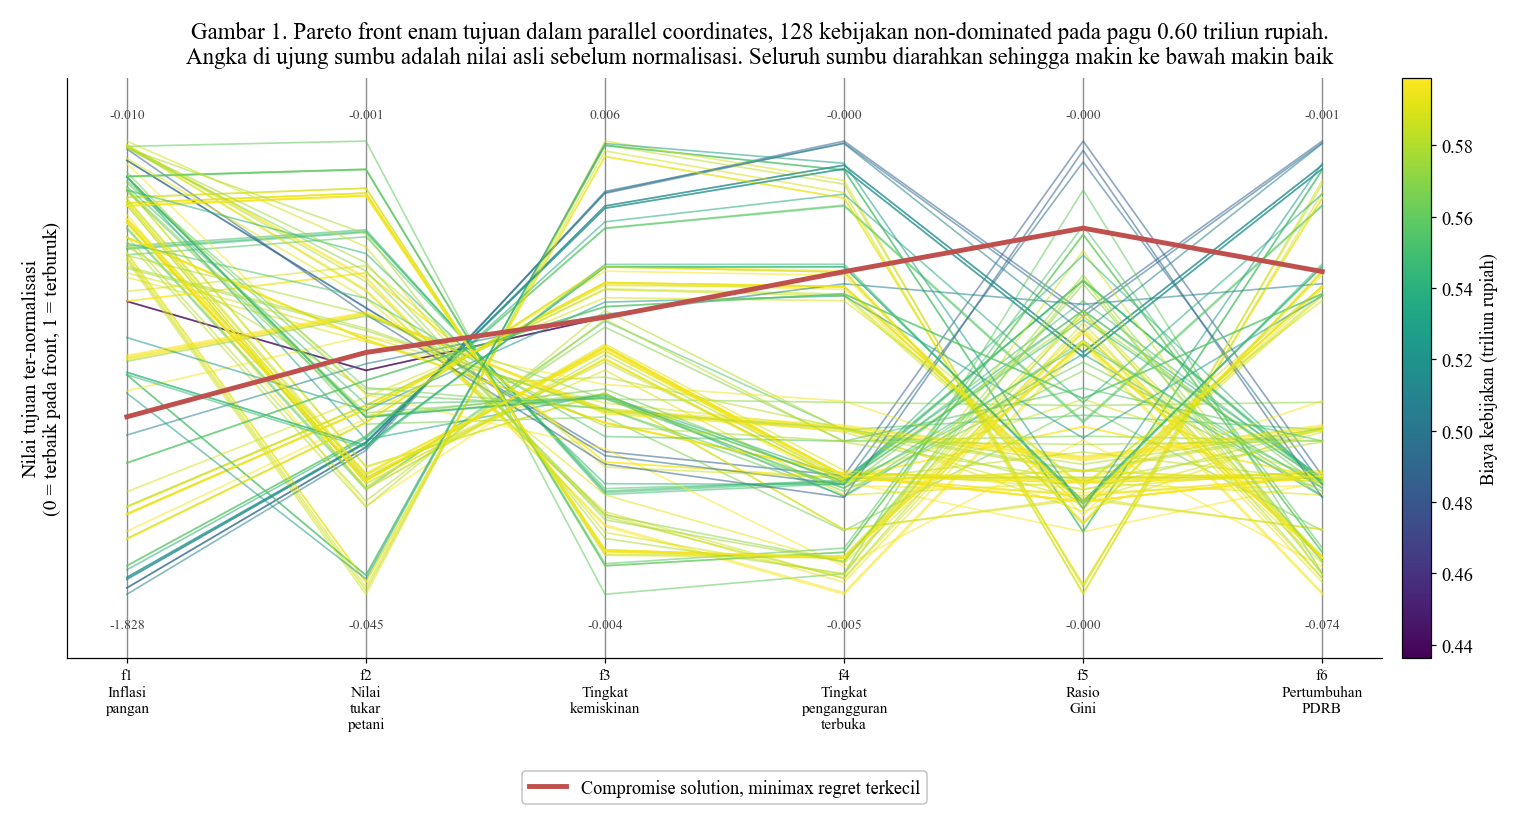

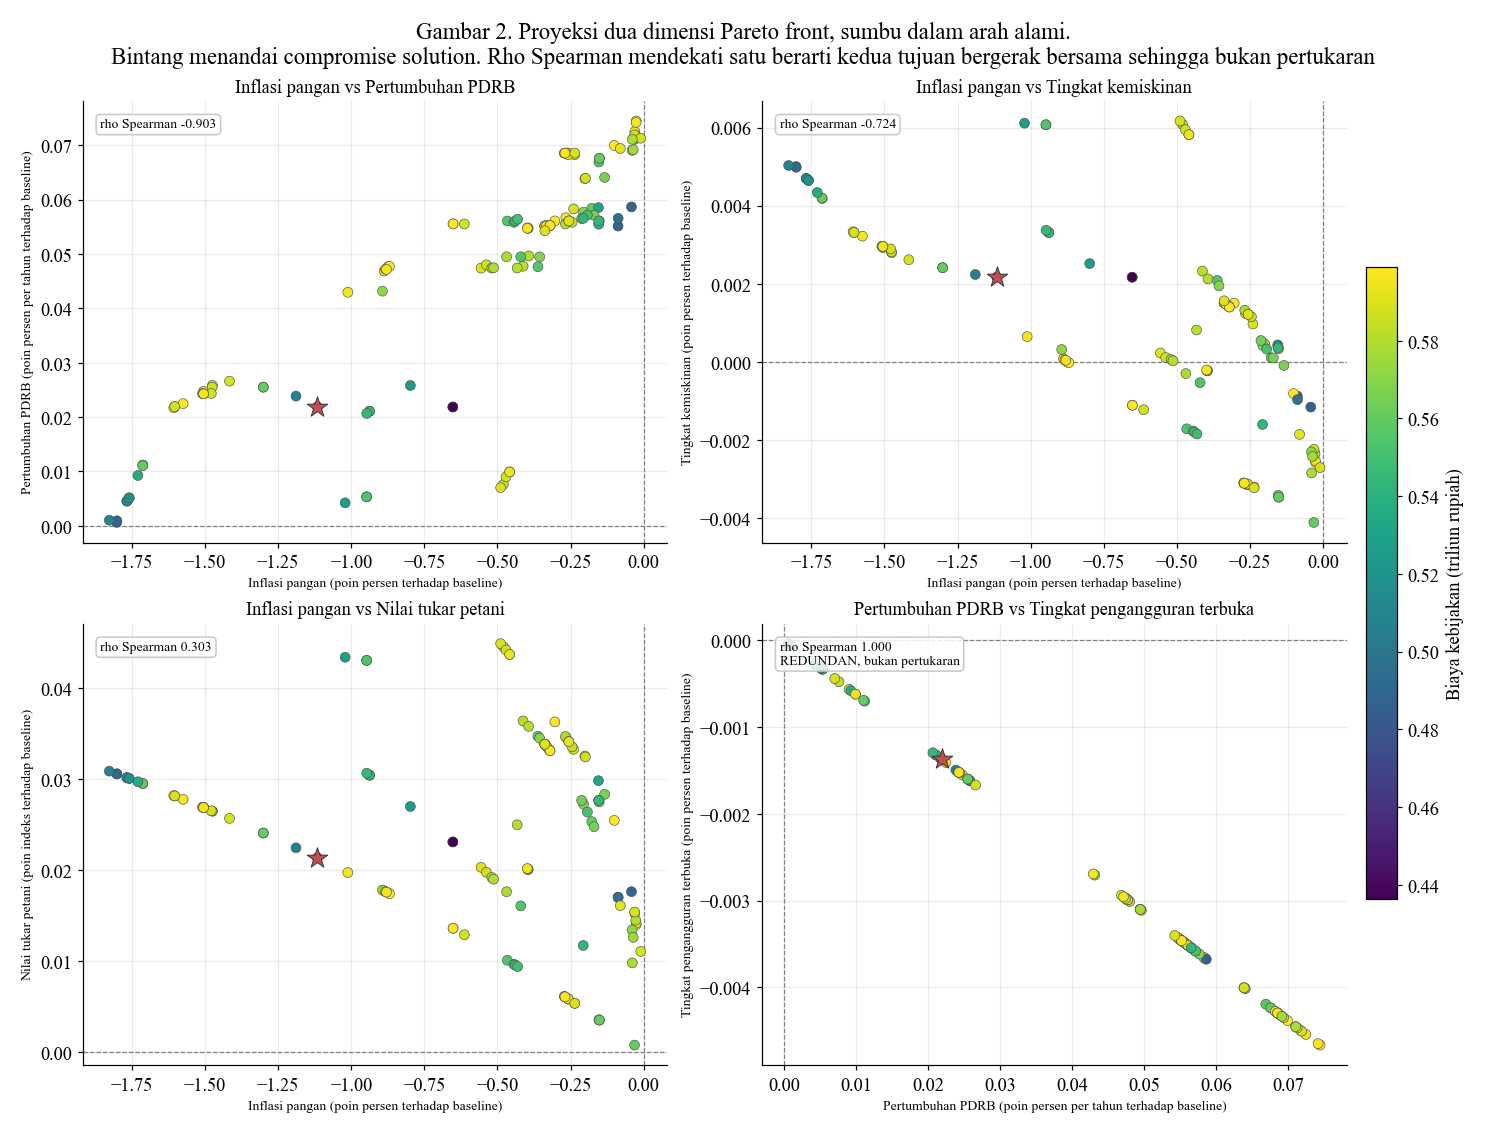

In [18]:
# Sel 8.1 - Gambar 1: Pareto front dalam parallel coordinates


butuh("PARETO_UTAMA", "KOMPROMI", "LABEL_TUJUAN")
def bakukan(A):
    lo, hi = A.min(axis=0), A.max(axis=0)
    return (A - lo) / np.maximum(hi - lo, 1e-12), lo, hi


FCOL = ["f" + str(j + 1) for j in range(NM)]
FA = PARETO_UTAMA[FCOL].to_numpy(float)
FN, FLO, FHI = bakukan(FA)
biaya = PARETO_UTAMA["biaya_total_triliun"].to_numpy(float)

fig, ax = plt.subplots(figsize=(13.5, 7.2))
norma = plt.Normalize(biaya.min(), biaya.max())
peta = plt.get_cmap("viridis")
for i in range(len(FN)):
    ax.plot(range(NM), FN[i], color=peta(norma(biaya[i])), alpha=0.55, linewidth=1.1,
            zorder=2)
# Compromise solution ditebalkan
i_k = int(np.argmin(np.abs(PARETO_UTAMA.index.to_numpy() - int(KOMPROMI.indeks_pareto))))
ax.plot(range(NM), FN[i_k], color="#c0504d", linewidth=3.2, zorder=5,
        label="Compromise solution, minimax regret terkecil")
for j in range(NM):
    ax.axvline(j, color="0.55", linewidth=0.9, zorder=1)
    ax.text(j, 1.045, format(FHI[j], ".3f"), ha="center", va="bottom",
            fontsize=UKURAN - 4, color="0.25")
    ax.text(j, -0.055, format(FLO[j], ".3f"), ha="center", va="top",
            fontsize=UKURAN - 4, color="0.25")
ax.set_xticks(range(NM))
ax.set_xticklabels([d["kode"] + "\n" + d["nama"].replace(" ", "\n") for d in TUJUAN],
                   fontsize=UKURAN - 3)
ax.set_ylim(-0.14, 1.14); ax.set_yticks([])
ax.set_ylabel("Nilai tujuan ter-normalisasi\n(0 = terbaik pada front, 1 = terburuk)")
ax.grid(False)
sm = plt.cm.ScalarMappable(cmap=peta, norm=norma); sm.set_array([])
cb = fig.colorbar(sm, ax=ax, pad=0.015, fraction=0.03)
cb.set_label("Biaya kebijakan (triliun rupiah)", fontsize=UKURAN - 1)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)
fig.suptitle("Gambar 1. Pareto front enam tujuan dalam parallel coordinates, " +
             str(len(FN)) + " kebijakan non-dominated pada pagu " +
             format(PAGU_UTAMA / 1e12, ".2f") + " triliun rupiah.\n"
             "Angka di ujung sumbu adalah nilai asli sebelum normalisasi. "
             "Seluruh sumbu diarahkan sehingga makin ke bawah makin baik")
simpan_gambar(fig, "gambar_01_pareto_koordinat_sejajar",
              "Pareto front enam tujuan dalam parallel coordinates, diwarnai menurut biaya")
plt.show()

# Sel 8.2 - Gambar 2: proyeksi dua dimensi pertukaran pokok
PASANGAN = [(0, 5, "Stabilitas harga  vs  pertumbuhan"),
            (0, 2, "Stabilitas harga  vs  kemiskinan"),
            (0, 1, "Stabilitas harga  vs  nilai tukar petani"),
            (5, 3, "Pertumbuhan  vs  pengangguran")]
fig, sb = plt.subplots(2, 2, figsize=(13.2, 10.0))
for k, (a, b, _) in enumerate(PASANGAN):
    ax = sb.flat[k]
    jud = TUJUAN[a]["nama"] + " vs " + TUJUAN[b]["nama"]
    # Tanda dikembalikan ke arah alami supaya sumbu terbaca apa adanya
    xa = FA[:, a] * TANDA_TAMPIL[a]; yb = FA[:, b] * TANDA_TAMPIL[b]
    sc = ax.scatter(xa, yb, c=biaya, cmap="viridis", s=42,
                    edgecolors="0.3", linewidths=0.4, zorder=3)
    ax.scatter([xa[i_k]], [yb[i_k]], s=200, marker="*", color="#c0504d",
               edgecolors="0.2", linewidths=0.6, zorder=5)
    ax.axhline(0, color="0.5", linewidth=0.8, linestyle="--", zorder=1)
    ax.axvline(0, color="0.5", linewidth=0.8, linestyle="--", zorder=1)
    ax.set_xlabel(TUJUAN[a]["nama"] + " (" + TUJUAN[a]["satuan"] + ")",
                  fontsize=UKURAN - 4)
    ax.set_ylabel(TUJUAN[b]["nama"] + " (" + TUJUAN[b]["satuan"] + ")",
                  fontsize=UKURAN - 4)
    ax.set_title(jud, fontsize=UKURAN - 1)
    korel = korelasi_peringkat(FA[:, a], FA[:, b]) if len(FA) > 2 else np.nan
    tks = "rho Spearman " + format(korel, ".3f")
    if np.isfinite(korel) and abs(korel) >= 0.99:
        tks += "\nREDUNDAN, bukan pertukaran"
    ax.text(0.03, 0.96, tks, transform=ax.transAxes,
            va="top", fontsize=UKURAN - 4,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.85,
                      edgecolor="0.75"))
cb = fig.colorbar(sc, ax=sb, pad=0.015, fraction=0.025)
cb.set_label("Biaya kebijakan (triliun rupiah)", fontsize=UKURAN - 1)
fig.suptitle("Gambar 2. Proyeksi dua dimensi Pareto front, sumbu dalam arah alami.\n"
             "Bintang menandai compromise solution. Rho Spearman mendekati satu berarti "
             "kedua tujuan bergerak bersama sehingga bukan pertukaran")
simpan_gambar(fig, "gambar_02_proyeksi_pertukaran",
              "Empat proyeksi dua dimensi Pareto front dengan koefisien korelasinya")
plt.show()

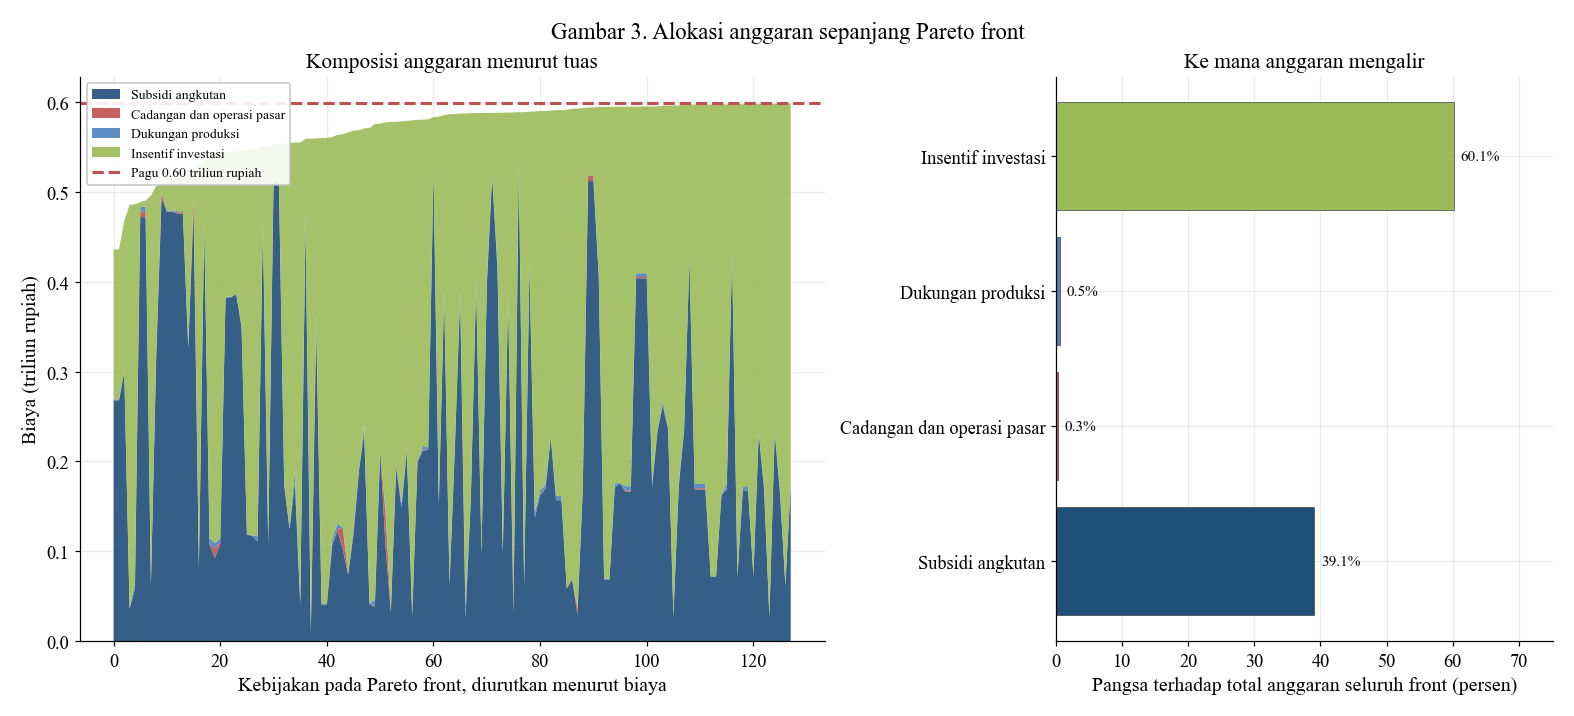

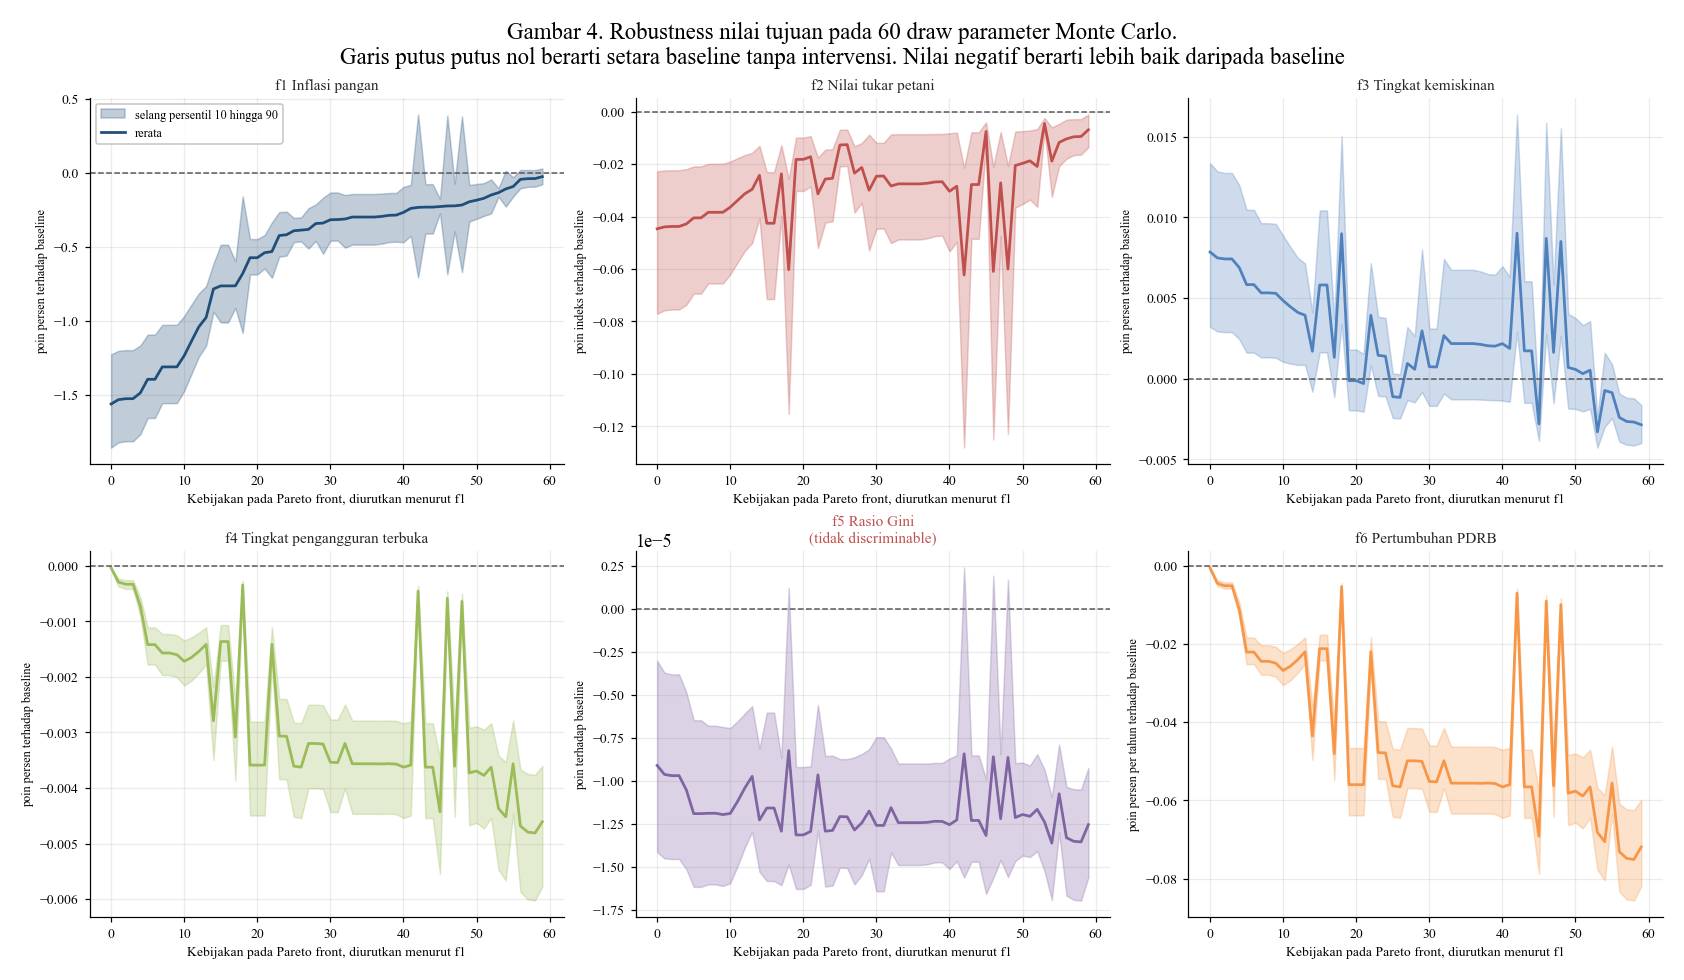

In [19]:
# Sel 8.3 - Gambar 3: komposisi anggaran sepanjang Pareto front


butuh("PARETO_UTAMA", "TEGAR", "DIAG", "PAGU_UTAMA")
urut = np.argsort(biaya)
KOMP_BIAYA = ["biaya_angkut_triliun", "biaya_operasi_triliun",
              "biaya_produksi_triliun", "biaya_insentif_triliun"]
LBL_BIAYA = ["Subsidi angkutan", "Cadangan dan operasi pasar",
             "Dukungan produksi", "Insentif investasi"]
M = PARETO_UTAMA[KOMP_BIAYA].to_numpy(float)[urut]

fig, sb = plt.subplots(1, 2, figsize=(14.0, 6.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax = sb[0]
ax.stackplot(np.arange(len(M)), M.T, labels=LBL_BIAYA, colors=PALET[:4], alpha=0.9)
ax.axhline(PAGU_UTAMA / 1e12, color="#c0504d", linewidth=2.0, linestyle="--",
           label="Pagu " + format(PAGU_UTAMA / 1e12, ".2f") + " triliun rupiah")
ax.set_xlabel("Kebijakan pada Pareto front, diurutkan menurut biaya")
ax.set_ylabel("Biaya (triliun rupiah)")
ax.set_title("Komposisi anggaran menurut tuas")
ax.legend(loc="upper left", fontsize=UKURAN - 4)

ax = sb[1]
pangsa = M.sum(axis=0) / max(M.sum(), 1e-12)
bar = ax.barh(LBL_BIAYA, 100 * pangsa, color=PALET[:4], edgecolor="0.3", linewidth=0.5)
for r, v in zip(bar, 100 * pangsa):
    ax.text(v + 1.0, r.get_y() + r.get_height() / 2, format(v, ".1f") + "%",
            va="center", fontsize=UKURAN - 3)
ax.set_xlabel("Pangsa terhadap total anggaran seluruh front (persen)")
ax.set_xlim(0, max(100 * pangsa.max() * 1.25, 10))
ax.set_title("Ke mana anggaran mengalir")
fig.suptitle("Gambar 3. Alokasi anggaran sepanjang Pareto front")
simpan_gambar(fig, "gambar_03_alokasi_anggaran",
              "Komposisi anggaran per tuas sepanjang Pareto front dan pangsa totalnya")
plt.show()

# Sel 8.4 - Gambar 4: robustness, selang persentil sepuluh sampai sembilan puluh
fig, sb = plt.subplots(2, 3, figsize=(15.0, 8.6))
urut_t = np.argsort(TEGAR["f1_rerata"].to_numpy())
for j in range(NM):
    ax = sb.flat[j]; c = "f" + str(j + 1)
    x = np.arange(len(TEGAR))
    lo = TEGAR[c + "_p10"].to_numpy()[urut_t]
    hi = TEGAR[c + "_p90"].to_numpy()[urut_t]
    md = TEGAR[c + "_rerata"].to_numpy()[urut_t]
    ax.fill_between(x, lo, hi, color=PALET[j % len(PALET)], alpha=0.28,
                    label="selang persentil 10 hingga 90")
    ax.plot(x, md, color=PALET[j % len(PALET)], linewidth=1.8, label="rerata")
    ax.axhline(0, color="0.35", linewidth=1.0, linestyle="--")
    beda = bool(DIAG.loc[j, "discriminable"])
    ax.set_title(LABEL_RINGKAS[j] + ("" if beda else "\n(tidak discriminable)"),
                 fontsize=UKURAN - 3, color="0.15" if beda else "#c0504d")
    ax.set_xlabel("Kebijakan pada Pareto front, diurutkan menurut f1",
                  fontsize=UKURAN - 4)
    ax.set_ylabel(TUJUAN[j]["satuan"], fontsize=UKURAN - 5)
    ax.tick_params(labelsize=UKURAN - 4)
    if j == 0:
        ax.legend(fontsize=UKURAN - 5, loc="best")
fig.suptitle("Gambar 4. Robustness nilai tujuan pada " + str(N_DRAW) +
             " draw parameter Monte Carlo.\nGaris putus putus nol berarti setara "
             "baseline tanpa intervensi. Nilai negatif berarti lebih baik daripada "
             "baseline")
simpan_gambar(fig, "gambar_04_robustness",
              "Selang ketidakpastian tiap tujuan sepanjang Pareto front")
plt.show()

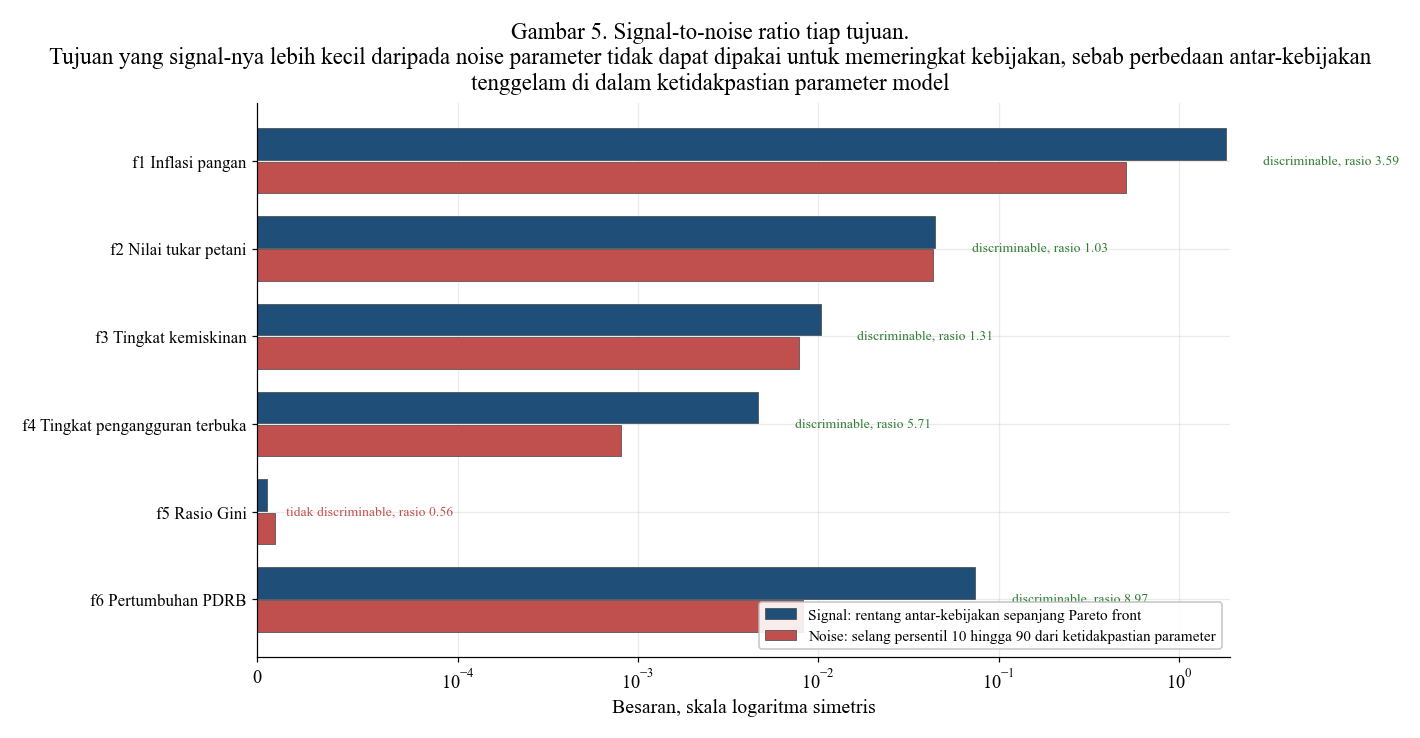

Poligon batas wilayah: tersedia untuk 33 wilayah


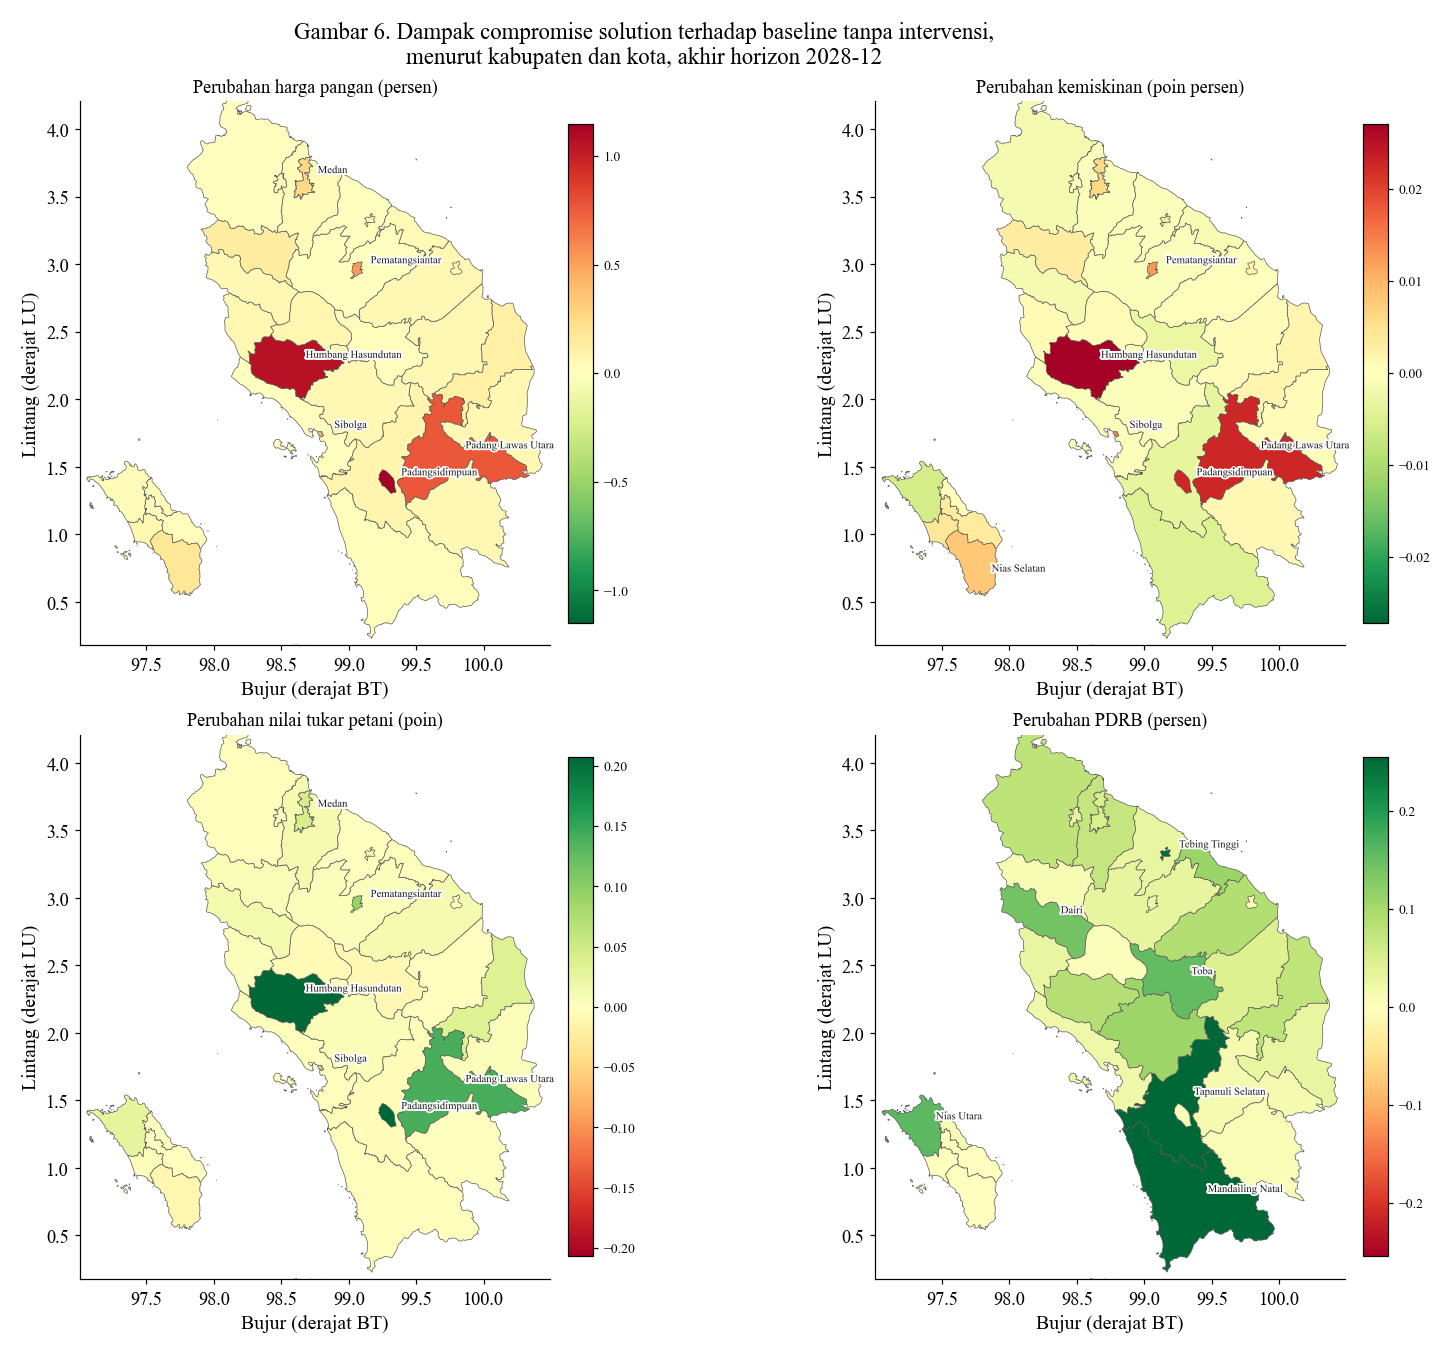

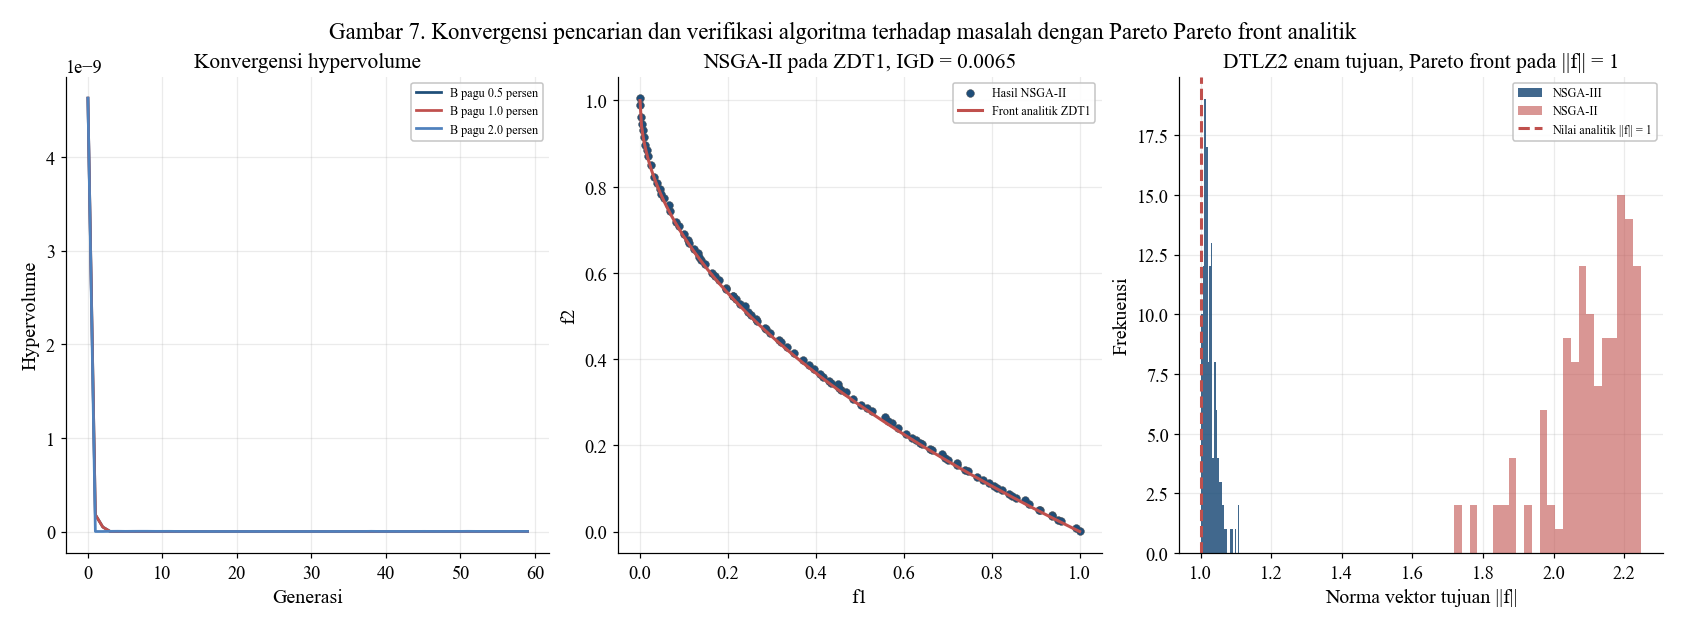

In [20]:
# Sel 8.5 - Gambar 5: diagnostik discriminability


butuh("DIAG", "X_KOMPROMI", "RIWAYAT", "_F", "_F3", "_F2b")
fig, ax = plt.subplots(figsize=(12.6, 6.4))
y = np.arange(NM)
ax.barh(y - 0.19, DIAG.rentang_antar_kebijakan, height=0.36, color=PALET[0],
        edgecolor="0.3", linewidth=0.5,
        label="Signal: rentang antar-kebijakan sepanjang Pareto front")
ax.barh(y + 0.19, DIAG.lebar_noise_p10_p90, height=0.36, color=PALET[1],
        edgecolor="0.3", linewidth=0.5,
        label="Noise: selang persentil 10 hingga 90 dari ketidakpastian parameter")
ax.set_yticks(y)
ax.set_yticklabels(LABEL_RINGKAS, fontsize=UKURAN - 2)
ax.set_xscale("symlog", linthresh=1e-4)
ax.set_xlabel("Besaran, skala logaritma simetris")
for i, r in enumerate(DIAG.itertuples()):
    tks = ("discriminable, rasio " + format(r.rasio_signal_noise, ".2f")) \
        if r.discriminable else ("tidak discriminable, rasio " +
                                 format(r.rasio_signal_noise, ".2f"))
    ax.text(max(r.rentang_antar_kebijakan, r.lebar_noise_p10_p90) * 1.6, i, tks,
            va="center", fontsize=UKURAN - 4,
            color="#2e7d32" if r.discriminable else "#c0504d")
ax.legend(loc="lower right", fontsize=UKURAN - 3)
ax.invert_yaxis()
fig.suptitle("Gambar 5. Signal-to-noise ratio tiap tujuan.\n"
             "Tujuan yang signal-nya lebih kecil daripada noise parameter tidak dapat "
             "dipakai untuk memeringkat kebijakan, sebab perbedaan antar-kebijakan\n"
             "tenggelam di dalam ketidakpastian parameter model")
simpan_gambar(fig, "gambar_05_discriminability_tujuan",
              "Perbandingan rentang antar-kebijakan terhadap lebar noise parameter")
plt.show()


# Sel 8.6 - Gambar 6: peta dampak compromise solution
def muat_poligon():
    calon = []
    for b in [DIR_NB01.parent, DIR_NB01.parent.parent, Path.cwd()]:
        for pola in ["*batas*kab*.geojson", "*kabupaten*.geojson", "*sumut*.geojson",
                     "*adm2*.geojson", "*sumatera*utara*.geojson"]:
            calon += [x for x in b.rglob(pola) if x.is_file()]
    if not calon:
        return None
    jalur = sorted(set(calon), key=lambda x: -x.stat().st_size)[0]
    with open(jalur, encoding="utf-8") as f:
        g = json.load(f)

    def baku(t):
        s = re.sub(r"^(kabupaten|kab\.|kab|kota)\s+", "", str(t).lower().strip())
        s = re.sub(r"[^a-z0-9]+", "", s)
        return {"padangsidempuan": "padangsidimpuan", "tobasamosir": "toba"}.get(s, s)

    # Pemadanan LEWAT NAMA, bukan kode. GeoJSON memakai kode Kemendagri 12.NN sedangkan
    # data memakai kode BPS 12NN, dan keduanya berbeda pada 20 dari 33 wilayah.
    peta = {baku(r.nama_baku): str(r.kode_wilayah) for r in REGISTRI.itertuples()}
    out = {}
    for ft in g.get("features", []):
        pr = ft.get("properties", {})
        nm = pr.get("kab_kota") or pr.get("NAMA") or pr.get("name") or ""
        kd = peta.get(baku(nm))
        if kd is None:
            continue
        geom = ft.get("geometry") or {}
        polys = geom.get("coordinates", []) if geom.get("type") == "MultiPolygon" \
            else [geom.get("coordinates", [])]
        ring = []
        for p in polys:
            if not p:
                continue
            r = np.asarray(p[0], float)[:, :2]
            if len(r) > 12:
                keep = [0]
                for q in range(1, len(r)):
                    if abs(r[q, 0] - r[keep[-1], 0]) > 0.004 or \
                       abs(r[q, 1] - r[keep[-1], 1]) > 0.004:
                        keep.append(q)
                if len(keep) >= 4:
                    r = r[keep]
            if len(r) >= 4:
                ring.append(r)
        if ring:
            out[kd] = ring
    return out


POLIGON = muat_poligon()
print("Poligon batas wilayah:",
      ("tersedia untuk " + str(len(POLIGON)) + " wilayah") if POLIGON
      else "tidak ditemukan, peta memakai titik sentroid")


def peta_tematik(ax, nilai_kode, cmap="RdYlGn_r", simetris=False):
    from matplotlib.patches import Polygon as PoliMPL
    from matplotlib.collections import PatchCollection
    from matplotlib import colors as mcolors
    v = np.array([nilai_kode.get(k, np.nan) for k in KODE], float)
    vmin, vmax = np.nanmin(v), np.nanmax(v)
    if simetris:
        m = max(abs(vmin), abs(vmax)); vmin, vmax = -m, m
    norma = mcolors.Normalize(vmin=vmin, vmax=vmax); pw = plt.get_cmap(cmap)
    if POLIGON:
        tampal, warna = [], []
        for idx, k in enumerate(KODE):
            for r in POLIGON.get(k, []):
                tampal.append(PoliMPL(r, closed=True))
                warna.append(pw(norma(v[idx])) if np.isfinite(v[idx]) else "0.90")
        ax.add_collection(PatchCollection(tampal, facecolors=warna, edgecolors="0.35",
                                          linewidths=0.45, zorder=2))
        ax.set_xlim(BUJUR.min() - 0.35, BUJUR.max() + 0.35)
        ax.set_ylim(LINTANG.min() - 0.5, LINTANG.max() + 0.5)
    else:
        ax.scatter(BUJUR, LINTANG, c=v, cmap=pw, norm=norma, s=180,
                   edgecolors="0.3", linewidths=0.6, zorder=3)
        ax.margins(0.16)
    ax.set_aspect(1.0 / np.cos(np.radians(float(np.nanmean(LINTANG)))))
    ax.grid(False); ax.set_xlabel("Bujur (derajat BT)"); ax.set_ylabel("Lintang (derajat LU)")
    return plt.cm.ScalarMappable(cmap=pw, norm=norma)


R_KOMP = jalankan_kebijakan(X_KOMPROMI)
R_DASAR = jalankan_kebijakan(X_DASAR)
W_KOMP = blok_kesejahteraan(R_KOMP); W_DASAR = blok_kesejahteraan(R_DASAR)

d_harga = 100 * (R_KOMP["ihp"][-1] / R_DASAR["ihp"][-1] - 1)
d_miskin = R_KOMP["p0"][-1] - R_DASAR["p0"][-1]
d_ntp = W_KOMP["NTP"][-1] - W_DASAR["NTP"][-1]
d_pdrb = 100 * (R_KOMP["y"][-1] / R_DASAR["y"][-1] - 1)

DAMPAK_WIL = pd.DataFrame({
    "kode_wilayah": KODE, "wilayah": [NAMA[k] for k in KODE],
    "delta_harga_pangan_persen": d_harga, "delta_kemiskinan_poin": d_miskin,
    "delta_ntp_poin": d_ntp, "delta_pdrb_persen": d_pdrb,
    "penduduk": POP0,
    "jiwa_terhindar_miskin": -(d_miskin / 100.0) * R_KOMP["pop"][-1]})
simpan(DAMPAK_WIL, "tabel/dampak_kompromi_per_wilayah.csv")

fig, sb = plt.subplots(2, 2, figsize=(14.4, 12.0))
for ax, v, jud, cm in [
        (sb[0, 0], d_harga, "Perubahan harga pangan (persen)", "RdYlGn_r"),
        (sb[0, 1], d_miskin, "Perubahan kemiskinan (poin persen)", "RdYlGn_r"),
        (sb[1, 0], d_ntp, "Perubahan nilai tukar petani (poin)", "RdYlGn"),
        (sb[1, 1], d_pdrb, "Perubahan PDRB (persen)", "RdYlGn")]:
    sm = peta_tematik(ax, dict(zip(KODE, v)), cmap=cm, simetris=True)
    ax.set_title(jud, fontsize=UKURAN - 1)
    cb = fig.colorbar(sm, ax=ax, fraction=0.036, pad=0.02)
    cb.ax.tick_params(labelsize=UKURAN - 4)
    ekstrem = np.argsort(-np.abs(v))[:6]
    label_tanpa_tumpang(ax, BUJUR[ekstrem], LINTANG[ekstrem],
                        [NAMA[KODE[i]] for i in ekstrem], fontsize=UKURAN - 6)
fig.suptitle("Gambar 6. Dampak compromise solution terhadap baseline tanpa intervensi,\n"
             "menurut kabupaten dan kota, akhir horizon " + str(BULAN_DEPAN[-1]))
simpan_gambar(fig, "gambar_06_peta_dampak_kompromi",
              "Peta dampak compromise solution pada empat besaran menurut kabupaten dan kota")
plt.show()


# Sel 8.7 - Gambar 7: konvergensi dan verifikasi algoritma
fig, sb = plt.subplots(1, 3, figsize=(15.0, 5.4))
ax = sb[0]
for nm, rw in RIWAYAT.items():
    ax.plot(rw.generasi, rw.hypervolume, linewidth=1.8, label=nm)
ax.set_xlabel("Generasi"); ax.set_ylabel("Hypervolume")
ax.set_title("Konvergensi hypervolume"); ax.legend(fontsize=UKURAN - 5)

ax = sb[1]
ax.scatter(_F[:, 0], _F[:, 1], s=26, color=PALET[0], edgecolors="0.3", linewidths=0.3,
           label="Hasil NSGA-II", zorder=3)
_x = np.linspace(0, 1, 300)
ax.plot(_x, 1 - np.sqrt(_x), color="#c0504d", linewidth=2.0,
        label="Front analitik ZDT1", zorder=4)
ax.set_xlabel("f1"); ax.set_ylabel("f2")
ax.set_title("NSGA-II pada ZDT1, IGD = " + format(IGD_ZDT1, ".4f"))
ax.legend(fontsize=UKURAN - 5)

ax = sb[2]
nrm3 = np.linalg.norm(_F3, axis=1); nrm2 = np.linalg.norm(_F2b, axis=1)
ax.hist(nrm3, bins=24, color=PALET[0], alpha=0.85, label="NSGA-III")
ax.hist(nrm2, bins=24, color=PALET[1], alpha=0.6, label="NSGA-II")
ax.axvline(1.0, color="#c0504d", linewidth=2.0, linestyle="--",
           label="Nilai analitik ||f|| = 1")
ax.set_xlabel("Norma vektor tujuan ||f||"); ax.set_ylabel("Frekuensi")
ax.set_title("DTLZ2 enam tujuan, Pareto front pada ||f|| = 1")
ax.legend(fontsize=UKURAN - 5)
fig.suptitle("Gambar 7. Konvergensi pencarian dan verifikasi algoritma "
             "terhadap masalah dengan Pareto Pareto front analitik")
simpan_gambar(fig, "gambar_07_konvergensi_dan_verifikasi",
              "Konvergensi hypervolume serta verifikasi NSGA-II dan NSGA-III")
plt.show()

---
## Bagian 9. Dashboard HTML mandiri

Satu berkas HTML tunggal yang berjalan tanpa server dan tanpa internet, cukup dibuka dengan
peramban mana pun. Ditujukan bagi pemerintah daerah agar dapat mencoba sendiri kombinasi
kebijakan tanpa perlu menjalankan Python.

### Mengapa mesinnya dipindahkan, bukan digantikan emulator

Satu simulasi penuh memakan 43 milidetik di Python. Pada JavaScript dengan flat array,
beban yang sama justru lebih ringan sebab tidak ada beban per operasi seperti pada numpy
untuk larik kecil. Karena itu mesin yang sama dapat dijalankan penuh setiap kali slider
digeser, dan tidak diperlukan polynomial response surface yang selalu membawa galat
aproksimasi dan tidak dapat mengekstrapolasi.

### Verifikasi tertanam

Pemindahan kode antar bahasa mudah menyimpang tanpa disadari. Karena itu notebook menghitung
hasil Python untuk sejumlah vektor kebijakan uji, lalu menanamkan hasilnya ke dalam berkas
HTML. Ketika halaman dimuat, mesin JavaScript menjalankan vektor yang sama dan menampilkan
deviasi terbesarnya pada panel di kanan atas. Bila pemindahannya cacat, dashboard mengatakannya
sendiri di layar, bukan diam diam menampilkan angka yang salah.

### Isi dashboard

Tujuh slider tuas kebijakan, budget gauge terhadap pagu, peta *choropleth* 33 kabupaten
dan kota dengan lima indikator yang dapat dipilih, empat grafik lintasan bulanan, panel enam
tujuan terhadap baseline, serta tabel wilayah yang dapat diurutkan. Seluruh data
ditanam sebagai JSON di dalam berkas, termasuk poligon batas wilayah yang sudah disederhanakan.

Poligon dipadankan **lewat nama, bukan kode**, sesuai temuan Notebook 02 bahwa GeoJSON memakai
kode Kemendagri berformat 12.NN sedangkan data memakai kode BPS berformat 12NN, dan keduanya
berbeda pada 20 dari 33 wilayah.

In [21]:
# Sel 9.1 - Menyiapkan data tertanam dan contoh verifikasi untuk dashboard


butuh("POLIGON", "X_KOMPROMI", "PARETO_UTAMA", "DIAG", "N_VERIF")

def sederhanakan_ring(r, tol=0.006):
    """Kurangi jumlah vertex ring poligon agar berkas HTML tetap ringan."""
    if len(r) <= 6:
        return r
    keep = [0]
    for q in range(1, len(r)):
        if abs(r[q, 0] - r[keep[-1], 0]) > tol or abs(r[q, 1] - r[keep[-1], 1]) > tol:
            keep.append(q)
    if keep[-1] != len(r) - 1:
        keep.append(len(r) - 1)
    return r[keep] if len(keep) >= 4 else r


GEO_DASH = {}
n_vertex_asli = n_vertex_baru = 0
if POLIGON:
    for k, ring in POLIGON.items():
        rr = []
        for r in ring:
            n_vertex_asli += len(r)
            s = sederhanakan_ring(r)
            n_vertex_baru += len(s)
            if len(s) >= 4:
                rr.append([[round(float(a), 4), round(float(b), 4)] for a, b in s])
        if rr:
            GEO_DASH[k] = rr
print("Poligon untuk dashboard:", len(GEO_DASH), "wilayah |", format(n_vertex_asli, ","),
      "vertex disederhanakan menjadi", format(n_vertex_baru, ","))

# Contoh verifikasi. Vektor kebijakan acak beserta hasil Python-nya ditanam ke HTML,
# lalu mesin JavaScript menjalankan vektor yang sama saat halaman dimuat.
# N_VERIF berasal dari panel kendali di Sel 1.1.
rv = np.random.default_rng(31415)
X_VERIF = rv.random((N_VERIF, NX)) * (X_HI - X_LO) + X_LO
X_VERIF[0] = X_DASAR
X_VERIF[1] = X_KOMPROMI
CONTOH_VERIF = []
for x in X_VERIF:
    R = jalankan_kebijakan(x)
    r = ringkas_hasil(R)
    CONTOH_VERIF.append({
        "x": [round(float(v), 6) for v in x],
        "ihp": round(float(np.average(R["ihp"][-1], weights=R["pop"][-1])), 4),
        "p0": round(float(np.average(R["p0"][-1], weights=R["pop"][-1])), 6),
        "ntp": round(float(r["ntp_akhir"]), 6),
        "biaya": round(float(R["_biaya"]["total"] / 1e12), 6)})

DASH = {
    "meta": {"proyek": "Sumatranomics 2026", "wilayah": "Sumatera Utara",
             "dibuat": datetime.now().strftime("%Y-%m-%d %H:%M"),
             "horizon_bulan": int(H_DEPAN),
             "periode": [str(BULAN_DEPAN[0]), str(BULAN_DEPAN[-1])],
             "dt": float(DT_MODEL),
             "pagu_triliun": float(PAGU_UTAMA / 1e12),
             "sumber_pagu": "APBD kabupaten dan kota se Sumatera Utara 2026 ditambah "
                            "belanja daerah provinsi, satu persen"},
    "kode": KODE, "nama": [NAMA[k] for k in KODE], "komoditas": KOM,
    "lintang": [round(float(v), 5) for v in LINTANG],
    "bujur": [round(float(v), 5) for v in BUJUR],
    "geo": GEO_DASH,
    "par": {
        "theta": [[round(float(v), 6) for v in r] for r in THETA],
        "beta": [[round(float(v), 6) for v in r] for r in BETA],
        "psi": [round(float(v), 6) for v in PARB["psi"]],
        "eps": [round(float(v), 6) for v in PARB["eps"]],
        "susut": [round(float(v), 6) for v in PARB["susut"]],
        "tau_panen": [round(float(v), 4) for v in PARB["tau_panen"]],
        "impor_luar": [round(float(v), 4) for v in PARB["impor_luar"]],
        "tau_dagang": float(PARB["tau_dagang"]), "tau_A": float(PARB["tau_A"]),
        "tau_exp": float(PARB["tau_exp"]), "eta": float(PARB["eta"]),
        "cov_target": float(PARB["cov_target"]),
        "musim": [[round(float(v), 6) for v in r] for r in MUSIM],
        "omega": [round(float(v), 6) for v in OMEGA],
        "kons_pc": [float(v) for v in KONS_PC],
        "e_gk": float(E_GK_PAKAI), "e_p0": float(E_P0_PAKAI),
        "w_kons": float(W_KONSUMSI_RT), "w_bppbm": float(W_BPPBM),
        "alpha_k": ALPHA_K, "beta_l": BETA_L, "gamma_lk": GAMMA_LK,
        "gamma_ln": GAMMA_LN, "inv_y": INV_Y, "gini_y": GINI_Y, "gini_p": GINI_P,
        "tpt_y": TPT_Y, "delta_modal": DELTA_MODAL, "g_tfp": float(G_TFP_PAKAI),
        "growth_pop": [round(float(v), 8) for v in GROWTH_POP]},
    "awal": {
        "harga": [[round(float(v), 3) for v in r] for r in HARGA_AWAL],
        "produksi": [[[round(float(v), 3) for v in c] for c in r] for r in PRODUKSI],
        "luas": [[[round(float(v), 3) for v in c] for c in r] for r in LUAS],
        "pop": [float(v) for v in POP0], "gk": [float(v) for v in GK0],
        "p0": [float(v) for v in P00], "y": [float(v) for v in Y0],
        "k": [float(v) for v in K0_PAKAI], "inv": [float(v) for v in INV0_PAKAI],
        "l": [float(v) for v in L0], "tpt": [float(v) for v in TPT0],
        "gini": [float(v) for v in GINI0]},
    "ln_acuan": [[round(float(v), 6) for v in r] for r in LN_ACUAN_DEPAN],
    "biaya_satuan": {"angkut": BIAYA_ANGKUT_RP_TON, "operasi": BIAYA_OPERASI_RP_TON,
                     "produksi": BIAYA_PRODUKSI_RP_HA_TAHUN,
                     "insentif": BIAYA_INSENTIF_PER_RUPIAH},
    "ruang": RUANG_KEBIJAKAN,
    "kompromi": [round(float(v), 6) for v in X_KOMPROMI],
    "verifikasi": CONTOH_VERIF,
    "pareto": PARETO_UTAMA[["f1", "f2", "f3", "f4", "f5", "f6",
                            "biaya_total_triliun"] + KODE_X]
              .round(6).to_dict(orient="records"),
    "diagnostik": DIAG[["tujuan", "rasio_signal_noise", "discriminable"]]
                  .round(4).to_dict(orient="records"),
    "label_tujuan": [l.replace("\n", " ") for l in LABEL_TUJUAN],
}
JSON_DASH = json.dumps(DASH, separators=(",", ":"))
print("Ukuran JSON tertanam:", round(len(JSON_DASH) / 1024, 1), "KB")
print("Contoh verifikasi Python yang ditanam:", len(CONTOH_VERIF), "vektor kebijakan")

Poligon untuk dashboard: 33 wilayah | 27,558 vertex disederhanakan menjadi 19,127
Ukuran JSON tertanam: 379.1 KB
Contoh verifikasi Python yang ditanam: 12 vektor kebijakan


In [22]:
# Sel 9.2 - Membangun berkas HTML mandiri berisi mesin simulasi JavaScript


butuh("JSON_DASH", "GEO_DASH", "CONTOH_VERIF")
HTML_KEPALA = """<!DOCTYPE html>
<html lang="id"><head><meta charset="utf-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>Sumatranomics 2026 - Simulator Kebijakan Sumatera Utara</title>
<style>
*{box-sizing:border-box}
body{font-family:"Times New Roman",Times,serif;font-size:15px;margin:0;background:#f4f2ee;color:#1a1a1a}
header{background:#1f4e79;color:#fff;padding:14px 22px}
header h1{margin:0;font-size:21px;font-weight:normal}
header p{margin:4px 0 0;font-size:13px;opacity:.85}
.wrap{display:grid;grid-template-columns:340px 1fr;gap:14px;padding:14px;max-width:1680px;margin:0 auto}
.card{background:#fff;border:1px solid #d8d4cc;border-radius:5px;padding:14px;margin-bottom:14px}
.card h2{margin:0 0 10px;font-size:16px;font-weight:bold;border-bottom:1px solid #e2ded6;padding-bottom:6px}
.slider{margin-bottom:12px}
.slider label{display:block;font-size:13px;margin-bottom:3px}
.slider .val{float:right;font-weight:bold;color:#1f4e79}
.slider input{width:100%}
.slider .sat{font-size:11px;color:#777}
button{font-family:inherit;font-size:13px;padding:6px 12px;margin:2px;border:1px solid #1f4e79;
background:#fff;color:#1f4e79;border-radius:3px;cursor:pointer}
button:hover{background:#1f4e79;color:#fff}
.gauge{height:26px;background:#e8e5df;border-radius:3px;overflow:hidden;position:relative;margin:8px 0}
.gauge div{height:100%;background:#4f81bd;transition:width .18s}
.gauge span{position:absolute;left:9px;top:3px;font-size:13px;font-weight:bold}
.over div{background:#c0504d}
table{border-collapse:collapse;width:100%;font-size:12.5px}
th,td{border:1px solid #e2ded6;padding:3px 6px;text-align:right}
th{background:#f0ece5;cursor:pointer;text-align:center}
td:first-child,th:first-child{text-align:left}
.grid2{display:grid;grid-template-columns:1fr 1fr;gap:12px}
.obj{display:flex;justify-content:space-between;padding:4px 0;border-bottom:1px dotted #ddd;font-size:13.5px}
.good{color:#2e7d32;font-weight:bold}.bad{color:#c0504d;font-weight:bold}.na{color:#999}
#verif{font-size:12px;padding:7px 10px;border-radius:3px;margin-top:8px}
.ok{background:#e6f2e6;border:1px solid #2e7d32}
.fail{background:#fbe9e7;border:1px solid #c0504d}
.note{font-size:11.5px;color:#666;line-height:1.45;margin-top:8px}
svg{display:block;width:100%;height:auto}
.tt{position:absolute;background:rgba(255,255,255,.97);border:1px solid #999;padding:4px 8px;
font-size:12px;pointer-events:none;display:none;border-radius:3px}
select{font-family:inherit;font-size:13px;padding:3px}
</style></head><body>
<header><h1>Simulator Kebijakan Pangan dan Pertumbuhan Sumatera Utara</h1>
<p>Sumatranomics 2026. Model dinamika sistem tujuh blok, 33 kabupaten dan kota,
6 komoditas. Berjalan sepenuhnya di dalam peramban tanpa server dan tanpa internet.</p></header>
<div class="wrap"><div>
<div class="card"><h2>Tuas kebijakan</h2><div id="sliders"></div>
<button onclick="setPreset('dasar')">Tanpa intervensi</button>
<button onclick="setPreset('kompromi')">Compromise solution</button>
<button onclick="setPreset('acak')">Acak</button></div>
<div class="card"><h2>Anggaran</h2>
<div class="gauge" id="gwrap"><div id="gbar"></div><span id="gtxt"></span></div>
<div id="ganggaran" class="note"></div></div>
<div class="card"><h2>Enam tujuan terhadap baseline tanpa intervensi</h2>
<div id="obj"></div>
<div class="note">Tujuan yang ditandai abu abu tidak discriminable oleh model,
sebab rentang antar-kebijakan lebih sempit daripada noise parameternya. Angkanya
ditampilkan sebagai keterangan, bukan sebagai dasar peringkat.</div></div>
</div><div>
<div class="card"><h2>Verifikasi mesin</h2><div id="verif">Menjalankan...</div>
<div class="note">Notebook menghitung hasil Python untuk beberapa vektor kebijakan uji lalu
menanamkannya ke berkas ini. Saat halaman dimuat, mesin JavaScript menjalankan vektor yang
sama dan melaporkan deviasi terbesarnya. Bila pemindahan kode antar bahasa cacat, panel ini
akan mengatakannya.</div></div>
<div class="card"><h2>Peta dampak menurut kabupaten dan kota</h2>
<select id="indik" onchange="jalankan()">
<option value="dharga">Perubahan harga pangan (persen)</option>
<option value="dp0">Perubahan kemiskinan (poin persen)</option>
<option value="dntp">Perubahan nilai tukar petani (poin)</option>
<option value="harga">Tingkat indeks harga pangan akhir</option>
<option value="cov">Stock coverage rerata (bulan)</option>
</select>
<div style="position:relative"><div id="peta"></div><div class="tt" id="tt"></div></div></div>
<div class="card"><h2>Lintasan bulanan, agregat provinsi</h2>
<div class="grid2"><div id="c1"></div><div id="c2"></div>
<div id="c3"></div><div id="c4"></div></div></div>
<div class="card"><h2>Rincian menurut wilayah</h2>
<div style="max-height:340px;overflow:auto"><table id="tab"></table></div></div>
</div></div>
<script>
const D = """

HTML_MESIN = r""";
// ===================================================================
// Mesin simulasi tujuh blok, pemindahan langsung dari Python.
// Larik datar dipakai agar tetap ringan; indeks i wilayah, c komoditas.
// ===================================================================
const NW=D.kode.length, NK=D.komoditas.length, NT=D.meta.horizon_bulan, DT=D.meta.dt;
const P=D.par, A0=D.awal;
function flat(M){const o=new Float64Array(NW*NK);for(let i=0;i<NW;i++)for(let c=0;c<NK;c++)o[i*NK+c]=M[i][c];return o;}
const HARGA0=flat(A0.harga), THETA=flat(P.theta), BETA=flat(P.beta);
const LUAS0=new Float64Array(NW*NK), PROD0=new Float64Array(NW*NK);
for(let i=0;i<NW;i++)for(let c=0;c<NK;c++){LUAS0[i*NK+c]=A0.luas[i][c][0];PROD0[i*NK+c]=A0.produksi[i][c][0];}
const POP0=Float64Array.from(A0.pop);
const POPTOT=POP0.reduce((a,b)=>a+b,0);
function quantile(a,q){const s=Array.from(a).sort((x,y)=>x-y);const p=(s.length-1)*q;
  const lo=Math.floor(p),hi=Math.ceil(p);return s[lo]+(s[hi]-s[lo])*(p-lo);}

function halflife(){const h=new Float64Array(NW*NK);
  for(let k=0;k<NW*NK;k++)h[k]=Math.log(0.5)/Math.log(1+THETA[k]);return h;}
const HL=halflife();
const KECUK=new Float64Array(NW*NK);
for(let i=0;i<NW;i++)for(let c=0;c<NK;c++){
  const T=A0.produksi[i][c].length-1;
  KECUK[i*NK+c]=A0.produksi[i][c][T]/Math.max(POP0[i]*P.kons_pc[c],1e-9);}

function simulasi(x){
  const s_ang=x[0],f_ang=x[1],cap_op=x[2],amb_op=x[3],s_prod=x[4],f_prod=x[5],s_inv=x[6];
  // Tuas 1: percepat theta pada wilayah dengan half-life terpanjang
  const TH=Float64Array.from(THETA), SAS_ANG=new Uint8Array(NW*NK);
  if(s_ang>0&&f_ang>0){for(let c=0;c<NK;c++){const kol=[];for(let i=0;i<NW;i++)kol.push(HL[i*NK+c]);
    const amb=quantile(kol,1-f_ang);
    for(let i=0;i<NW;i++)if(HL[i*NK+c]>=amb){SAS_ANG[i*NK+c]=1;
      TH[i*NK+c]=Math.min(-0.02,Math.max(-0.95,THETA[i*NK+c]*(1+s_ang)));}}}
  // Tuas 3: dukungan produksi pada wilayah paling defisit
  const HHA=new Float64Array(NW*NK), SAS_PR=new Uint8Array(NW*NK);
  const MULT=new Float64Array(NW*NK).fill(1);
  if(s_prod>0&&f_prod>0){for(let c=0;c<NK;c++){const kol=[];for(let i=0;i<NW;i++)kol.push(KECUK[i*NK+c]);
    const amb=quantile(kol,f_prod);
    for(let i=0;i<NW;i++)if(KECUK[i*NK+c]<=amb){SAS_PR[i*NK+c]=1;MULT[i*NK+c]=1+s_prod;}}}
  for(let k=0;k<NW*NK;k++)HHA[k]=LUAS0[k]>0?PROD0[k]*MULT[k]/Math.max(LUAS0[k],1e-9):0;

  const lnP=new Float64Array(NW*NK), lnPr=new Float64Array(NW*NK), lnPe=new Float64Array(NW*NK);
  for(let k=0;k<NW*NK;k++){lnP[k]=Math.log(HARGA0[k]);lnPr[k]=lnP[k];lnPe[k]=lnP[k];}
  const pop=Float64Array.from(POP0);
  const konsB=new Float64Array(NW*NK), I=new Float64Array(NW*NK);
  for(let i=0;i<NW;i++)for(let c=0;c<NK;c++){konsB[i*NK+c]=pop[i]*P.kons_pc[c]/12;
    I[i*NK+c]=P.cov_target*konsB[i*NK+c];}
  const AA=Float64Array.from(LUAS0), AB=Float64Array.from(LUAS0);
  for(let k=0;k<NW*NK;k++){AA[k]=Math.max(AA[k],1e-9);AB[k]=AA[k];}
  const D1=new Float64Array(NW*NK),D2=new Float64Array(NW*NK),D3=new Float64Array(NW*NK);
  for(let k=0;k<NW*NK;k++){D1[k]=PROD0[k]*MULT[k]/12;D2[k]=D1[k];D3[k]=D1[k];}
  let Y=Float64Array.from(A0.y), K=Float64Array.from(A0.k), Lk=Float64Array.from(A0.l);
  let gk=Float64Array.from(A0.gk), p0=Float64Array.from(A0.p0);
  let gini=Float64Array.from(A0.gini), tpt=Float64Array.from(A0.tpt);
  const INV0=Float64Array.from(A0.inv).map(v=>v*(1+s_inv));
  let db=new Float64Array(NW).fill(1);
  const nsub=Math.round(1/DT);
  let lnIHP0=new Float64Array(NW), akum=new Float64Array(NW), nak=0;
  for(let i=0;i<NW;i++){let s=0;for(let c=0;c<NK;c++)s+=lnP[i*NK+c]*P.omega[c];lnIHP0[i]=s;}
  const jejak=[], covAkum=new Float64Array(NW*NK);
  let volAntar=0, volOp=0, luasT=0, invTot=0;
  const cov=new Float64Array(NW*NK), kons=new Float64Array(NW*NK);

  for(let t=0;t<NT;t++){
    const bl=t%12, lb=D.ln_acuan[Math.min(t,D.ln_acuan.length-1)];
    const lp=D.ln_acuan[Math.min(t+1,D.ln_acuan.length-1)], lm=D.ln_acuan[Math.max(t-1,0)];
    for(let sub=0;sub<nsub;sub++){
      const covBar=new Float64Array(NK);
      for(let i=0;i<NW;i++)for(let c=0;c<NK;c++){const k=i*NK+c;
        kons[k]=konsB[k]*Math.exp(-P.eps[c]*(lnP[k]-lnPr[k]))*Math.pow(db[i],0.5);
        cov[k]=I[k]/Math.max(kons[k],1e-9);}
      for(let c=0;c<NK;c++){let s=0;for(let i=0;i<NW;i++)s+=cov[i*NK+c]*pop[i];covBar[c]=s/POPTOT;}
      for(let i=0;i<NW;i++)for(let c=0;c<NK;c++){const k=i*NK+c;
        const cr=cov[k]/Math.max(covBar[c],1e-6);
        const dlb=(lp[c]-lm[c])/2;
        const sisa=BETA[k]*dlb-P.psi[c]*Math.log(Math.max(cr,1e-3));
        const th=TH[k];
        lnP[k]=lb[c]-sisa/th+(lnP[k]-lb[c]+sisa/th)*Math.exp(th*DT);}
      const butuh=new Float64Array(NW*NK), surp=new Float64Array(NW*NK);
      const perlu=new Float64Array(NK), ters=new Float64Array(NK);
      for(let i=0;i<NW;i++)for(let c=0;c<NK;c++){const k=i*NK+c;
        butuh[k]=Math.max(0,P.cov_target-cov[k])*kons[k]/P.tau_dagang;
        surp[k]=Math.max(0,cov[k]-P.cov_target)*kons[k]/P.tau_dagang;
        perlu[c]+=butuh[k];ters[c]+=surp[k];
        ters[c]+=P.impor_luar[c]*konsB[k]*Math.max(0,1-covBar[c]/P.cov_target);}
      for(let i=0;i<NW;i++)for(let c=0;c<NK;c++){const k=i*NK+c;
        const rasio=perlu[c]>1e-9?Math.min(1,ters[c]/Math.max(perlu[c],1e-9)):0;
        const mw=butuh[k]*rasio;
        let sSur=0;for(let j=0;j<NW;j++)sSur+=surp[j*NK+c];
        const bagi=sSur>1e-9?Math.min(1,(perlu[c]*rasio)/Math.max(sSur,1e-9)):0;
        const kw=surp[k]*bagi;
        const tamb=cap_op>0?Math.min(Math.max(0,amb_op-cov[k])*kons[k],cap_op*kons[k]):0;
        const lam=3/P.tau_panen[c];
        const mt=AA[k]*HHA[k]/12*P.musim[c][bl];
        const dD1=(mt-D1[k])*lam,dD2=(D1[k]-D2[k])*lam,dD3=(D2[k]-D3[k])*lam;
        const panen=D3[k]*lam, sus=P.susut[c]*I[k];
        const kd=kons[k]+kw+sus, tt=I[k]/DT+panen+mw+Math.max(tamb,0);
        const fak=kd>1e-12?Math.min(1,tt/Math.max(kd,1e-12)):1;
        const dI=panen+mw-kw*fak+tamb-kons[k]*fak-sus*fak;
        lnPe[k]+=DT*(lnP[k]-lnPe[k])/P.tau_exp;
        const sinyal=(lnPe[k]-lnPr[k])*1.5;
        const Atar=AB[k]*Math.exp(P.eta*sinyal);
        AA[k]=Math.max(AA[k]+DT*(Atar-AA[k])/P.tau_A,1e-9);
        I[k]=Math.max(I[k]+DT*dI,0);
        D1[k]=Math.max(D1[k]+DT*dD1,0);D2[k]=Math.max(D2[k]+DT*dD2,0);D3[k]=Math.max(D3[k]+DT*dD3,0);
        if(SAS_ANG[k])volAntar+=mw*DT;
        volOp+=Math.max(tamb,0)*DT;}
    }
    const ihp=new Float64Array(NW);
    for(let i=0;i<NW;i++){let s=0;for(let c=0;c<NK;c++)s+=lnP[i*NK+c]*P.omega[c];
      ihp[i]=s;akum[i]+=s;}
    nak++;
    for(let k=0;k<NW*NK;k++)covAkum[k]+=cov[k];
    for(let i=0;i<NW;i++)for(let c=0;c<NK;c++)
      if(SAS_PR[i*NK+c])luasT+=Math.max(AA[i*NK+c]-LUAS0[i*NK+c],0);
    if(bl===11){
      for(let i=0;i<NW;i++){const th=akum[i]/Math.max(nak,1), d=th-lnIHP0[i];lnIHP0[i]=th;
        gk[i]=gk[i]*Math.exp(P.e_gk*d);
        pop[i]=pop[i]*(1+P.growth_pop[i]);
        const inv=INV0[i]*Math.min(5,Math.max(0.2,Math.pow(Y[i]/Math.max(A0.y[i],1e-9),P.inv_y)));
        invTot+=inv;
        K[i]=(1-P.delta_modal)*K[i]+inv;
        const thn=(t+1)/12;
        Lk[i]=A0.l[i]*Math.exp(P.gamma_lk*Math.log(K[i]/Math.max(A0.k[i],1e-9))
              +P.gamma_ln*Math.log(pop[i]/Math.max(POP0[i],1e-9)));
        const Yb=A0.y[i]*Math.exp(P.alpha_k*Math.log(K[i]/Math.max(A0.k[i],1e-9))
              +P.beta_l*Math.log(Lk[i]/Math.max(A0.l[i],1e-9))+P.g_tfp*thn);
        const ypc=Yb*1000/Math.max(pop[i],1), ypc0=A0.y[i]*1000/Math.max(POP0[i],1);
        p0[i]=A0.p0[i]*Math.exp(P.e_p0*Math.log(gk[i]/Math.max(A0.gk[i],1e-9))
              -0.20*Math.log(ypc/Math.max(ypc0,1e-9)));
        gini[i]=Math.min(0.65,Math.max(0.15,A0.gini[i]*Math.exp(P.gini_y*Math.log(ypc/Math.max(ypc0,1e-9))+P.gini_p*d)));
        tpt[i]=Math.min(35,Math.max(0.3,A0.tpt[i]*Math.exp(P.tpt_y*Math.log(ypc/Math.max(ypc0,1e-9)))));
        db[i]=Math.exp(-0.35*d+0.25*Math.log(ypc/Math.max(ypc0,1e-9)));
        Y[i]=Yb;
        for(let c=0;c<NK;c++)konsB[i*NK+c]=pop[i]*P.kons_pc[c]/12;}
      akum=new Float64Array(NW);nak=0;}
    let sI=0,sP=0,sT=0,sG=0,sY=0,sPop=0;
    for(let i=0;i<NW;i++){sI+=Math.exp(ihp[i])*pop[i];sP+=p0[i]*pop[i];sT+=tpt[i]*pop[i];
      sG+=gini[i]*pop[i];sY+=Y[i];sPop+=pop[i];}
    let disp=0;
    for(let c=0;c<NK;c++){let m=0;for(let i=0;i<NW;i++)m+=lnP[i*NK+c];m/=NW;
      let v=0;for(let i=0;i<NW;i++)v+=(lnP[i*NK+c]-m)**2;disp+=Math.sqrt(v/NW);}
    jejak.push({ihp:sI/sPop,p0:sP/sPop,tpt:sT/sPop,gini:sG/sPop,y:sY,disp:disp/NK});
  }
  const ihpW=new Float64Array(NW), ntpW=new Float64Array(NW), covW=new Float64Array(NW);
  for(let i=0;i<NW;i++){let s=0,m=0;
    for(let c=0;c<NK;c++){s+=lnP[i*NK+c]*P.omega[c];m+=lnP[i*NK+c];}
    m/=NK;ihpW[i]=Math.exp(s);ntpW[i]=100*Math.exp(s-(s*P.w_kons+m*P.w_bppbm));
    let cc=0;for(let c=0;c<NK;c++)cc+=covAkum[i*NK+c]/NT;covW[i]=cc/NK;}
  const tahun=NT/12;
  const laju=100*(Math.pow(jejak[NT-1].y/Math.max(jejak[0].y,1e-9),1/tahun)-1);
  const biaya=(D.biaya_satuan.angkut*volAntar*s_ang
    +D.biaya_satuan.operasi*volOp
    +D.biaya_satuan.produksi*(luasT/NT)*tahun
    +D.biaya_satuan.insentif*invTot*1e6*(s_inv/Math.max(1+s_inv,1e-9)))/1e12;
  return {jejak:jejak,ihpW:ihpW,ntpW:ntpW,covW:covW,p0W:Float64Array.from(p0),
    biaya:biaya,laju:laju,
    ihp:jejak[NT-1].ihp,p0:jejak[NT-1].p0,tpt:jejak[NT-1].tpt,gini:jejak[NT-1].gini,
    ntp:(()=>{let s=0;for(let i=0;i<NW;i++)s+=ntpW[i]*POP0[i];return s/POPTOT;})(),
    naik:100*(jejak[NT-1].ihp/jejak[0].ihp-1)};
}
"""

HTML_UI = r"""
// ===================================================================
// Antarmuka
// ===================================================================
let X = D.kompromi.slice();
const DASAR = D.ruang.map(r=>r.kode==="amb_op"?1.0:0.0);
let REF = null;

function bangunSlider(){
  const w=document.getElementById("sliders");
  D.ruang.forEach((r,j)=>{
    const d=document.createElement("div");d.className="slider";
    d.innerHTML='<label>'+r.nama+'<span class="val" id="v'+j+'"></span></label>'+
      '<input type="range" id="s'+j+'" min="'+r.lo+'" max="'+r.hi+
      '" step="'+((r.hi-r.lo)/100)+'" value="'+X[j]+'">'+
      '<div class="sat">'+r.satuan+'</div>';
    w.appendChild(d);
    d.querySelector("input").addEventListener("input",e=>{
      X[j]=parseFloat(e.target.value);jalankan();});
  });
}
function setPreset(p){
  if(p==="dasar")X=DASAR.slice();
  else if(p==="kompromi")X=D.kompromi.slice();
  else X=D.ruang.map(r=>r.lo+Math.random()*(r.hi-r.lo));
  D.ruang.forEach((r,j)=>{document.getElementById("s"+j).value=X[j];});
  jalankan();
}
function fmt(v,n){return v.toLocaleString("id-ID",{minimumFractionDigits:n,maximumFractionDigits:n});}

function garis(id,judul,nilai,warna,satuan){
  const W=380,H=170,ml=58,mr=10,mt=24,mb=28;
  const lo=Math.min(...nilai), hi=Math.max(...nilai), rg=(hi-lo)||1;
  const sx=i=>ml+(W-ml-mr)*i/Math.max(nilai.length-1,1);
  const sy=v=>H-mb-(H-mt-mb)*(v-lo+rg*0.06)/(rg*1.12);
  let d="";nilai.forEach((v,i)=>{d+=(i?"L":"M")+sx(i).toFixed(1)+","+sy(v).toFixed(1);});
  let g='<svg viewBox="0 0 '+W+' '+H+'" preserveAspectRatio="xMidYMid meet">';
  g+='<text x="'+ml+'" y="14" font-size="12" font-weight="bold">'+judul+'</text>';
  for(let q=0;q<=2;q++){const v=lo+rg*q/2, y=sy(v);
    g+='<line x1="'+ml+'" y1="'+y.toFixed(1)+'" x2="'+(W-mr)+'" y2="'+y.toFixed(1)+
       '" stroke="#e4e0d8" stroke-width="1"/>';
    g+='<text x="'+(ml-5)+'" y="'+(y+3).toFixed(1)+'" font-size="10" text-anchor="end">'+
       fmt(v,rg<1?3:(rg<100?1:0))+'</text>';}
  g+='<path d="'+d+'" fill="none" stroke="'+warna+'" stroke-width="2"/>';
  g+='<text x="'+ml+'" y="'+(H-8)+'" font-size="10">'+D.meta.periode[0]+'</text>';
  g+='<text x="'+(W-mr)+'" y="'+(H-8)+'" font-size="10" text-anchor="end">'+D.meta.periode[1]+'</text>';
  g+='<text x="'+(W-mr)+'" y="14" font-size="10" text-anchor="end" fill="#666">'+satuan+'</text>';
  g+='</svg>';
  document.getElementById(id).innerHTML=g;
}

function peta(nilai,judul){
  const W=760,H=560,mr=14;
  let x0=1e9,x1=-1e9,y0=1e9,y1=-1e9;
  const ada=Object.keys(D.geo).length>0;
  if(ada){for(const k in D.geo)D.geo[k].forEach(r=>r.forEach(p=>{
    x0=Math.min(x0,p[0]);x1=Math.max(x1,p[0]);y0=Math.min(y0,p[1]);y1=Math.max(y1,p[1]);}));}
  else{D.bujur.forEach(v=>{x0=Math.min(x0,v);x1=Math.max(x1,v);});
       D.lintang.forEach(v=>{y0=Math.min(y0,v);y1=Math.max(y1,v);});
       x0-=0.3;x1+=0.3;y0-=0.3;y1+=0.3;}
  const sc=Math.min((W-2*mr-90)/(x1-x0),(H-2*mr-30)/(y1-y0));
  const px=v=>mr+(v-x0)*sc, py=v=>H-mr-(v-y0)*sc;
  const finite=nilai.filter(v=>isFinite(v));
  let lo=Math.min(...finite), hi=Math.max(...finite);
  const m=Math.max(Math.abs(lo),Math.abs(hi))||1;
  if(lo<0&&hi>0){lo=-m;hi=m;}
  const warna=v=>{if(!isFinite(v))return "#e0e0e0";
    const t=(v-lo)/Math.max(hi-lo,1e-12);
    const r=Math.round(255*Math.min(1,2*t)), g=Math.round(255*Math.min(1,2*(1-t)));
    return "rgb("+Math.min(215,r+40)+","+Math.min(215,g+40)+",70)";};
  let s='<svg viewBox="0 0 '+W+' '+H+'" preserveAspectRatio="xMidYMid meet">';
  s+='<text x="'+mr+'" y="16" font-size="13" font-weight="bold">'+judul+'</text>';
  D.kode.forEach((k,i)=>{
    const tip=D.nama[i]+": "+fmt(nilai[i],3);
    if(ada&&D.geo[k]){D.geo[k].forEach(r=>{
      let d="";r.forEach((p,j)=>{d+=(j?"L":"M")+px(p[0]).toFixed(1)+","+py(p[1]).toFixed(1);});
      s+='<path d="'+d+'Z" fill="'+warna(nilai[i])+'" stroke="#555" stroke-width="0.5" '+
         'onmousemove="tip(evt,\''+tip.replace(/'/g,"")+'\')" onmouseout="untip()"/>';});}
    else{s+='<circle cx="'+px(D.bujur[i]).toFixed(1)+'" cy="'+py(D.lintang[i]).toFixed(1)+
        '" r="9" fill="'+warna(nilai[i])+'" stroke="#555" stroke-width="0.6" '+
        'onmousemove="tip(evt,\''+tip.replace(/'/g,"")+'\')" onmouseout="untip()"/>';}
  });
  const lx=W-78, ly=60, lh=200;
  for(let q=0;q<=40;q++){const v=lo+(hi-lo)*q/40;
    s+='<rect x="'+lx+'" y="'+(ly+lh-lh*q/40-lh/40).toFixed(1)+'" width="16" height="'+
       (lh/40+0.6).toFixed(1)+'" fill="'+warna(v)+'"/>';}
  s+='<rect x="'+lx+'" y="'+ly+'" width="16" height="'+lh+'" fill="none" stroke="#555" stroke-width="0.6"/>';
  for(let q=0;q<=4;q++){const v=lo+(hi-lo)*q/4, y=ly+lh-lh*q/4;
    s+='<text x="'+(lx+20)+'" y="'+(y+3).toFixed(1)+'" font-size="10">'+fmt(v,Math.abs(hi-lo)<1?3:1)+'</text>';}
  s+='</svg>';
  document.getElementById("peta").innerHTML=s;
}
function tip(e,t){const d=document.getElementById("tt");d.style.display="block";
  d.style.left=(e.offsetX+14)+"px";d.style.top=(e.offsetY+10)+"px";d.textContent=t;}
function untip(){document.getElementById("tt").style.display="none";}

function jalankan(){
  D.ruang.forEach((r,j)=>{document.getElementById("v"+j).textContent=fmt(X[j],3);});
  const R=simulasi(X);
  if(!REF)REF=simulasi(DASAR);
  const pagu=D.meta.pagu_triliun, pct=Math.min(100,100*R.biaya/pagu);
  document.getElementById("gbar").style.width=pct+"%";
  document.getElementById("gtxt").textContent=fmt(R.biaya,3)+" dari "+fmt(pagu,2)+" triliun rupiah";
  document.getElementById("gwrap").className="gauge"+(R.biaya>pagu?" over":"");
  document.getElementById("ganggaran").textContent=R.biaya>pagu?
    "Melampaui pagu sebesar "+fmt(R.biaya-pagu,3)+" triliun rupiah. Kombinasi ini tidak layak.":
    "Sisa pagu "+fmt(pagu-R.biaya,3)+" triliun rupiah. Sumber pagu: "+D.meta.sumber_pagu+".";

  const f=[R.naik-REF.naik, -(R.ntp-REF.ntp), R.p0-REF.p0, R.tpt-REF.tpt,
           R.gini-REF.gini, -(R.laju-REF.laju)];
  let h="";
  f.forEach((v,j)=>{
    const beda=D.diagnostik[j]?D.diagnostik[j].discriminable:true;
    const kls=!beda?"na":(v<0?"good":(v>0?"bad":""));
    h+='<div class="obj"><span>'+D.label_tujuan[j]+'</span><span class="'+kls+'">'+
       (v>=0?"+":"")+fmt(v,4)+(beda?"":" (tak terbedakan)")+'</span></div>';});
  document.getElementById("obj").innerHTML=h;

  const ind=document.getElementById("indik").value;
  const peta_nilai={
    dharga:Array.from(R.ihpW).map((v,i)=>100*(v/REF.ihpW[i]-1)),
    dp0:Array.from(R.p0W).map((v,i)=>v-REF.p0W[i]),
    dntp:Array.from(R.ntpW).map((v,i)=>v-REF.ntpW[i]),
    harga:Array.from(R.ihpW), cov:Array.from(R.covW)};
  const judul=document.getElementById("indik").selectedOptions[0].text;
  peta(peta_nilai[ind],judul);

  garis("c1","Indeks harga pangan",R.jejak.map(v=>v.ihp),"#1f4e79","indeks");
  garis("c2","Tingkat kemiskinan",R.jejak.map(v=>v.p0),"#c0504d","persen");
  garis("c3","PDRB provinsi",R.jejak.map(v=>v.y),"#2e7d32","miliar rupiah");
  garis("c4","Dispersi harga antarwilayah",R.jejak.map(v=>v.disp),"#8064a2","simpangan baku log");

  let tb='<tr><th>Wilayah</th><th>Harga pangan</th><th>Perubahan (%)</th>'+
         '<th>Kemiskinan (%)</th><th>NTP</th><th>Stock coverage</th></tr>';
  const urut=D.nama.map((n,i)=>i).sort((a,b)=>peta_nilai.dharga[a]-peta_nilai.dharga[b]);
  urut.forEach(i=>{tb+='<tr><td>'+D.nama[i]+'</td><td>'+fmt(R.ihpW[i],0)+'</td><td>'+
    fmt(peta_nilai.dharga[i],3)+'</td><td>'+fmt(R.p0W[i],3)+'</td><td>'+
    fmt(R.ntpW[i],2)+'</td><td>'+fmt(R.covW[i],2)+'</td></tr>';});
  document.getElementById("tab").innerHTML=tb;
}

function verifikasi(){
  let maks=0, rincian=[];
  D.verifikasi.forEach(v=>{
    const R=simulasi(v.x);
    const d=[["indeks harga pangan",Math.abs(R.ihp-v.ihp)/Math.max(Math.abs(v.ihp),1e-9)],
             ["kemiskinan",Math.abs(R.p0-v.p0)/Math.max(Math.abs(v.p0),1e-9)],
             ["nilai tukar petani",Math.abs(R.ntp-v.ntp)/Math.max(Math.abs(v.ntp),1e-9)]];
    d.forEach(x=>{if(x[1]>maks){maks=x[1];rincian=[x[0]];}});
  });
  const el=document.getElementById("verif");
  const lulus=maks<0.01;
  el.className=lulus?"ok":"fail";
  el.innerHTML=(lulus?"LULUS. ":"GAGAL. ")+"Mesin JavaScript diuji pada "+D.verifikasi.length+
    " vektor kebijakan terhadap hasil Python yang ditanam. Deviasi relatif terbesar "+
    (100*maks).toFixed(4)+" persen"+(rincian.length?" pada "+rincian[0]:"")+
    (lulus?", di bawah ambang satu persen."
          :". Angka di dashboard ini TIDAK boleh dipakai sebelum penyebabnya ditemukan.");
}

bangunSlider();
REF=simulasi(DASAR);
jalankan();
verifikasi();
</script></body></html>
"""

HTML = HTML_KEPALA + JSON_DASH + HTML_MESIN + HTML_UI
jalur_html = DIR_KELUARAN / "dashboard" / "dashboard_sumatranomics_sumut.html"
jalur_html.write_text(HTML, encoding="utf-8")
if DIR_DRIVE is not None:
    (DIR_DRIVE / "dashboard" / "dashboard_sumatranomics_sumut.html").write_text(
        HTML, encoding="utf-8")

print("=" * 78)
print("DASHBOARD HTML MANDIRI")
print("=" * 78)
print("  berkas         :", jalur_html)
print("  ukuran         :", round(len(HTML) / 1024, 1), "KB")
print("  data tertanam  :", round(len(JSON_DASH) / 1024, 1), "KB")
print("  poligon        :", len(GEO_DASH), "wilayah")
print("  contoh verifikasi:", len(CONTOH_VERIF), "vektor kebijakan")
print()
print("  Buka berkas ini dengan peramban mana pun. Tidak memerlukan server, tidak")
print("  memerlukan internet, dan tidak memerlukan Python. Panel verifikasi di kanan atas")
print("  akan melaporkan sendiri apakah mesin JavaScript setara dengan mesin Python.")

DASHBOARD HTML MANDIRI
  berkas         : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB05/dashboard/dashboard_sumatranomics_sumut.html
  ukuran         : 401.3 KB
  data tertanam  : 379.1 KB
  poligon        : 33 wilayah
  contoh verifikasi: 12 vektor kebijakan

  Buka berkas ini dengan peramban mana pun. Tidak memerlukan server, tidak
  memerlukan internet, dan tidak memerlukan Python. Panel verifikasi di kanan atas
  akan melaporkan sendiri apakah mesin JavaScript setara dengan mesin Python.


---
## Bagian 10. Interpretasi otomatis dan ekspor

Interpretasi di bawah disusun dari nilai yang benar benar terhitung pada sesi ini, bukan dari
kalimat yang disiapkan lebih dahulu. Setiap angka yang disebut berasal dari peubah yang hidup
di dalam notebook, sehingga bila data atau parameter berubah, kalimatnya ikut berubah.

In [23]:
# Sel 10.1 - Ringkasan naratif dari nilai terhitung


butuh("DEV_MAKS", "E_GK_STRUKTURAL", "IGD_ZDT1", "PARETO_UTAMA",
      "DIAG", "KOMPROMI", "TAMBAHAN")
BARIS = []


def tulis(s=""):
    BARIS.append(s); print(s)


tulis("=" * 78)
tulis("RINGKASAN OTOMATIS NOTEBOOK 05")
tulis("=" * 78)
tulis("Disusun " + datetime.now().strftime("%d %B %Y pukul %H:%M") +
      " dari nilai terhitung pada sesi ini.")
tulis()

tulis("1. VERIFIKASI KESETARAAN MESIN")
tulis("Mesin simulasi tujuh blok dibangun ulang lalu dibandingkan terhadap jejak Notebook 04 "
      "pada sembilan besaran agregat selama " + str(H_DEPAN) + " bulan. Deviasi relatif "
      "terbesar sebesar " + format(DEV_MAKS, ".2e") + ", di bawah ambang " +
      format(AMBANG_VERIFIKASI, ".0e") + ". Model yang dioptimisasi adalah model yang sama "
      "dengan model yang lolos enam uji validasi Barlas.")
tulis()

tulis("2. EMPAT KOREKSI STRUKTURAL")
tulis("Elastisitas garis kemiskinan terhadap harga pangan hasil estimasi Notebook 02 sebesar " +
      format(E_GK, ".4f") + " dengan selang kepercayaan yang mencakup nol. Karena BPS "
      "menyusun garis kemiskinan dengan metode Cost of Basic Needs memakai kuantitas tetap, "
      "elastisitas itu menurut definisi sama dengan pangsa komoditas dalam garis kemiskinan, "
      "yaitu identitas akuntansi yang bobotnya diterbitkan, bukan koefisien yang perlu "
      "diestimasi. Pangsa yang dihitung dari data proyek ini sebesar " +
      format(E_GK_STRUKTURAL, ".4f") + ", yaitu " +
      format(E_GK_STRUKTURAL / max(E_GK, 1e-9), ".1f") + " kali lipat nilai estimasi.")
tulis("Uji silang terhadap dua angka BPS yang terbit menghasilkan faktor kalibrasi " +
      format(KAPPA_BERAS, ".3f") + " dari beras dan " + format(KAPPA_BAMER, ".3f") +
      " dari bawang merah, berselisih " + format(100 * SELISIH_UJI_SILANG, ".1f") +
      " persen. Kesepakatan sedekat itu antara dua uji silang yang saling bebas menjadi dasar "
      "memakai metode yang sama pada komoditas yang tidak punya angka terbit.")
tulis("Bobot Indeks yang Dibayar Petani diganti dari asumsi 0,6200 dan 0,3800 menjadi " +
      format(W_KONSUMSI_RT, ".4f") + " dan " + format(W_BPPBM, ".4f") +
      " yang berasal dari diagram timbang.")
tulis("Rasio stok modal terhadap PDRB antarwilayah semula berkisar " +
      format(KY_WILAYAH.min(), ".4f") + " sampai " + format(KY_WILAYAH.max(), ".2f") +
      " dengan median " + format(float(np.median(KY_WILAYAH)), ".3f") + ", dan " +
      str(int(TABEL_MODAL.di_luar_selang_wajar_sebelum.sum())) + " dari " + str(NW) +
      " wilayah berada di luar selang wajar. Seluruhnya diseragamkan pada rasio agregat "
      "provinsi sebesar " + format(KY_AGREGAT, ".4f") + ".")
tulis()

tulis("3. VERIFIKASI ALGORITMA")
tulis("NSGA-II menghasilkan inverted generational distance sebesar " + format(IGD_ZDT1, ".5f") +
      " pada ZDT1 yang Pareto front analitiknya diketahui. NSGA-III menghasilkan deviasi norma "
      "sebesar " + format(DEV_NSGA3, ".4f") + " pada DTLZ2 enam tujuan, sementara NSGA-II "
      "pada masalah yang sama menyimpang " + format(DEV_NSGA2_6, ".4f") + ", yaitu " +
      format(DEV_NSGA2_6 / max(DEV_NSGA3, 1e-9), ".0f") + " kali lebih buruk. Pengukuran itu "
      "membenarkan pemilihan NSGA-III dengan bukti dari data sendiri, bukan dengan kutipan.")
tulis()

tulis("4. PARETO FRONT")
tulis("Pencarian menghasilkan " + str(len(PARETO_UTAMA)) + " kebijakan non-dominated pada "
      "pagu " + format(PAGU_UTAMA / 1e12, ".2f") + " triliun rupiah, dengan biaya berkisar " +
      format(PARETO_UTAMA.biaya_total_triliun.min(), ".3f") + " sampai " +
      format(PARETO_UTAMA.biaya_total_triliun.max(), ".3f") + " triliun rupiah.")
_ra = {("f" + str(j + 1)): float(FRONT_A["f" + str(j + 1)].max() -
                                 FRONT_A["f" + str(j + 1)].min()) for j in range(NM)}
_naik = [NAMA_TUJUAN[j] for j in range(NM)
         if _ra["f" + str(j + 1)] > 1e-12 and
         RENTANG["f" + str(j + 1)] / _ra["f" + str(j + 1)] > 3]
if _naik:
    tulis("Dibandingkan parameterisasi asli, koreksi struktural memperlebar rentang "
          "pertukaran lebih dari tiga kali lipat pada " + str(len(_naik)) + " tujuan, yaitu " +
          ", ".join(_naik) + ". Pertukaran itu memang ada sejak awal, tetapi tidak terlihat "
          "karena parameter transmisinya terlalu lemah.")
tulis()

tulis("5. KETERBEDAAN ANTAR TUJUAN")
tulis("Dari " + str(NM) + " tujuan, " + str(N_BEDA) + " discriminable oleh model dalam arti "
      "rentangnya sepanjang Pareto front melebihi lebar noise parameter pada satu kebijakan "
      "tetap.")
if TUJUAN_TAK_BEDA:
    _nm = [DIAG.loc[DIAG.kode == c, "tujuan"].iloc[0] for c in TUJUAN_TAK_BEDA]
    tulis("Untuk " + ", ".join(_nm) + ", peringkat antar kebijakan TIDAK boleh dikutip. Ini "
          "bukan berarti kebijakan tidak berpengaruh, melainkan bahwa ketidakpastian "
          "parameter yang tersisa masih lebih besar daripada perbedaan antar kebijakan. "
          "Melaporkannya apa adanya lebih berguna daripada menyajikan peringkat yang tidak "
          "punya dasar.")
else:
    tulis("Seluruh tujuan discriminable, sehingga peringkat antar kebijakan dapat dikutip "
          "pada keenamnya.")
tulis()

tulis("6. SOLUSI KOMPROMI")
tulis("Solusi dengan minimax regret terkecil di antara yang layak pada sekurang "
      "kurangnya delapan puluh persen draw parameter berbiaya " +
      format(float(KOMPROMI.biaya_rerata_triliun), ".3f") + " triliun rupiah secara rerata, "
      "dan tetap layak pada " + format(100 * float(KOMPROMI.pangsa_layak), ".0f") +
      " persen draw.")
_menang = [(NAMA_TUJUAN[j], float(KOMPROMI["f" + str(j + 1) + "_menang"]))
           for j in range(NM)]
_kuat = [n for n, v in _menang if v >= 0.9]
if _kuat:
    tulis("Solusi ini mengungguli baseline tanpa intervensi pada sekurang kurangnya sembilan "
          "puluh persen draw untuk " + ", ".join(_kuat) + ".")
tulis()

tulis("7. SISI PASOKAN")
for r in TAMBAHAN.itertuples():
    tulis("Kebijakan terbaik pada front menurunkan " + r.besaran + " dari " +
          format(r.nilai_dasar, ".4f") + " menjadi " + format(r.minimum, ".4f") + ", yaitu "
          "perbaikan " + format(r.perbaikan_relatif_persen, ".1f") + " persen. Besaran ini "
          "tidak masuk fungsi tujuan tetapi berkaitan langsung dengan tema ketahanan pangan.")
tulis()

tulis("8. BATAS KESIMPULAN")
tulis("Dua dari empat biaya satuan berstatus asumsi, yaitu dukungan produksi dan insentif "
      "investasi, sehingga besaran anggaran absolut hanya boleh dibaca sebagai urutan besaran. "
      "Yang lebih kokoh adalah bentuk pertukaran antar tujuan dan peringkat antar kebijakan "
      "pada tujuan yang lolos uji discriminability.")
tulis("Blok makro bersandar pada tujuh dari delapan parameter yang memakai nilai acuan "
      "kepustakaan, warisan Notebook 04 yang tidak dapat diperbaiki di sini. Karena itu "
      "besaran dampak pada pertumbuhan, pengangguran, dan ketimpangan harus dibaca sebagai "
      "arah dan urutan, bukan sebagai ramalan.")

simpan_teks("\n".join(BARIS), "log/ringkasan_otomatis_nb05.txt")

RINGKASAN OTOMATIS NOTEBOOK 05
Disusun 31 August 2026 pukul 01:21 dari nilai terhitung pada sesi ini.

1. VERIFIKASI KESETARAAN MESIN
Mesin simulasi tujuh blok dibangun ulang lalu dibandingkan terhadap jejak Notebook 04 pada sembilan besaran agregat selama 36 bulan. Deviasi relatif terbesar sebesar 5.54e-15, di bawah ambang 1e-06. Model yang dioptimisasi adalah model yang sama dengan model yang lolos enam uji validasi Barlas.

2. EMPAT KOREKSI STRUKTURAL
Elastisitas garis kemiskinan terhadap harga pangan hasil estimasi Notebook 02 sebesar 0.0331 dengan selang kepercayaan yang mencakup nol. Karena BPS menyusun garis kemiskinan dengan metode Cost of Basic Needs memakai kuantitas tetap, elastisitas itu menurut definisi sama dengan pangsa komoditas dalam garis kemiskinan, yaitu identitas akuntansi yang bobotnya diterbitkan, bukan koefisien yang perlu diestimasi. Pangsa yang dihitung dari data proyek ini sebesar 0.3001, yaitu 9.1 kali lipat nilai estimasi.
Uji silang terhadap dua angka BPS 

PosixPath('/Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB05/log/ringkasan_otomatis_nb05.txt')

In [24]:
# Sel 10.2 - Ekspor spesifikasi dan manifes keluaran


butuh("PARETO_UTAMA", "DIAG", "KOMPROMI", "BIAYA_SATUAN", "KATALOG_GAMBAR")
SPEK5 = {
    "versi": "optimisasi kebijakan banyak tujuan dan dashboard",
    "dibuat": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    "verifikasi_mesin": {"deviasi_relatif_maks": DEV_MAKS,
                         "ambang": AMBANG_VERIFIKASI, "lulus": SEMUA_LULUS},
    "koreksi_struktural": {
        "e_gk_estimasi": E_GK, "e_gk_struktural": E_GK_STRUKTURAL,
        "faktor": E_GK_STRUKTURAL / max(E_GK, 1e-9),
        "kappa_beras": KAPPA_BERAS, "kappa_bawang_merah": KAPPA_BAMER,
        "selisih_uji_silang": SELISIH_UJI_SILANG,
        "pangsa_komoditas": {k: float(v) for k, v in zip(KOM, S_AKHIR)},
        "w_konsumsi_rt": W_KONSUMSI_RT, "w_bppbm": W_BPPBM,
        "sumber_bobot_ntp": SUMBER_BOBOT_NTP,
        "rasio_modal_pdrb_agregat": KY_AGREGAT,
        "wilayah_di_luar_selang": int(TABEL_MODAL.di_luar_selang_wajar_sebelum.sum())},
    "verifikasi_algoritma": {"igd_zdt1": IGD_ZDT1, "deviasi_nsga3_dtlz2": DEV_NSGA3,
                             "deviasi_nsga2_dtlz2": DEV_NSGA2_6},
    "ruang_kebijakan": RUANG_KEBIJAKAN,
    "biaya_satuan": BIAYA_SATUAN.to_dict(orient="records"),
    "pagu": {"utama_rupiah": PAGU_UTAMA, "tingkat_disapu": PAGU_UJI,
             "pangsa_belanja": PANGSA_PAGU,
             "belanja_kabkota": BELANJA_KABKOTA_RP,
             "belanja_provinsi": BELANJA_PROVINSI_RP},
    "pareto_utama": PARETO_UTAMA.round(6).to_dict(orient="records"),
    "compromise_solution": {k: float(KOMPROMI[k]) for k in KODE_X},
    "diagnostik_discriminability": DIAG.round(6).to_dict(orient="records"),
    "konfigurasi": {"n_pop": int(N_POP), "n_gen": int(N_GEN), "p_bagi": int(P_BAGI),
                    "n_draw": int(N_DRAW), "mode_cepat": bool(MODE_CEPAT),
                    "detik_per_simulasi": float(DETIK_PER_SIMULASI)},
}
jalur = DIR_KELUARAN / "tabel" / "spesifikasi_optimisasi.json"
with open(jalur, "w", encoding="utf-8") as f:
    json.dump(SPEK5, f, indent=1)
if DIR_DRIVE is not None:
    with open(DIR_DRIVE / "tabel" / "spesifikasi_optimisasi.json", "w",
              encoding="utf-8") as f:
        json.dump(SPEK5, f, indent=1)

manifes = [{"berkas": str(p.relative_to(DIR_KELUARAN)),
            "ukuran_kb": round(p.stat().st_size / 1024, 1)}
           for p in sorted(DIR_KELUARAN.rglob("*"))
           if p.is_file() and p.suffix in [".csv", ".png", ".json", ".txt", ".html"]]
MANIFES = pd.DataFrame(manifes)
MANIFES.to_csv(DIR_KELUARAN / "log" / "manifes_keluaran_nb05.csv", index=False)
if DIR_DRIVE is not None:
    MANIFES.to_csv(DIR_DRIVE / "log" / "manifes_keluaran_nb05.csv", index=False)

print("=" * 78)
print("NOTEBOOK 05 SELESAI")
print("=" * 78)
print("Waktu selesai   :", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Folder keluaran :", DIR_KELUARAN)
print("Salinan Drive   :", DIR_DRIVE if DIR_DRIVE else "tidak dibuat")
print()
print(MANIFES.to_string(index=False))
print()
print("Gambar dihasilkan:", len(KATALOG_GAMBAR))
for g in KATALOG_GAMBAR:
    print("  ", g["berkas"].ljust(44), g["keterangan"])
print()
print("Dashboard        : dashboard/dashboard_sumatranomics_sumut.html")
print("Buka dengan peramban mana pun, tanpa server dan tanpa internet.")
print()
print("Langkah berikutnya. Naskah Word mengikuti template Sumatranomics: narasi metode")
print("lengkap dengan persamaan, interpretasi hasil berupa tabel dan gambar, serta daftar")
print("pustaka APA terverifikasi. Seluruh angka yang akan dikutip tersedia pada berkas CSV")
print("di folder tabel dan mutu, sehingga dapat ditelusuri balik satu per satu.")

NOTEBOOK 05 SELESAI
Waktu selesai   : 2026-08-31 01:21:43
Folder keluaran : /Users/user/Desktop/Proyek lomba paper/Sumatranomics/Keluaran_Sumatranomics_2026_Sumut_NB05
Salinan Drive   : /Users/user/Library/CloudStorage/GoogleDrive-dgiveup719@gmail.com/My Drive/Sumatranomics_2026_Sumut/Notebook05_20260831

                                         berkas  ukuran_kb
   dashboard/dashboard_sumatranomics_sumut.html      401.3
  gambar/gambar_01_pareto_koordinat_sejajar.png     3062.0
       gambar/gambar_02_proyeksi_pertukaran.png      767.3
          gambar/gambar_03_alokasi_anggaran.png      476.3
                gambar/gambar_04_robustness.png     1156.9
   gambar/gambar_05_discriminability_tujuan.png      288.8
      gambar/gambar_06_peta_dampak_kompromi.png     1399.9
gambar/gambar_07_konvergensi_dan_verifikasi.png      317.7
                log/ringkasan_otomatis_nb05.txt        4.2
        mutu/dampak_koreksi_kekekalan_massa.csv        0.3
    mutu/diagnostik_discriminability_tujuan.

---
## Daftar pustaka

Rujukan dikelompokkan menurut peran. Yang berakses terbuka diutamakan. Setiap tautan perlu
diperiksa ulang sebelum masuk daftar pustaka naskah akhir.

### Optimisasi banyak tujuan

Deb, K., Pratap, A., Agarwal, S., & Meyarivan, T. (2002). A fast and elitist multiobjective
genetic algorithm: NSGA-II. *IEEE Transactions on Evolutionary Computation, 6*(2), 182-197.
https://doi.org/10.1109/4235.996017

Deb, K., & Jain, H. (2014). An evolutionary many-objective optimization algorithm using
reference-point-based nondominated sorting approach, part I: Solving problems with box
constraints. *IEEE Transactions on Evolutionary Computation, 18*(4), 577-601.
https://doi.org/10.1109/TEVC.2013.2281535

Das, I., & Dennis, J. E. (1998). Normal-boundary intersection: A new method for generating
the Pareto surface in nonlinear multicriteria optimization problems. *SIAM Journal on
Optimization, 8*(3), 631-657. https://doi.org/10.1137/S1052623496307510

Zitzler, E., Deb, K., & Thiele, L. (2000). Comparison of multiobjective evolutionary
algorithms: Empirical results. *Evolutionary Computation, 8*(2), 173-195.
https://doi.org/10.1162/106365600568202

Deb, K. (2000). An efficient constraint handling method for genetic algorithms. *Computer
Methods in Applied Mechanics and Engineering, 186*(2-4), 311-338.
https://doi.org/10.1016/S0045-7825(99)00389-8

### Keputusan di bawah ketidakpastian mendalam

Kwakkel, J. H. (2017). The Exploratory Modeling Workbench: An open source toolkit for
exploratory modeling, scenario discovery, and multi-objective robust decision making.
*Environmental Modelling and Software, 96*, 239-250.
https://doi.org/10.1016/j.envsoft.2017.06.054

Kasprzyk, J. R., Nataraj, S., Reed, P. M., & Lempert, R. J. (2013). Many objective robust
decision making for complex environmental systems undergoing change. *Environmental
Modelling and Software, 42*, 55-71. https://doi.org/10.1016/j.envsoft.2012.12.007

Savage, L. J. (1951). The theory of statistical decision. *Journal of the American
Statistical Association, 46*(253), 55-67. https://doi.org/10.1080/01621459.1951.10500768

Bankes, S. (1993). Exploratory modeling for policy analysis. *Operations Research, 41*(3),
435-449. https://doi.org/10.1287/opre.41.3.435

### Dinamika sistem dan validasinya

Forrester, J. W. (1961). *Industrial dynamics*. Cambridge, MA: MIT Press.

Sterman, J. D. (2000). *Business dynamics: Systems thinking and modeling for a complex
world*. Boston: Irwin McGraw-Hill.

Barlas, Y. (1996). Formal aspects of model validity and validation in system dynamics.
*System Dynamics Review, 12*(3), 183-210.
https://doi.org/10.1002/(SICI)1099-1727(199623)12:3<183::AID-SDR103>3.0.CO;2-4

### Kemiskinan, harga pangan, dan kesejahteraan

Ravallion, M., & Bidani, B. (1994). How robust is a poverty profile? *The World Bank
Economic Review, 8*(1), 75-102. https://doi.org/10.1093/wber/8.1.75

Ravallion, M. (1998). *Poverty lines in theory and practice* (Living Standards Measurement
Study Working Paper No. 133). Washington, DC: World Bank.

Deaton, A., & Zaidi, S. (2002). *Guidelines for constructing consumption aggregates for
welfare analysis* (LSMS Working Paper No. 135). Washington, DC: World Bank.

Ivanic, M., & Martin, W. (2008). Implications of higher global food prices for poverty in
low-income countries. *Agricultural Economics, 39*(s1), 405-416.
https://doi.org/10.1111/j.1574-0862.2008.00347.x

### Metode variansi tereduksi pada simulasi

Glasserman, P., & Yao, D. D. (1992). Some guidelines and guarantees for common random
numbers. *Management Science, 38*(6), 884-908. https://doi.org/10.1287/mnsc.38.6.884

### Sumber data dan dokumen kebijakan

Badan Pusat Statistik. (2025). *Profil kemiskinan di Indonesia Maret 2025* (Berita Resmi
Statistik No. 63/07/Th. XXVIII). Jakarta: Badan Pusat Statistik.

Badan Pusat Statistik Provinsi Sumatera Utara. (2026). *Profil kemiskinan Provinsi Sumatera
Utara Maret 2026*. Medan: Badan Pusat Statistik Provinsi Sumatera Utara.
https://sumut.bps.go.id

Badan Pusat Statistik. (2020). *Diagram timbang nilai tukar petani 2018*. Jakarta: Badan
Pusat Statistik. Katalog 7102030.

Badan Pusat Statistik. (2024). *Penghitungan dan analisis kemiskinan makro Indonesia*.
Jakarta: Badan Pusat Statistik.

Badan Pangan Nasional. (2026). *Program stabilisasi pasokan dan harga pangan beras tahun
2026*. Jakarta: Badan Pangan Nasional. https://badanpangan.go.id

Biro Administrasi Pembangunan Sekretariat Daerah Provinsi Sumatera Utara. (2026). *Progress
report pengendalian pembangunan Provinsi Sumatera Utara*. Medan.
https://prp2sumut.sumutprov.go.id

Badan Informasi Geospasial. (2024). *Peta batas wilayah administrasi Indonesia*. Cibinong:
Badan Informasi Geospasial. https://tanahair.indonesia.go.id

---

### Catatan penutup

Notebook ini menambah tiga hal pada rangkaian, dan satu di antaranya tidak menyenangkan.

Yang pertama, ia memindahkan pertanyaan dari apa yang terjadi menjadi apa yang sebaiknya
dilakukan, dengan menyajikan kumpulan kebijakan yang tidak saling mendominasi alih alih satu
jawaban tunggal.

Yang kedua, ia memberi pemerintah daerah alat yang dapat dijalankan sendiri tanpa perlu
menjalankan Python, dengan mesin yang sama persis dan panel verifikasi yang melaporkan
sendiri bila pemindahan kodenya cacat.

Yang ketiga, dan ini bagian yang tidak menyenangkan, ia mengakui bahwa hasil Notebook 03 yang
tampak seperti temuan sebenarnya adalah gejala kesalahan spesifikasi. Elastisitas yang selang
kepercayaannya mencakup nol dipakai sebagai nilai titik, padahal besaran itu adalah identitas
akuntansi yang bobotnya diterbitkan setiap semester. Koreksinya mengubah besaran dampak
sembilan kali lipat.

Pengakuan semacam itu lebih baik dituliskan sendiri daripada ditemukan pembaca. Model yang
menyebut bagian lemahnya sendiri lebih berguna daripada model yang menyembunyikannya, sebab
pembaca kemudian tahu bagian mana yang boleh dikutip dan bagian mana yang masih perlu
dikerjakan.

### Redundansi antar tujuan

Optimisasi banyak tujuan mengandaikan tujuannya saling bebas. Bila dua di antaranya
ternyata merupakan transformasi monoton satu sama lain, dimensi pencarian membengkak tanpa
menambah informasi, dan pembaca dapat tertipu mengira melihat pertukaran padahal tidak ada
pilihan apa pun di situ. Yang diukur adalah korelasi peringkat *Spearman* sepanjang
*Pareto front*, dengan ambang mutlak 0,99.